# Mini-Proyecto de clasificación de texto con Transformers

### Cuánto aporta el orden de las palabras al predecir la nota de una crítica de cine, medido con un encoder transformer construido desde cero

Grupo Tango:
- Gustavo Betancur
- Mike Martinez
- Pedro Jojoa
- Juan Sebastian Orozco

**Sesión 2 — Transformers** · MIIA, Universidad Icesi

---

**Contenido de esta entrega:**

| Sección | Contenido |
|---|---|
| 1 | Planteamiento del problema e hipótesis (H1–H5) |
| 2 | Andamiaje: bandas ordinales, partición agrupada, métricas |
| 3 | Análisis exploratorio: ocho figuras, cada una fija una decisión |
| 4 | Síntesis: los hiperparámetros que el EDA deja decididos |
| 5 | El baseline TF-IDF y el encoder implementado pieza por pieza |
| 6 | Extracciones, experimento de fuga y prueba de barajado |
| 7 | Interpretabilidad: mapas de atención, *rollout* y pares mínimos |
| 8 | Contraste de hipótesis y análisis de errores |
| 9 | Conclusiones |

**De qué trata.** En este ejercicio entrenamos un encoder transformer desde cero para predecir la
nota que un usuario le puso a su propia crítica de cine, sobre un corpus de 419.827 críticas en
español de FilmAffinity.

Los temas que se abordan son los de la sesión, implementados a mano y no importados de una
librería: tokenizador BPE entrenado sobre el corpus, codificación posicional, atención multi-cabeza,
enmascaramiento del relleno, conexiones residuales, agregación de la secuencia y una cabeza ordinal.
A cada uno le corresponde una extracción en §6, para medir qué aporta en vez de darlo por supuesto.

El fin es responder una pregunta que esta arquitectura permite aislar y otras no: **cuánto aporta el
orden de las palabras**. Apagar la codificación posicional deja intacto todo lo demás —parámetros,
datos y pérdida—, así que lo que se pierda es atribuible al orden. La contrastamos además por tres
vías independientes: bigramas en TF-IDF, una prueba de barajado y un test de pares mínimos.

---

## 1. El problema

### 1.1 Qué se decide

Llega una crítica de cine escrita en español y hay que predecir **qué nota le puso su autor**.
FilmAffinity usa una escala de 1 a 10; por las razones de §2.3 la agrupamos en cinco bandas.

No es un ejercicio artificial. El mismo modelo sirve para tres cosas:

- detectar críticas incoherentes, un texto demoledor con un 9 puesto al lado. Suele ser señal de
  reseña pagada, de un error de la interfaz o de un voto cruzado entre usuarios;
- estimar la valoración cuando no hay nota, que es lo que pasa en redes, foros y formularios de
  texto libre;
- ordenar la cola de moderación, porque una crítica de 1 y una de 10 no piden la misma atención.

La primera es la exigente, y es la que justifica pedirle precisión al modelo. Para encontrar
desacuerdos entre el texto y la nota hace falta leer el texto *mejor* de lo que lo resume la nota.

### 1.2 Cuatro propiedades del dominio

- **La señal es composicional.** *"No es una obra maestra"* y *"es una obra maestra"* comparten
  todo su vocabulario y están en extremos opuestos de la escala. Para una bolsa de palabras son casi
  el mismo documento. Lo medimos en §3.6.
- **Las etiquetas son ordinales.** Equivocarse entre 7-8 y 9-10 no es el mismo error que equivocarse
  entre 1-2 y 9-10. Ninguna métrica de clasificación plana registra esa diferencia, así que en §2.5
  añadimos tres que sí la ven.
- **Las clases están desbalanceadas**, unos 3,9 a 1, con el grueso de las críticas en la mitad alta
  de la escala. Ponderarlas es la corrección obvia y la aplicamos desde el principio: es barata, y
  sin ella el macro-F1 castiga dos veces a las bandas pequeñas.
- **Hay estructura de grupo.** Cada crítica pertenece a una película y a un autor, y los dos
  predicen bastante bien la nota sin estar en el texto. Eso condiciona cómo hay que partir los
  datos. §3.7 lo mide y §6.3 lo convierte en un experimento.

### 1.3 Por qué un transformer, y por qué podría no bastar

**A favor.** La auto-atención relaciona cada token con todos los demás en un solo paso, sin la
degradación que sufre una recurrencia a lo largo de la secuencia. Si lo que decide la nota es que un
*"no"* modifica a *"obra maestra"* diez palabras más adelante, la atención es justo el mecanismo
diseñado para representar eso. Y en críticas de doscientas palabras esa distancia es la norma.

**En contra.** Entrenamos desde cero, sin preentrenamiento. Un TF-IDF con bigramas ya captura buena
parte del orden local, que es donde vive la negación inmediata. Puede que la atención no añada nada
sobre eso. Ese resultado también sería una respuesta, y lo decimos ahora para no acabar
defendiéndolo al revés.

Comparamos contra TF-IDF y dejamos que los números decidan.

### 1.4 Hipótesis

Escritas antes de ver ningún resultado de entrenamiento, para no acomodar luego la explicación al
número que salga.

> **H1 — El orden importa en este corpus.** Quitarle al modelo la codificación posicional degrada
> el macro-F1 por encima de la dispersión entre semillas. *Refutable:* si apagar la posición no
> cambia nada, entonces la señal de este corpus es de bolsa de palabras pese a estar lleno de
> negaciones y contrastes, y la atención no aporta nada que un recuento de términos no tenga ya.
>
> **H2 — Los defectos de implementación del notebook guía son medibles, no cosméticos.** La máscara
> de relleno, las conexiones residuales y el tipo de agregación aportan cada una por separado.
> *Refutable:* si la réplica defectuosa iguala a la versión corregida, los defectos son irrelevantes
> en la práctica.
>
> **H3 — Una cabeza ordinal se equivoca más cerca.** Sustituir la *softmax* de cinco salidas por una
> cabeza CORAL mejora QWK y MAE aunque no mejore el macro-F1. *Refutable:* si el QWK no se mueve, la
> *softmax* ya captura el orden implícitamente.
>
> **H4 — La atención mira lo que el EDA señaló.** El peso que el modelo asigna a cada token
> correlaciona con los términos discriminativos de §3.5, y los marcadores de negación reciben
> atención por encima de la media. *Refutable:* si la correlación es nula, los mapas de atención son
> decorativos y no explican la predicción.
>
> **H5 — La partición aleatoria infla el resultado.** El mismo modelo rinde mejor con una partición
> aleatoria que con una agrupada por película, y esa brecha es fuga de información, no calidad.
> *Refutable:* si no hay diferencia, las críticas de una misma película no comparten información
> explotable y el split aleatorio era legítimo.

H1, H2, H3 y H5 se contrastan en §6; H4 en §7. El veredicto de cada una lo calcula una celda de §8 a
partir de lo registrado, no lo decidimos a ojo.

---

## 2. Andamiaje reproducible

Cuatro piezas que hay que dejar montadas antes de tocar un modelo. De ellas depende que las
comparaciones de §6 signifiquen algo, así que van primero aunque no tengan nada de vistoso.

1. Semilla global fija, para que dos corridas del mismo modelo den el mismo número.
2. Una constante de presupuesto al inicio, para escalar el cómputo sin tocar nada más.
3. Una única función de evaluación, para que ningún experimento se mida a su manera.
4. Un registro en CSV que se escribe al terminar cada corrida, no al final del notebook. Si la
   sesión de Colab se cae, lo ya corrido sigue en disco.

In [1]:
import os, re, sys, math, time, random, warnings, textwrap, json
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, replace

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── PRESUPUESTO ────────────────────────────────────────────────────────────
# La única perilla de cómputo del notebook. Con 40.000 críticas, las ~19 corridas
# de §5 y §6 tardan unas dos horas en una T4. Bajarlo a 20.000 lo deja en la mitad.
# Lo que se pierde ahí es precisión, no validez: sube la dispersión entre semillas
# de §5.6 y más ablaciones acaban cayendo dentro del ruido.
N_TRAIN = 40_000
N_EVAL  = 8_000
# ───────────────────────────────────────────────────────────────────────────

DATA = Path("data/filmaffinity") if IN_COLAB else Path("../data/filmaffinity")
FIGS = Path("figuras");    FIGS.mkdir(exist_ok=True)
RES  = Path("resultados"); RES.mkdir(exist_ok=True)

print(f"colab={IN_COLAB}   semilla={SEED}   dispositivo={DEVICE}")
print(f"presupuesto: {N_TRAIN:,} críticas de entrenamiento, {N_EVAL:,} de evaluación")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("AVISO: sin GPU el entrenamiento de §5 y §6 es inviable. "
          "Este notebook está pensado para Colab con acelerador GPU.")

colab=True   semilla=42   dispositivo=cuda
presupuesto: 40,000 críticas de entrenamiento, 8,000 de evaluación
GPU: Tesla T4  (15.6 GB)


In [2]:
# transformers sólo se usa para entrenar el tokenizador BPE de §3.3.
try:
    import transformers                     # noqa: F401
except ImportError:
    if IN_COLAB:
        print("instalando transformers…")
        get_ipython().run_line_magic("pip", "install -q transformers")
        import transformers                 # noqa: F401
    else:
        raise SystemExit("Falta transformers. Instálalo con: pip install transformers")
print(f"transformers {transformers.__version__}   torch {torch.__version__}")

transformers 5.16.1   torch 2.11.0+cu128


### 2.1 Estilo y paleta de las figuras

Se define una vez y no se vuelve a tocar, para que las diecinueve figuras se lean como un solo
trabajo. La paleta está validada para daltonismo: ΔE ≥ 8 en OKLab entre tonos adyacentes y contraste
mínimo de 3:1 contra el fondo.

La regla de uso es que el color codifique una sola cosa a la vez. Un único tono cuando se comparan
magnitudes entre categorías, y el naranja guardado para señalar el elemento del que habla el texto.
Añadimos además una escala secuencial para las cinco bandas: como las clases son un orden, el color
también tiene que serlo.

In [3]:
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, MALLA = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 10, "font.family": "DejaVu Sans",
    "axes.edgecolor": MALLA, "axes.linewidth": 1.0,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": MALLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, ejes=("top", "right")):
    """Quita marcos innecesarios: menos tinta que no es dato."""
    for e in ejes:
        ax.spines[e].set_visible(False)
    return ax

def guardar(fig, nombre):
    fig.savefig(FIGS / f"{nombre}.png")
    return fig

# Escala ordinal para las cinco bandas: si las clases son un orden, el color también.
COLOR_BANDA = [mpl.colormaps["RdYlBu"](v) for v in (0.06, 0.27, 0.5, 0.73, 0.94)]

### 2.2 Carga del corpus

El corpus es
[`naim-prog/filmaffinity-reviews-info`](https://huggingface.co/datasets/naim-prog/filmaffinity-reviews-info)
(licencia MIT), con **419.827 críticas** de usuarios de FilmAffinity y una segunda tabla de
**24.369 fichas de película**. Cada crítica trae título, cuerpo, nota de 1 a 10, fecha, votos de
utilidad, un campo opcional de spoiler y los identificadores de autor y de película.

Descargamos los dos *parquet* directamente en vez de usar `load_dataset`, y la razón vale la pena
dejarla escrita porque cuesta un rato descubrirla: `datasets` v4 quitó el soporte de datasets
basados en script, así que muchos corpus que hace dos años se cargaban con una línea hoy fallan.
Leer el *parquet* publicado no depende de la versión de la librería, y de paso deja el fichero en
disco. Si la sesión se reinicia no hay que volver a bajar 437 MB.

In [4]:
BASE_HUB = ("https://huggingface.co/api/datasets/naim-prog/filmaffinity-reviews-info/"
            "parquet/")
FUENTES = {"criticas": "reviews/train/0.parquet", "peliculas": "information/train/0.parquet"}

DATA.mkdir(parents=True, exist_ok=True)
for nombre, ruta in FUENTES.items():
    destino = DATA / f"{nombre}.parquet"
    if not destino.exists():
        print(f"descargando {nombre}… (el de críticas pesa ~437 MB)")
        pd.read_parquet(BASE_HUB + ruta).to_parquet(destino, index=False)

criticas = pd.read_parquet(DATA / "criticas.parquet")
peliculas = pd.read_parquet(DATA / "peliculas.parquet")

print(f"críticas  : {len(criticas):>8,}  ·  {criticas.film_id.nunique():,} películas, "
      f"{criticas.author_id.nunique():,} autores")
print(f"películas : {len(peliculas):>8,}  ·  fichas con género, director, año y nota media")
print(f"\nperiodo cubierto: {criticas.author_review_date_year.min()}–"
      f"{criticas.author_review_date_year.max()}")
print(f"campo de spoiler presente en {criticas.author_review_spoiler.notna().mean():.1%} "
      f"de las críticas")

descargando criticas… (el de críticas pesa ~437 MB)
descargando peliculas… (el de críticas pesa ~437 MB)
críticas  :  419,827  ·  15,549 películas, 55,148 autores
películas :   24,369  ·  fichas con género, director, año y nota media

periodo cubierto: 2005–2025
campo de spoiler presente en 19.8% de las críticas


In [5]:
# Una crítica de cada extremo, para ver con qué estamos trabajando.
for nota in (2, 6, 10):
    ej = criticas[criticas.author_rating == nota].iloc[3]
    print(f"── nota {nota}/10 · título: {ej.author_review_title!r}")
    print(textwrap.fill(ej.author_review_desc.replace("\n", " ")[:380], 92,
                        initial_indent="   ", subsequent_indent="   "))
    print()

── nota 2/10 · título: 'Mucho cliché y pocas nueces.'
    La temporada empieza floja, pero en cierto modo te preguntas, ¿En que acabara esto?  Al
   final tienes como la segunda mitad de las Brujas de Zugarramurdi. Toda la serie se basa
   en correr y correr y mas correr.   Pillan a alguno, lo matan y ale a seguir corriendo.
   Lo que de verdad me molesta, es la poca originalidad del director y la gran habilidad de
   copiar otras películas qu

── nota 6/10 · título: 'EL RASTRO DE TU SANGRE EN LA NIEVE'
    De la misma forma que una cuchara no conocerá nunca el sabor de la sopa, Frank Marshall,
   a la alargada sombra de Spielberg desde 1981, no se maneja tan bien en el agua, ni en la
   nieve, como el incombustible genio de Ohio.  VIVEN, que empieza y acaba con las palabras
   de un John Malkovich entre humos, cuenta con el guión de John Patrick Shanley, escritor y
   director de La duda, p

── nota 10/10 · título: 'SI HE DE MORIR, MORIRÉ ANDANDO'
    Magnífica historia de fe y superv

### 2.3 De diez notas a cinco bandas

La escala original tiene diez niveles y no los usamos tal cual, y no es por comodidad. La frontera
entre un 7 y un 8 es en buena parte ruido del propio autor: dos personas igual de satisfechas eligen
números distintos, y ese desacuerdo no está escrito en ninguna parte del texto. Ningún modelo puede
aprenderlo. Pedirle al clasificador que lo resuelva sólo añade varianza a todas las comparaciones
que vienen después, que son justo las que queremos medir con precisión.

Agrupamos de dos en dos: 1-2, 3-4, 5-6, 7-8, 9-10. Sigue habiendo un orden, así que las métricas de
§2.5 siguen valiendo, y quedan cinco clases con masa suficiente para que el F1 de cada una no
dependa de un puñado de ejemplos.

Sobre qué texto se usa: título y cuerpo concatenados, y §3.2 lo justifica con números. El campo
`author_review_spoiler` se queda fuera a propósito. Sólo aparece en una de cada cinco críticas y
describe la trama más que la opinión, así que incluirlo mezclaría dos registros de escritura y daría
a una parte del corpus una señal que la otra no tiene.

In [6]:
BANDAS = ["1-2", "3-4", "5-6", "7-8", "9-10"]
NOMBRE = {k: f"banda {BANDAS[k]}" for k in range(5)}

criticas = criticas[criticas.author_review_desc.fillna("").str.len() > 0].copy()
criticas["y"] = ((criticas.author_rating - 1) // 2).astype(int)
criticas["texto"] = (criticas.author_review_title.fillna("").str.strip() + "\n\n"
                     + criticas.author_review_desc.fillna("").str.strip())

reparto = pd.DataFrame({
    "críticas": criticas.y.value_counts().sort_index(),
    "%": criticas.y.value_counts(normalize=True).sort_index() * 100,
    "nota media": criticas.groupby("y").author_rating.mean(),
})
reparto.index = [f"{b} ★" for b in BANDAS]
print(reparto.round(2).to_string())
print(f"\ndesbalance mayor/menor : {reparto['críticas'].max()/reparto['críticas'].min():.2f} a 1")
print(f"piso de accuracy       : {reparto['%'].max()/100:.4f}  (banda mayoritaria)")
print(f"nota media global      : {criticas.author_rating.mean():.2f}/10")

        críticas      %  nota media
1-2 ★      35637   8.49        1.51
3-4 ★      52195  12.43        3.51
5-6 ★     106716  25.42        5.61
7-8 ★     139276  33.17        7.48
9-10 ★     86003  20.49        9.46

desbalance mayor/menor : 3.91 a 1
piso de accuracy       : 0.3317  (banda mayoritaria)
nota media global      : 6.41/10


### 2.4 Partición agrupada por película, y por qué no aleatoria

Aquí está la decisión metodológica más importante del notebook. No aparece en el notebook guía
porque su corpus no tiene este problema.

Las 419.827 críticas se reparten entre 15.549 películas, o sea muchas críticas por película. Con una
partición aleatoria, las de una misma película acaban a ambos lados del corte, y el modelo puede
aprenderse que "las críticas de *El Padrino* rondan el 9" en vez de leer el texto. La métrica sube.
Pero sube por algo que no se transfiere a una película nueva, que es el caso que importa.

Partimos por grupos de `film_id`, de modo que ninguna película aparece en dos particiones y el
modelo se evalúa siempre sobre películas que no ha visto.

En §6.3 entrenamos el mismo modelo con las dos particiones y medimos la diferencia. Esa brecha es
H5, y es la única forma honesta de saber cuánta de la métrica venía de la fuga.

In [7]:
from sklearn.model_selection import GroupShuffleSplit

# 80 / 10 / 10 por grupos de película, en dos cortes sucesivos.
corte1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
i_tr, i_resto = next(corte1.split(criticas, groups=criticas.film_id))
resto = criticas.iloc[i_resto]
corte2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
i_va, i_te = next(corte2.split(resto, groups=resto.film_id))

train_full = criticas.iloc[i_tr].reset_index(drop=True)
val_full   = resto.iloc[i_va].reset_index(drop=True)
test_full  = resto.iloc[i_te].reset_index(drop=True)

# Submuestreamos al presupuesto después de partir; al revés romperíamos los grupos.
rng = np.random.default_rng(SEED)
def recortar(df, n):
    if len(df) <= n:
        return df.reset_index(drop=True)
    sel = np.sort(rng.choice(len(df), n, replace=False))
    return df.iloc[sel].reset_index(drop=True)

df_train = recortar(train_full, N_TRAIN)
df_val   = recortar(val_full,   N_EVAL)
df_test  = recortar(test_full,  N_EVAL)

comp = pd.DataFrame({
    n: d.y.value_counts(normalize=True).sort_index() * 100
    for n, d in [("train_%", df_train), ("val_%", df_val), ("test_%", df_test)]
})
comp.index = BANDAS
comp["n_train"] = df_train.y.value_counts().sort_index().values

print(f"disponibles tras partir : train {len(train_full):,}  val {len(val_full):,}  "
      f"test {len(test_full):,}")
print(f"usados (presupuesto)    : train {len(df_train):,}  val {len(df_val):,}  "
      f"test {len(df_test):,}\n")
print(comp.round(2).to_string())

compartidas = (set(train_full.film_id) & set(val_full.film_id)) | \
              (set(train_full.film_id) & set(test_full.film_id))
print(f"\npelículas compartidas entre particiones : {len(compartidas)}   (debe ser 0)")
print(f"desviación máxima train↔val en el reparto de bandas: "
      f"{(comp['train_%'] - comp['val_%']).abs().max():.2f} puntos porcentuales")

autores_comunes = set(train_full.author_id) & set(test_full.author_id)
print(f"\nPero atención: {len(autores_comunes):,} autores aparecen en train y en test, "
      f"el {len(autores_comunes)/test_full.author_id.nunique():.1%} de los de prueba.")
print("Agrupar por película NO elimina el atajo del autor. Se mide en §3.7.")

disponibles tras partir : train 334,560  val 40,865  test 44,402
usados (presupuesto)    : train 40,000  val 8,000  test 8,000

      train_%  val_%  test_%  n_train
1-2      8.49   8.55    8.45     3396
3-4     12.59  12.46   12.91     5035
5-6     25.40  25.60   25.15    10158
7-8     32.85  34.39   33.01    13141
9-10    20.67  19.00   20.47     8270

películas compartidas entre particiones : 0   (debe ser 0)
desviación máxima train↔val en el reparto de bandas: 1.67 puntos porcentuales

Pero atención: 11,714 autores aparecen en train y en test, el 79.1% de los de prueba.
Agrupar por película NO elimina el atajo del autor. Se mide en §3.7.


La partición por grupos hace su trabajo: cero películas compartidas, y el reparto de bandas se
mantiene estable entre particiones sin haber estratificado nada. Con más de mil películas por
partición, la ley de los grandes números basta.

La última línea que imprime la celda es la advertencia de verdad, y la anotamos aquí para que no se
pierda: agrupar por película no cierra el segundo atajo. Cuatro de cada cinco autores de la
partición de prueba escribieron también en la de entrenamiento, y en §3.7 se ve que el autor explica
una parte nada pequeña de la nota.

No tiene solución limpia. Agrupar también por autor dejaría fuera del entrenamiento a los críticos
más prolíficos, que son los que aportan más texto, y el remedio saldría peor que la enfermedad. Lo
que se puede hacer con un sesgo que no se elimina es documentarlo y tenerlo presente al interpretar,
así que eso hacemos.

### 2.5 Las métricas, y por qué el *accuracy* no basta

Hay dos problemas a la vez y cada uno pide lo suyo.

El primero es el desbalance de 3,9 a 1. Un modelo que responda siempre "banda 7-8" acierta un tercio
de las veces sin haber aprendido nada, así que seleccionamos por macro-F1, que promedia por clase y
no deja que las bandas grandes tapen a las pequeñas.

El segundo es que ni el *accuracy* ni el macro-F1 saben que las clases están ordenadas. Para los
dos, predecir 7-8 cuando la crítica era de 9-10 cuenta igual que predecir 1-2. Para un sistema de
triaje esa diferencia lo es todo. Añadimos tres métricas que sí la ven:

| Métrica | Qué mide | Rango |
|---|---|---|
| **QWK** (kappa cuadrática ponderada) | acuerdo penalizando el **cuadrado** de la distancia | 0 = azar, 1 = perfecto |
| **MAE ordinal** | a cuántas bandas de distancia queda la predicción, en promedio | 0 = perfecto |
| **Acc. adyacente** | fracción que acierta o se queda a una banda | — |

Seleccionamos por macro-F1, que corrige el desbalance, y leemos el problema con QWK, que ve la
ordinalidad. Por separado ninguna de las dos basta.

In [8]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score, mean_absolute_error)

REGISTRO = RES / "experimentos.csv"

def evaluar(y_true, y_pred, nombre, particion="val", notas="",
            registrar=True, verbose=True):
    """Única función de evaluación del proyecto. Todos los modelos pasan por aquí."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    m = {
        "experimento": nombre,
        "particion":   particion,
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "accuracy":    accuracy_score(y_true, y_pred),
        "qwk":         cohen_kappa_score(y_true, y_pred, weights="quadratic",
                                         labels=list(range(5))),
        "mae":         mean_absolute_error(y_true, y_pred),
        "adyacente":   float(np.mean(np.abs(y_true - y_pred) <= 1)),
        "notas":       notas,
    }
    if verbose:
        print(f"── {nombre}  ({particion})")
        print(f"   macro-F1 {m['macro_f1']:.4f}   accuracy {m['accuracy']:.4f}   "
              f"QWK {m['qwk']:.4f}   MAE {m['mae']:.4f}   adyacente {m['adyacente']:.4f}\n")
        print(classification_report(y_true, y_pred, labels=range(5),
                                    target_names=BANDAS, digits=3, zero_division=0))
    if registrar:
        # Se escribe al vuelo: si la sesión se cae, lo corrido no se pierde.
        pd.DataFrame([m]).to_csv(REGISTRO, mode="a",
                                 header=not REGISTRO.exists(), index=False)
    m["confusion"] = confusion_matrix(y_true, y_pred, labels=range(5))
    return m

# Piso: predecir siempre la banda más frecuente.
CONSTANTE = int(df_train.y.value_counts().idxmax())
b0 = evaluar(df_val.y, np.full(len(df_val), CONSTANTE),
             nombre="B0-banda-fija", particion="val",
             notas=f"predice siempre la {NOMBRE[CONSTANTE]}")

── B0-banda-fija  (val)
   macro-F1 0.1024   accuracy 0.3439   QWK 0.0000   MAE 0.9517   adyacente 0.7899

              precision    recall  f1-score   support

         1-2      0.000     0.000     0.000       684
         3-4      0.000     0.000     0.000       997
         5-6      0.000     0.000     0.000      2048
         7-8      0.344     1.000     0.512      2751
        9-10      0.000     0.000     0.000      1520

    accuracy                          0.344      8000
   macro avg      0.069     0.200     0.102      8000
weighted avg      0.118     0.344     0.176      8000



**Observación.** El piso deja ver por qué hacían falta las métricas ordinales — y también por qué
hay que leerlas con cuidado.

El modelo vacío saca un *accuracy* de 0,33, que es alto para cinco clases y viene enteramente del
desbalance, y un macro-F1 de 0,10, que es el número honesto.

Lo que hay que mirar con cuidado es su accuracy adyacente: ronda el 0,79. Predecir siempre "banda
7-8" acierta, o se queda a una banda, en cuatro de cada cinco críticas sin haber aprendido nada. La
banda mayoritaria es además la central, y el corpus está concentrado en la mitad alta de la escala,
así que el predictor vacío queda cerca de casi todo por pura geometría.

Es la métrica más fácil de malinterpretar de las cinco. El QWK, en cambio, vale 0 exacto para
cualquier predictor constante, que es lo que uno le pide a un piso.

La accuracy adyacente sirve para describir la calidad de los errores de un modelo que ya funciona.
No sirve para decidir si funciona.

---

## 3. Análisis exploratorio

La regla de esta sección es que cada figura exista para fijar una decisión concreta del modelo, y
que ninguna se quede sin conclusión escrita. Ocho figuras, ocho decisiones. Si una figura no cambia
nada de lo que viene después, sobra.

| § | Decide |
|---|---|
| 3.1 | Qué métrica leer, y cómo se castiga el error ordinal |
| 3.2 | Si el título y el cuerpo se concatenan o se tratan aparte |
| 3.3 | El tamaño del vocabulario del tokenizador |
| 3.4 | `max_len`, y con él el costo cuadrático de la atención |
| 3.5 | Qué debería aprender el modelo |
| 3.6 | **Por qué este problema necesita un modelo que lea en orden** |
| 3.7 | **Cuánta nota se explica sin leer el texto** — el confundidor de §2.4 |
| 3.8 | Dónde se va a equivocar, predicho antes de entrenar |

### 3.1 La escala es un orden, no cinco categorías

La primera figura junta las dos propiedades que separan este problema de una clasificación normal, y
que condicionan casi todo lo que viene después.

A la izquierda va el desbalance: el corpus está concentrado en la mitad alta de la escala, porque
quien se molesta en escribir una crítica larga suele haber elegido la película. A la derecha, la
estructura de costos, que es la matriz de pesos del QWK. El castigo ahí crece con el cuadrado de la
distancia entre la banda real y la predicha, así que confundir 7-8 con 9-10 cuesta 1 y confundir 1-2
con 9-10 cuesta 16.

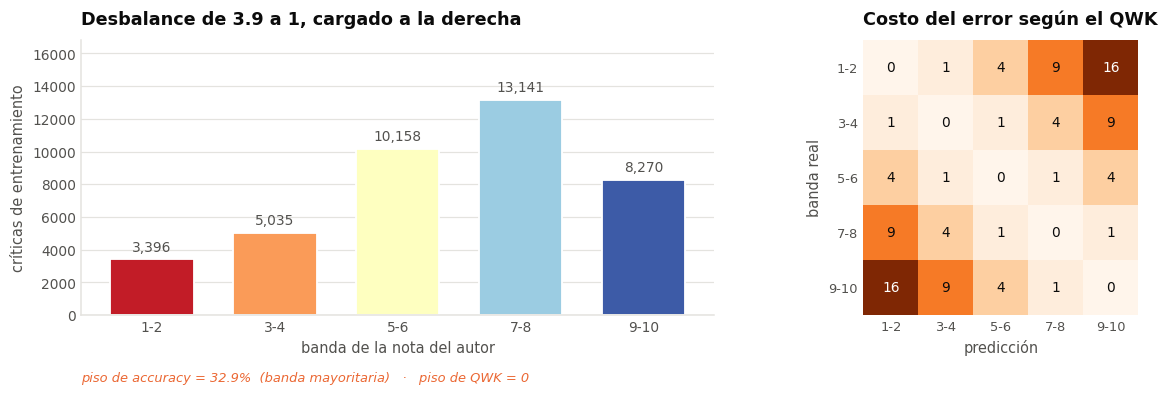

desbalance mayor/menor = 3.87 a 1
un error de 4 bandas pesa 16 veces más que uno de 1 en el QWK


In [9]:
conteo = df_train.y.value_counts().sort_index()
pesos_qwk = np.array([[(i - j) ** 2 for j in range(5)] for i in range(5)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.8),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# — izquierda: el reparto real, con el piso anotado
ax1.bar(range(5), conteo.values, color=COLOR_BANDA, width=.68,
        edgecolor="white", linewidth=1.2)
ax1.set_xticks(range(5)); ax1.set_xticklabels(BANDAS)
ax1.set_ylim(0, conteo.max() * 1.28)
for i, v in enumerate(conteo.values):
    ax1.text(i, v + conteo.max() * .04, f"{v:,}", ha="center", fontsize=9, color=TINTA_2)
ax1.set_xlabel("banda de la nota del autor")
ax1.set_ylabel("críticas de entrenamiento")
ax1.set_title(f"Desbalance de {conteo.max()/conteo.min():.1f} a 1, cargado a la derecha")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)
ax1.text(0, -.24, f"piso de accuracy = {conteo.max()/conteo.sum():.1%}  (banda mayoritaria)"
                  f"   ·   piso de QWK = 0",
         transform=ax1.transAxes, fontsize=8.5, color=NARANJA, style="italic")

# — derecha: la estructura de costos
im = ax2.imshow(pesos_qwk, cmap="Oranges", vmin=0, vmax=16)
ax2.set_xticks(range(5)); ax2.set_xticklabels(BANDAS, fontsize=8.5)
ax2.set_yticks(range(5)); ax2.set_yticklabels(BANDAS, fontsize=8.5)
for i in range(5):
    for j in range(5):
        ax2.text(j, i, pesos_qwk[i, j], ha="center", va="center", fontsize=9,
                 color="white" if pesos_qwk[i, j] > 9 else TINTA)
ax2.set_xlabel("predicción"); ax2.set_ylabel("banda real")
ax2.set_title("Costo del error según el QWK")
for e in ("top", "right", "bottom", "left"):
    ax2.spines[e].set_visible(False)

plt.tight_layout(); guardar(fig, "01-clases-y-costo-ordinal"); plt.show()

print(f"desbalance mayor/menor = {conteo.max()/conteo.min():.2f} a 1")
print(f"un error de 4 bandas pesa {16/1:.0f} veces más que uno de 1 en el QWK")

Cada mitad de la figura decide una cosa distinta.

El desbalance es de 3,9 a 1 y está cargado a la derecha. Las bandas 7-8 y 9-10 se llevan más de la
mitad del corpus y la de 1-2 se queda en el 8,5%. La explicación es poco misteriosa: quien se toma
el trabajo de escribir doscientas palabras sobre una película suele haberla elegido. La consecuencia
sí molesta, porque un modelo que responda siempre "7-8" acierta el 33,2% sin saber nada. De ahí que
ponderemos las clases y que la métrica de selección sea el macro-F1 y no el *accuracy*.

La matriz de la derecha decide qué se reporta. Dos clasificadores pueden tener el mismo *accuracy* y
ser muy distintos: uno reparte sus errores entre bandas vecinas y el otro los reparte al azar. El
macro-F1 no distingue esos dos casos. El QWK sí, y por eso lo llevamos en cada corrida.

### 3.2 Título y cuerpo → se concatenan

Cada crítica trae dos campos, `author_review_title` y `author_review_desc`, y en §2.3 los
concatenamos con una línea en blanco entre medias. Se escriben de forma muy distinta: el título es
un veredicto corto, muchas veces un juego de palabras con el título de la película, y el cuerpo es
la argumentación.

Antes de dar la concatenación por buena hay que comprobar que los dos aportan. Si el título ya
tuviera toda la señal, arrastrar el cuerpo sólo añadiría longitud de secuencia, y la atención cuesta
el cuadrado de la longitud.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def partir(serie):
    p = serie.str.split("\n\n", n=1)
    return p.str[0], p.str[1].fillna("")

df_train["titulo"], df_train["cuerpo"] = partir(df_train.texto)
val_titulo, val_cuerpo = partir(df_val.texto)

print(f"críticas con título no vacío : {(df_train.titulo.str.strip().str.len() > 0).mean():.1%}")
print(f"palabras  título: mediana {df_train.titulo.str.split().str.len().median():.0f}   "
      f"cuerpo: mediana {df_train.cuerpo.str.split().str.len().median():.0f}\n")

# Sonda rápida: ¿cuánta señal tiene cada parte por separado?
sonda = []
for campo, col_tr, col_val in [("sólo título", df_train.titulo, val_titulo),
                               ("sólo cuerpo", df_train.cuerpo, val_cuerpo),
                               ("ambos",       df_train.texto,  df_val.texto)]:
    v = TfidfVectorizer(min_df=3, sublinear_tf=True, ngram_range=(1, 2))
    Xt = v.fit_transform(col_tr)
    clf = LogisticRegression(max_iter=1000, C=4.0, random_state=SEED,
                             class_weight="balanced").fit(Xt, df_train.y)
    pred = clf.predict(v.transform(col_val))
    sonda.append({"campo": campo,
                  "accuracy": accuracy_score(df_val.y, pred),
                  "macro_f1": f1_score(df_val.y, pred, average="macro"),
                  "qwk": cohen_kappa_score(df_val.y, pred, weights="quadratic")})
sonda = pd.DataFrame(sonda)
print(sonda.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

críticas con título no vacío : 100.0%
palabras  título: mediana 5   cuerpo: mediana 186

      campo  accuracy  macro_f1    qwk
sólo título    0.3535    0.3379 0.3505
sólo cuerpo    0.5341    0.5253 0.7049
      ambos    0.5424    0.5351 0.7203


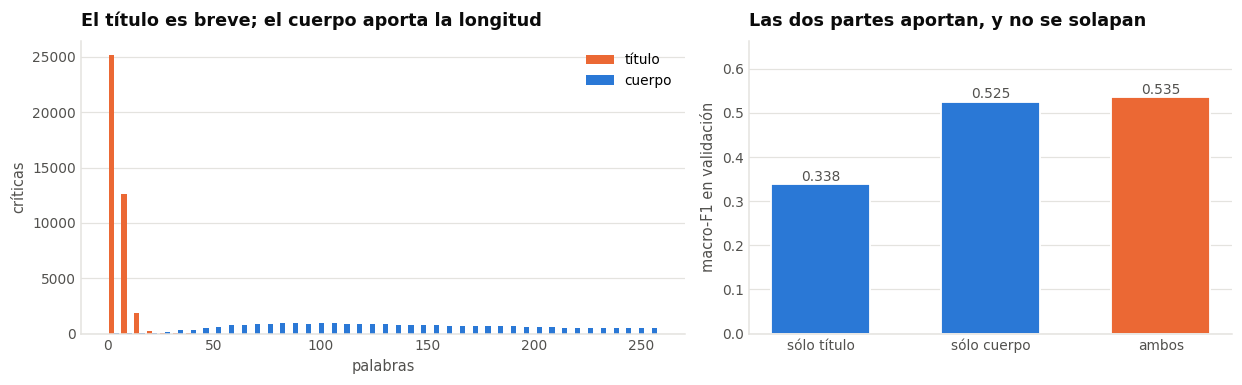

ganancia de concatenar frente al mejor campo solo: +0.0098 de macro-F1


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 3.6),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# — izquierda: cuánto ocupa cada parte
ax1.hist([df_train.titulo.str.split().str.len(), df_train.cuerpo.str.split().str.len()],
         bins=np.arange(0, 260, 6), color=[NARANJA, AZUL],
         label=["título", "cuerpo"], stacked=False)
ax1.set_xlabel("palabras"); ax1.set_ylabel("críticas")
ax1.set_title("El título es breve; el cuerpo aporta la longitud")
ax1.legend(loc="upper right"); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: cuánta señal tiene cada parte
x = np.arange(len(sonda))
ax2.bar(x, sonda.macro_f1, .58, color=[AZUL, AZUL, NARANJA],
        edgecolor="white", linewidth=1.2)
for i, v in enumerate(sonda.macro_f1):
    ax2.text(i, v + .008, f"{v:.3f}", ha="center", fontsize=9, color=TINTA_2)
ax2.set_xticks(x); ax2.set_xticklabels(sonda.campo, fontsize=9)
ax2.set_ylim(0, sonda.macro_f1.max() * 1.24)
ax2.set_ylabel("macro-F1 en validación")
ax2.set_title("Las dos partes aportan, y no se solapan")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "02-titulo-vs-cuerpo"); plt.show()

g = sonda.set_index("campo").macro_f1
print(f"ganancia de concatenar frente al mejor campo solo: "
      f"{g['ambos'] - max(g['sólo título'], g['sólo cuerpo']):+.4f} de macro-F1")

El cuerpo solo llega a 0,525 de macro-F1 y el título solo a 0,338. Juntos, 0,535. La concatenación
gana un punto sobre el mejor campo por separado, que es poco, pero es consistente y no cuesta nada,
así que se quedan juntos.

Lo que sorprende aparece al comparar tamaños. El título tiene una mediana de 5 palabras y el cuerpo
de 186. Con treinta y siete veces menos texto, el título alcanza el 64% del macro-F1 del cuerpo
entero. La señal no está repartida de forma pareja a lo largo de la crítica: se concentra al
principio, porque el título de una crítica de cine suele ser el veredicto ya condensado.

Esto vuelve a salir dos veces. En §3.4 justifica truncar por la derecha y no por la izquierda. Y en
§7 explica por qué la posición puede importar aquí más de lo habitual: un modelo que sabe dónde
empieza la secuencia puede aprender que esas primeras posiciones valen más. Para A4, sin
codificación posicional, todas son intercambiables.

### 3.3 El tokenizador → fija `vocab_size`

Entrenamos un BPE de nivel *byte* sobre nuestro propio corpus, partiendo de la configuración de
GPT-2 como plantilla. La pregunta que decide el tamaño del vocabulario es la **fertilidad**:
cuántos tokens hace falta gastar, en promedio, para escribir una palabra. Un vocabulario pequeño
parte todo en pedazos y alarga las secuencias — y la atención paga esa longitud al cuadrado. Uno
demasiado grande desperdicia parámetros de *embedding* en términos que aparecen dos veces.

Comparamos tres tamaños contra el tokenizador de GPT-2 sin reentrenar, que es el control: GPT-2 se
entrenó sobre texto mayoritariamente en inglés y debería fragmentar el español mucho más.

In [12]:
from transformers import AutoTokenizer
from tokenizers.pre_tokenizers import ByteLevel

base_gpt2 = AutoTokenizer.from_pretrained("gpt2")
alfabeto_bytes = list(ByteLevel.alphabet())
corpus_tok = df_train.texto.tolist()

def lotes(textos, n=1000):
    for i in range(0, len(textos), n):
        yield textos[i:i + n]

TAMANOS = (8_000, 16_000, 32_000)
tokenizadores = {}
for V in TAMANOS:
    t0 = time.perf_counter()
    tokenizadores[V] = base_gpt2.train_new_from_iterator(
        lotes(corpus_tok), vocab_size=V,
        initial_alphabet=alfabeto_bytes,
        new_special_tokens=["[PAD]"], show_progress=False)
    print(f"BPE de {V:>6,} tokens entrenado en {time.perf_counter()-t0:5.1f}s")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

BPE de  8,000 tokens entrenado en  18.8s
BPE de 16,000 tokens entrenado en  20.0s
BPE de 32,000 tokens entrenado en  20.4s


In [13]:
# Fertilidad: tokens generados por palabra del texto original.
muestra = df_train.texto.sample(4000, random_state=SEED).tolist()
n_palabras = sum(len(t.split()) for t in muestra)

def fertilidad(tok):
    n = sum(len(ids) for ids in tok(muestra, add_special_tokens=False)["input_ids"])
    return n / n_palabras

fert = {"GPT-2 sin reentrenar (50.257)": fertilidad(base_gpt2)}
for V in TAMANOS:
    fert[f"BPE propio ({V:,})"] = fertilidad(tokenizadores[V])

print("Fertilidad — tokens por palabra (más bajo es mejor):\n")
for k, v in fert.items():
    print(f"   {k:32s} {v:5.3f}")

# ¿Sobreviven enteras las palabras que el problema necesita?
CLAVE = ["no", "nunca", "nada", "pero", "aunque", "recomiendo", "decepcionante",
         "previsible", "guion", "aburrida", "maravillosa"]
print("\nEn cuántas piezas parte cada tokenizador los términos que decidirán la clase:\n")
print(f"   {'término':16s} " + "  ".join(f"{V//1000:>3d}k" for V in TAMANOS) + "   gpt2")
for w in CLAVE:
    piezas = [len(tokenizadores[V](" " + w, add_special_tokens=False)["input_ids"])
              for V in TAMANOS]
    pg = len(base_gpt2(" " + w, add_special_tokens=False)["input_ids"])
    print(f"   {w:16s} " + "  ".join(f"{p:>3d}" for p in piezas) + f"   {pg:>4d}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1953 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1342 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1229 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1143 > 1024). Running this sequence through the model will result in indexing errors


Fertilidad — tokens por palabra (más bajo es mejor):

   GPT-2 sin reentrenar (50.257)    2.067
   BPE propio (8,000)               1.465
   BPE propio (16,000)              1.344
   BPE propio (32,000)              1.264

En cuántas piezas parte cada tokenizador los términos que decidirán la clase:

   término            8k   16k   32k   gpt2
   no                 1    1    1      1
   nunca              1    1    1      2
   nada               1    1    1      2
   pero               1    1    1      2
   aunque             1    1    1      3
   recomiendo         1    1    1      3
   decepcionante      1    1    1      4
   previsible         1    1    1      2
   guion              1    1    1      2
   aburrida           1    1    1      4
   maravillosa        1    1    1      4


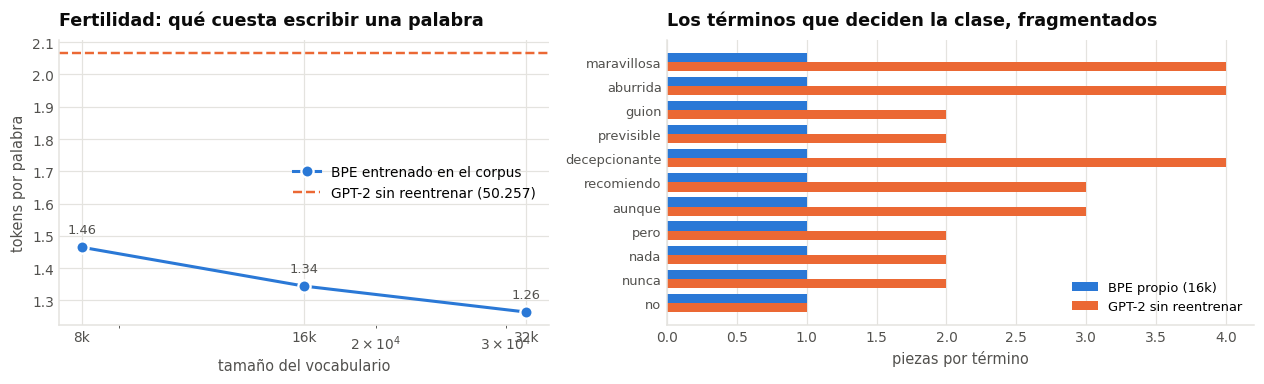

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.6),
                               gridspec_kw={"width_ratios": [1, 1.2]})

# — izquierda: fertilidad por tamaño de vocabulario
xs = list(TAMANOS)
ys = [fert[f"BPE propio ({V:,})"] for V in TAMANOS]
ax1.plot(xs, ys, "o-", color=AZUL, linewidth=2, markersize=8,
         markeredgecolor="white", markeredgewidth=1.5, label="BPE entrenado en el corpus")
ax1.axhline(fert["GPT-2 sin reentrenar (50.257)"], color=NARANJA,
            linestyle="--", linewidth=1.6, label="GPT-2 sin reentrenar (50.257)")
for x, y in zip(xs, ys):
    ax1.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 9),
                 ha="center", fontsize=8.5, color=TINTA_2)
ax1.set_xscale("log"); ax1.set_xticks(xs); ax1.set_xticklabels([f"{v//1000}k" for v in xs])
ax1.set_xlabel("tamaño del vocabulario"); ax1.set_ylabel("tokens por palabra")
ax1.set_title("Fertilidad: qué cuesta escribir una palabra")
ax1.legend(loc="best"); ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: fragmentación de los términos que deciden la clase
V_REF = 16_000
piezas_ref = [len(tokenizadores[V_REF](" " + w, add_special_tokens=False)["input_ids"])
              for w in CLAVE]
piezas_gpt = [len(base_gpt2(" " + w, add_special_tokens=False)["input_ids"]) for w in CLAVE]
y = np.arange(len(CLAVE)); ancho = .38
ax2.barh(y + ancho/2, piezas_ref, ancho, color=AZUL, label=f"BPE propio ({V_REF//1000}k)")
ax2.barh(y - ancho/2, piezas_gpt, ancho, color=NARANJA, label="GPT-2 sin reentrenar")
ax2.set_yticks(y); ax2.set_yticklabels(CLAVE, fontsize=8.5)
ax2.set_xlabel("piezas por término")
ax2.set_title("Los términos que deciden la clase, fragmentados")
ax2.legend(loc="lower right", fontsize=8.5)
ax2.grid(axis="x"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "03-tokenizador"); plt.show()

El BPE entrenado sobre el corpus gasta **1,34 tokens por palabra** frente a los **2,07** de GPT-2
sin reentrenar, que fragmenta el español de forma sistemática por haberse entrenado sobre todo en
inglés. Es un 35% menos de longitud para el mismo texto. Como la atención cuesta el cuadrado de esa
longitud, reentrenar el tokenizador acaba siendo la optimización más barata de todo el notebook: con
GPT-2 cabría poco más de la mitad de crítica en la misma ventana.

El tamaño lo decide el panel derecho. Las palabras que §3.5 y §3.6 van a señalar como decisivas,
`no`, `nunca`, `pero`, `recomiendo`, tienen que llegar al modelo enteras. Si `recomiendo` se parte
en tres piezas, el patrón "`no` … `recomiendo`" deja de ser una relación entre dos posiciones y pasa
a serlo entre cuatro, con lo que la atención tiene más trabajo para reconstruirlo.

Nos quedamos con 16.000. La curva de fertilidad ya se está aplanando ahí; duplicar a 32k apenas la
mueve y en cambio duplica la tabla de *embeddings*, que en un modelo de este tamaño es la partida
más gorda de parámetros.

In [15]:
VOCAB_SIZE = 16_000
tokenizador = tokenizadores[VOCAB_SIZE]
if tokenizador.pad_token is None:
    tokenizador.pad_token = "[PAD]"
PAD_ID = tokenizador.pad_token_id

print(f"vocabulario         : {len(tokenizador):,} tokens")
print(f"id de relleno [PAD] : {PAD_ID}")
print(f"\nejemplo de tokenización:")
demo = "No es una obra maestra, pero se deja ver."
print(f'   "{demo}"')
print(f"   {tokenizador.tokenize(demo)}")

vocabulario         : 16,000 tokens
id de relleno [PAD] : 1

ejemplo de tokenización:
   "No es una obra maestra, pero se deja ver."
   ['No', 'Ġes', 'Ġuna', 'Ġobra', 'Ġmaestra', ',', 'Ġpero', 'Ġse', 'Ġdeja', 'Ġver', '.']


### 3.4 Longitud en *tokens* → fija `max_len`

Aquí corregimos explícitamente un razonamiento del notebook guía. Allí se miden las longitudes en
**caracteres** (`len(row['text'])`) y de esa medición se concluye directamente un `max_len` en
**tokens**. Son unidades distintas y el factor de conversión es justamente la fertilidad que
acabamos de medir, así que la conclusión no se sigue de la premisa.

Medimos sobre los tokens que el modelo va a recibir de verdad, y añadimos las dos columnas que el
guía no mira y que aquí deciden: **qué fracción del texto se pierde por truncar** y **qué fracción
de las posiciones procesadas es relleno**.

Conviene avisar de que este corpus no se comporta como los de textos cortos con los que suele
ilustrarse esta tarea. Una crítica de FilmAffinity tiene una mediana de **191 palabras** y el
percentil 99 está en **943**: aquí la gente argumenta. No existe un `max_len` que evite truncar sin
pagar un relleno enorme, así que la elección no la fija una regla sobre la distribución sino **el
presupuesto de cómputo**, y lo que toca es medir con honestidad qué se deja fuera.

In [16]:
largos = np.array([len(ids) for ids in
                   tokenizador(df_train.texto.tolist(), add_special_tokens=False)["input_ids"]])

print("Longitud en tokens del BPE propio:")
print(pd.Series(largos).describe(percentiles=[.5, .75, .9, .95, .97, .99])
      .round(1).to_string())

CORTES = (128, 192, 256, 320, 384, 512)
corte = pd.DataFrame([
    {"max_len": L,
     "docs_truncados_%":  (largos > L).mean() * 100,
     "tokens_perdidos_%": np.maximum(largos - L, 0).sum() / largos.sum() * 100,
     "posiciones_relleno_%": np.maximum(L - largos, 0).sum() / (L * len(largos)) * 100,
     "costo_atencion": (L / 128) ** 2}
    for L in CORTES
]).round(2)
print("\n" + corte.to_string(index=False))

# Esto es una decisión de presupuesto, no una regla estadística. El costo de la
# atención crece con L^2 y §6 encadena unas 19 corridas, así que pasar de 256 a 512
# cuadruplicaría el tiempo total sólo para rescatar cola. Fijamos 256 y dejamos
# impreso lo que cuesta.
MAX_LEN = 256
i_sel = list(CORTES).index(MAX_LEN)
print(f"\nmax_len fijado por presupuesto: {MAX_LEN}  (costo relativo "
      f"x{corte.costo_atencion[i_sel]:.1f} frente a 128)")
print(f"   se trunca el {(largos > MAX_LEN).mean():.1%} de las críticas")
print(f"   se pierde   el {np.maximum(largos - MAX_LEN, 0).sum()/largos.sum():.1%} de los tokens")
print(f"   es relleno  el {np.maximum(MAX_LEN - largos, 0).sum()/(MAX_LEN*len(largos)):.1%} "
      f"de las posiciones que procesa la red")
print(f"\npasar a 512 rescataría {(largos > MAX_LEN).mean() - (largos > 512).mean():.1%} de las "
      f"críticas truncadas a cambio de x4 de cómputo.")

Longitud en tokens del BPE propio:
count    40000.0
mean       325.8
std        246.3
min         13.0
50%        255.0
75%        427.0
90%        640.0
95%        802.0
97%        952.0
99%       1285.0
max       1725.0

 max_len  docs_truncados_%  tokens_perdidos_%  posiciones_relleno_%  costo_atencion
     128             81.35              62.81                  5.34            1.00
     192             64.04              48.55                 12.69            2.25
     256             49.68              37.42                 20.34            4.00
     320             38.58              28.77                 27.48            6.25
     384             29.97              22.07                 33.87            9.00
     512             17.63              12.91                 44.58           16.00

max_len fijado por presupuesto: 256  (costo relativo x4.0 frente a 128)
   se trunca el 49.7% de las críticas
   se pierde   el 37.4% de los tokens
   es relleno  el 20.3% de las posicione

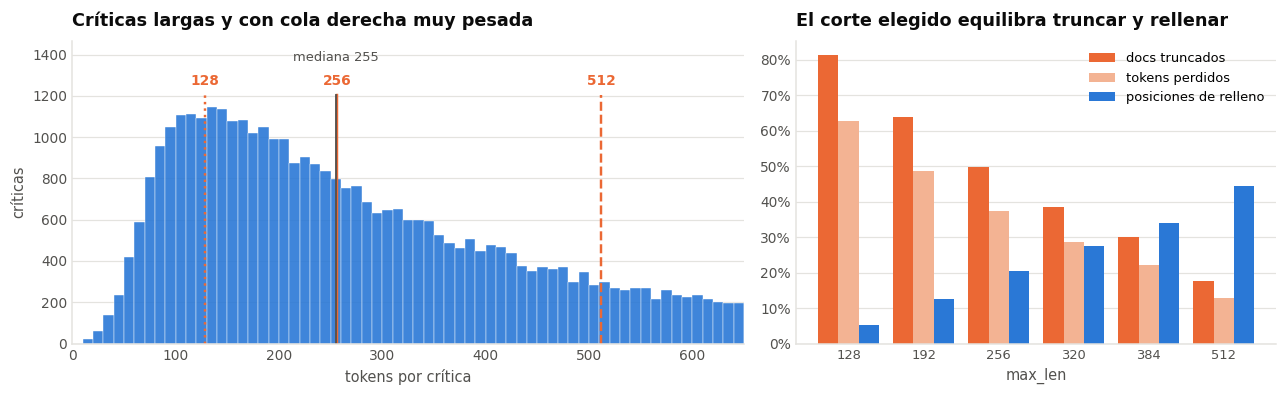

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 3.7),
                               gridspec_kw={"width_ratios": [1.4, 1]})

# — izquierda: distribución y cortes candidatos
ax1.hist(largos, bins=np.arange(0, 700, 10), color=AZUL, alpha=.9,
         edgecolor="white", linewidth=.3)
tope = ax1.get_ylim()[1]; ax1.set_ylim(0, tope * 1.22)
TECHO = 1 / 1.22
for L, est in [(128, ":"), (MAX_LEN, "-"), (512, "--")]:
    ax1.axvline(L, ymax=TECHO, color=NARANJA, linestyle=est, linewidth=1.6)
    ax1.text(L, tope * 1.04, str(L), color=NARANJA, fontsize=9, fontweight="bold", ha="center")
ax1.axvline(np.median(largos), ymax=TECHO, color=TINTA_2, linewidth=1.2)
ax1.text(np.median(largos), tope * 1.14, f"mediana {int(np.median(largos))}",
         color=TINTA_2, fontsize=8.5, ha="center")
ax1.set_xlabel("tokens por crítica"); ax1.set_ylabel("críticas")
ax1.set_title("Críticas largas y con cola derecha muy pesada")
ax1.set_xlim(0, 650); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: los tres costos de cada corte, en la misma escala porcentual
x = np.arange(len(corte)); ancho = .27
ax2.bar(x - ancho, corte["docs_truncados_%"], ancho, color=NARANJA, label="docs truncados")
ax2.bar(x,         corte["tokens_perdidos_%"], ancho, color="#f3b393", label="tokens perdidos")
ax2.bar(x + ancho, corte["posiciones_relleno_%"], ancho, color=AZUL, label="posiciones de relleno")
ax2.set_xticks(x); ax2.set_xticklabels(corte.max_len, fontsize=8.5)
ax2.set_xlabel("max_len"); ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax2.set_title("El corte elegido equilibra truncar y rellenar")
ax2.legend(loc="upper right", fontsize=8.5)
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "04-longitudes-tokens"); plt.show()

Ésta es la decisión más incómoda del notebook, y la tabla no deja sitio para disimularla.

En tokens BPE la mediana de una crítica es **255**, el percentil 90 está en **640** y el 99 en
**1.285**. Hay que leer juntas `tokens_perdidos_%` y `posiciones_relleno_%`, porque tiran en
direcciones opuestas: bajar `max_len` tira texto a la basura y subirlo llena la secuencia de vacío,
con la atención pagando el cuadrado de la longitud. En este corpus no hay punto dulce. A 128
posiciones se trunca el 81% de las críticas y se pierde el 63% de los tokens; a 512 el relleno sube
al 45% y el cómputo se multiplica por dieciséis.

Elegimos 256, y lo decimos como lo que es: una decisión de presupuesto, no un óptimo. Al corte
elegido **se trunca la mitad de las críticas y se pierde el 37% de los tokens**, a cambio de sólo un
20% de relleno. Es mucho texto tirado, y conviene no maquillarlo.

Lo que hace la decisión defendible es §3.2. Allí se midió que el título va al principio y concentra
mucha más señal por palabra que el cuerpo, así que lo que se corta por la derecha es la parte menos
informativa. No es gratis, pero es lo barato de perder.

Aun así queda como la limitación técnica principal de la entrega, y la anotamos para §9: con más
presupuesto, subir `max_len` sería lo primero que habría que probar, antes que añadir capas.

El porcentaje de relleno que sale de aquí manda sobre dos decisiones de arquitectura. La primera es
el enmascaramiento de §5.3, que deja de ser un detalle de higiene: cada posición de relleno que la
máscara no tape compite por la atención con el texto real. La segunda es el `Flatten` del notebook
guía, que resulta especialmente caro en este corpus porque le dedica una fila de pesos a cada
posición y buena parte de esas posiciones están vacías casi siempre.

Las dos se convierten en las extracciones A1 y A3 de §6.

### 3.5 Qué debería aprender el modelo

Usamos el *log-odds ratio* con prior informativo de Monroe, Colaresi y Quinn (2008), que corrige el
sesgo por el que las palabras muy frecuentes dominan cualquier ranking ingenuo — sin esa corrección,
las cinco listas saldrían llenas de `película`, `cine` y `historia`. Para cada banda, qué términos la
separan del resto.

In [18]:
def palabras(texto):
    """Tokenizador de análisis: minúsculas, letras del español y dígitos."""
    return re.sub(r"[^a-záéíóúñü0-9]+", " ", texto.lower()).split()

df_train["palabras"] = df_train.texto.map(palabras)

frec = Counter()
for t in df_train.palabras:
    frec.update(t)
V_LO = [w for w, c in frec.items() if c >= 60]      # descarta la cola de ruido
alpha = np.array([frec[w] for w in V_LO], float)
a0 = alpha.sum()

conteos = {}
for k in range(5):
    c = Counter()
    for t in df_train.palabras[df_train.y == k]:
        c.update(t)
    conteos[k] = np.array([c.get(w, 0) for w in V_LO], float)
total_v = sum(conteos.values())

def log_odds(k, n=12):
    """z del log-odds ratio de cada término: banda k contra el resto del corpus."""
    yi = conteos[k]; yj = total_v - yi
    ni, nj = yi.sum(), yj.sum()
    delta = (np.log((yi + alpha) / (ni + a0 - yi - alpha))
             - np.log((yj + alpha) / (nj + a0 - yj - alpha)))
    z = delta / np.sqrt(1 / (yi + alpha) + 1 / (yj + alpha))
    idx = np.argsort(-z)[:n]
    return [V_LO[i] for i in idx], z[idx]

print(f"vocabulario evaluado: {len(V_LO):,} tipos con frecuencia ≥ 60\n")
TERMINOS_EDA = {}
for k in range(5):
    w, z = log_odds(k, 9)
    TERMINOS_EDA[k] = list(zip(w, z))
    print(f"{NOMBRE[k]:12s} │ z_max={z[0]:5.1f} │ {', '.join(w)}")

vocabulario evaluado: 10,245 tipos con frecuencia ≥ 60

banda 1-2    │ z_max= 15.5 │ mala, ni, bodrio, basura, no, peor, nada, mierda, vergüenza
banda 3-4    │ z_max= 14.8 │ no, nada, ni, floja, mal, aburrida, peor, me, mediocre
banda 5-6    │ z_max= 13.8 │ pero, interesante, entretenida, demasiado, bastante, pasable, 6, tampoco, poco
banda 7-8    │ z_max= 15.0 │ su, notable, 7, sus, la, gran, también, recomendable, en
banda 9-10   │ z_max= 18.1 │ maestra, obra, magistral, mejores, cine, excelente, cada, maravillosa, amor


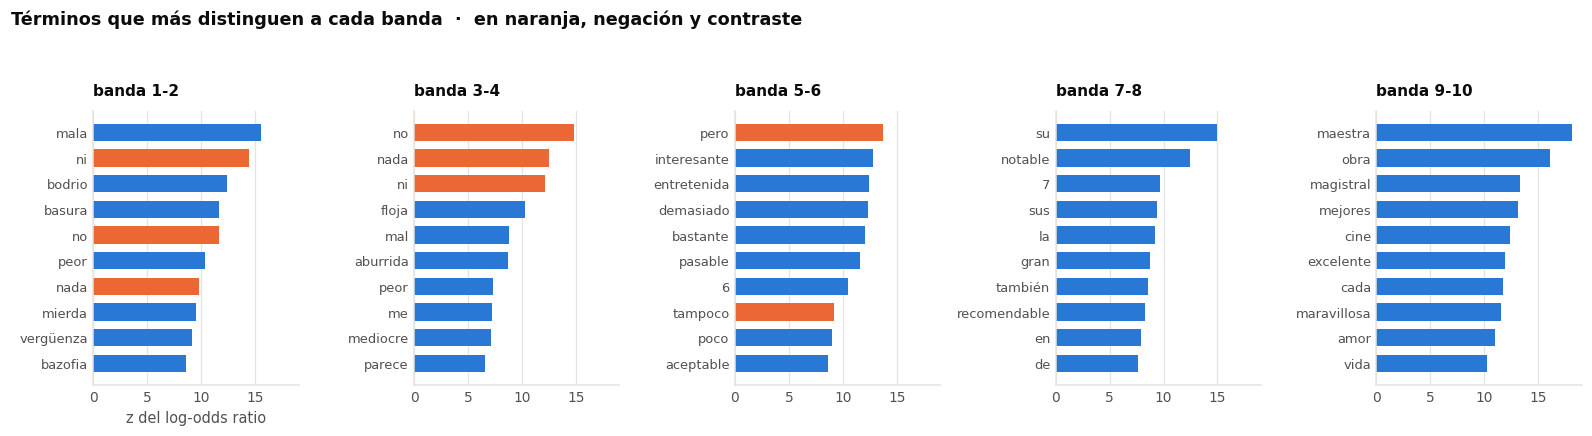

8 de los 50 términos más discriminativos son marcadores funcionales (negación o contraste), no vocabulario evaluativo.


In [19]:
FUNCIONALES = {"no", "nada", "nunca", "ni", "tampoco", "pero", "aunque", "sin"}

fig, axes = plt.subplots(1, 5, figsize=(14.5, 4.0), sharex=True)
for k, ax in enumerate(axes):
    w, z = log_odds(k, 10)
    orden = np.argsort(z)
    # En naranja los términos funcionales, negación y contraste, de los que se
    # ocupa §3.6. El resto en el tono neutro.
    colores = [NARANJA if w[i] in FUNCIONALES else AZUL for i in orden]
    ax.barh(range(10), z[orden], color=colores, height=.68)
    ax.set_yticks(range(10)); ax.set_yticklabels([w[i] for i in orden], fontsize=8.5)
    ax.set_title(f"banda {BANDAS[k]}", fontsize=10)
    ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
axes[0].set_xlabel("z del log-odds ratio")
fig.suptitle("Términos que más distinguen a cada banda  ·  en naranja, negación y contraste",
             x=.005, ha="left", fontsize=11.5, fontweight="semibold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .93]); guardar(fig, "05-terminos-discriminativos"); plt.show()

# ¿Cuántos de los términos más discriminativos son operadores y no adjetivos?
top_todos = [w for k in range(5) for w in log_odds(k, 10)[0]]
n_func = sum(w in FUNCIONALES for w in top_todos)
print(f"{n_func} de los {len(top_todos)} términos más discriminativos son marcadores "
      f"funcionales (negación o contraste), no vocabulario evaluativo.")

Aquí aparece el hallazgo que reorienta la entrega. En los extremos está lo esperable, vocabulario
de polaridad: 9-10 se identifica con `maestra`, `obra`, `magistral`, `excelente`, `maravillosa`, y
1-2 con `mala`, `bodrio`, `basura`, `peor`. Nada que una bolsa de palabras no resuelva.

Lo que no esperábamos son otras tres cosas.

El término más discriminativo de la banda 3-4 no es un adjetivo: es `no`, con z = 14,8, y lo
acompañan `ni` y `nada` en el mismo *top*. En la banda 1-2, `ni` va segundo y `no` quinto, por
delante de casi todo el vocabulario evaluativo. Son palabras sin contenido semántico propio, cuyo
único trabajo es invertir el significado de otras.

La banda 5-6 se identifica por `pero`, su término número uno con z = 13,8, seguido de `tampoco` y
`demasiado`. Tiene sentido: la crítica de aprobado raspado es la que dice *"tiene una fotografía
preciosa, pero el guion no se sostiene"*. Lo que la marca es una estructura, no un léxico.

Y la banda 7-8 se identifica por palabras funcionales sin polaridad ninguna, `su`, `sus`, `la`,
`en`, `también`, junto a `notable` y `recomendable`. Es la banda del elogio medido, y lo que la
distingue es el registro más que el vocabulario.

Los tres casos apuntan al mismo sitio. Si las palabras que más discriminan son operadores que actúan
sobre otras palabras, un modelo que sólo cuente ocurrencias tiene un techo. Eso es lo que §3.6 se
propone medir, y es el argumento por el que este corpus sirve como banco de pruebas para la
atención.

### 3.6 Negación y contraste → la figura que justifica el notebook

La observación anterior es cualitativa. Aquí la convertimos en una medición, con dos preguntas:

1. ¿Cómo se reparte por banda la **densidad** de negadores (`no`, `nunca`, `nada`, `ni`, `tampoco`)
   y de conectores contrastivos (`pero`, `aunque`, `sin embargo`)? Medimos densidad por cada cien
   palabras y no mera presencia, porque en críticas largas casi todas contienen un `no` en alguna
   parte y la presencia satura.
2. Y la pregunta que de verdad importa: **¿cuánto cambia el significado de un término positivo
   cuando lleva una negación cerca?** Si la respuesta es "mucho", una bolsa de palabras tiene un
   problema estructural y no de datos.

In [20]:
NEGADORES = {"no", "nunca", "nada", "tampoco", "ni", "jamás", "jamas"}
CONTRASTE = {"pero", "aunque", "sino"}

n_palabras_doc = df_train.palabras.map(len)
df_train["n_neg"] = df_train.palabras.map(lambda t: sum(w in NEGADORES for w in t))
df_train["n_con"] = df_train.palabras.map(lambda t: sum(w in CONTRASTE for w in t))
df_train["d_neg"] = df_train.n_neg / n_palabras_doc.clip(lower=1) * 100
df_train["d_con"] = df_train.n_con / n_palabras_doc.clip(lower=1) * 100

marcadores = df_train.groupby("y").agg(
    presencia_neg=("n_neg", lambda s: (s > 0).mean() * 100),
    densidad_neg=("d_neg", "mean"),
    presencia_con=("n_con", lambda s: (s > 0).mean() * 100),
    densidad_con=("d_con", "mean"))
marcadores.index = BANDAS
print("Marcadores por banda — presencia (% de críticas) y densidad (por 100 palabras):\n")
print(marcadores.round(2).to_string())

# Inversión de polaridad: un término positivo con un negador a menos de tres palabras.
POSITIVOS = ["recomiendo", "funciona", "buena", "gusta", "entretenida", "interesante", "obra"]
patron_neg = re.compile(
    r"\b(?:no|nunca|nada|tampoco|ni)\s+(?:\w+\s+){0,2}?(?:" + "|".join(POSITIVOS) + r")\b")
df_train["polaridad_invertida"] = df_train.texto.str.lower().str.contains(patron_neg, regex=True)

print(f"\nEl {df_train.polaridad_invertida.mean():.1%} de las críticas contiene al menos un "
      f"patrón de inversión de polaridad.\n")
print("Banda media de las críticas que contienen cada término positivo (0 = 1-2 … 4 = 9-10):\n")
print(f"   {'término':12s} {'sin negación':>13s} {'con negación':>13s} {'salto':>8s}   n con neg.")
SALTOS = {}
for w in POSITIVOS:
    sub = df_train[df_train.palabras.map(lambda t, w=w: w in t)]
    con = sub[sub.polaridad_invertida]; sin = sub[~sub.polaridad_invertida]
    if len(con) >= 40:
        a, b = sin.y.mean(), con.y.mean()
        SALTOS[w] = (a, b, len(con))
        print(f"   {w:12s} {a:13.2f} {b:13.2f} {b-a:+8.2f}   {len(con):>8,}")

Marcadores por banda — presencia (% de críticas) y densidad (por 100 palabras):

      presencia_neg  densidad_neg  presencia_con  densidad_con
1-2           92.73          2.93          67.61          0.80
3-4           93.70          2.60          79.52          0.99
5-6           90.25          2.01          83.61          1.08
7-8           85.58          1.52          76.81          0.84
9-10          82.56          1.55          65.72          0.66

El 4.5% de las críticas contiene al menos un patrón de inversión de polaridad.

Banda media de las críticas que contienen cada término positivo (0 = 1-2 … 4 = 9-10):

   término       sin negación  con negación    salto   n con neg.
   recomiendo            2.89          1.52    -1.36        245
   funciona              2.58          1.78    -0.80        301
   buena                 2.55          2.09    -0.46        718
   gusta                 2.59          2.27    -0.32        592
   entretenida           2.44          2.20    -0.2

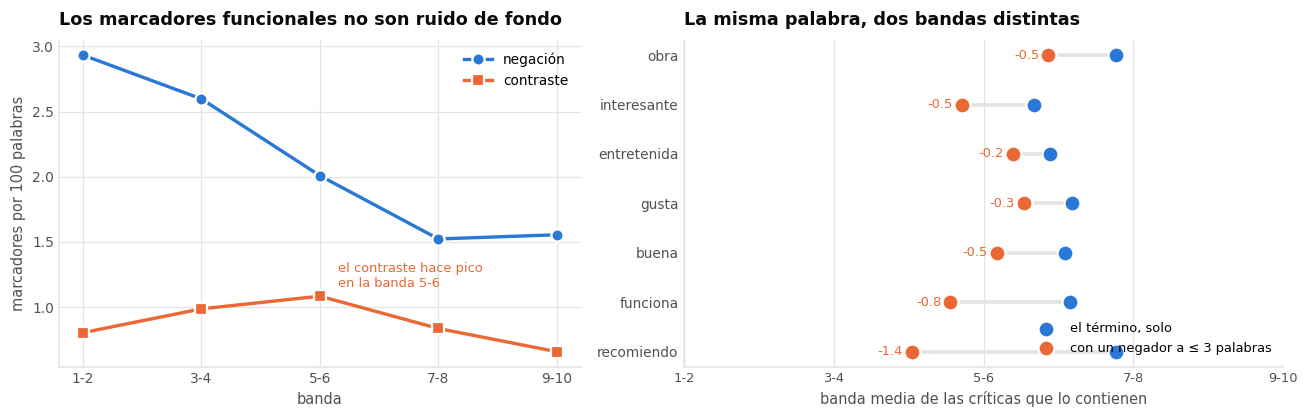

mayor inversión: «recomiendo» pasa de la banda 2.89 a la 1.52 (-1.36 bandas ≈ -2.7 puntos sobre 10) en 245 casos


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 3.9),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# — izquierda: cómo se reparten los marcadores a lo largo de la escala
x = np.arange(5)
ax1.plot(x, marcadores.densidad_neg, "o-", color=AZUL, linewidth=2.2, markersize=8,
         markeredgecolor="white", markeredgewidth=1.5, label="negación")
ax1.plot(x, marcadores.densidad_con, "s-", color=NARANJA, linewidth=2.2, markersize=8,
         markeredgecolor="white", markeredgewidth=1.5, label="contraste")
pico = int(np.argmax(marcadores.densidad_con.values))
ax1.annotate(f"el contraste hace pico\nen la banda {BANDAS[pico]}",
             (pico, marcadores.densidad_con.iloc[pico]), textcoords="offset points",
             xytext=(12, 6), fontsize=8.5, color=NARANJA)
ax1.set_xticks(x); ax1.set_xticklabels(BANDAS)
ax1.set_xlabel("banda")
ax1.set_ylabel("marcadores por 100 palabras")
ax1.set_title("Los marcadores funcionales no son ruido de fondo")
ax1.legend(loc="upper right"); ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: el salto de polaridad
terminos = list(SALTOS)
y = np.arange(len(terminos))
sin_v = [SALTOS[w][0] for w in terminos]
con_v = [SALTOS[w][1] for w in terminos]
for i, w in enumerate(terminos):
    ax2.plot([con_v[i], sin_v[i]], [i, i], color=MALLA, linewidth=2.4, zorder=1)
ax2.scatter(sin_v, y, s=110, color=AZUL, edgecolor="white", linewidth=1.5, zorder=3,
            label="el término, solo")
ax2.scatter(con_v, y, s=110, color=NARANJA, edgecolor="white", linewidth=1.5, zorder=3,
            label="con un negador a ≤ 3 palabras")
for i, w in enumerate(terminos):
    ax2.text(con_v[i] - .06, i, f"{con_v[i]-sin_v[i]:+.1f}", ha="right", va="center",
             fontsize=8.5, color=NARANJA)
ax2.set_yticks(y); ax2.set_yticklabels(terminos, fontsize=9)
ax2.set_xticks(range(5)); ax2.set_xticklabels(BANDAS, fontsize=8.5)
ax2.set_xlabel("banda media de las críticas que lo contienen")
ax2.set_title("La misma palabra, dos bandas distintas")
ax2.legend(loc="lower right", fontsize=8.5)
ax2.grid(axis="x"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "06-negacion-y-contraste"); plt.show()

mayor = max(SALTOS, key=lambda w: SALTOS[w][0] - SALTOS[w][1])
a, b, n = SALTOS[mayor]
print(f"mayor inversión: «{mayor}» pasa de la banda {a:.2f} a la {b:.2f} "
      f"({b-a:+.2f} bandas ≈ {2*(b-a):+.1f} puntos sobre 10) en {n:,} casos")

Ésta es la figura que sostiene toda la entrega.

Antes que nada, por qué medimos densidad y no presencia. La negación aparece en más del 82% de las
críticas de todas las bandas, incluida la de 9-10, y en la de 3-4 llega al 94%. En textos de
doscientas palabras, preguntar si hay un `no` no separa nada. Con densidad el patrón sale limpio:
2,93 negadores por cada cien palabras en la banda 1-2 frente a 1,52 en la de 7-8, casi el doble.

El contraste dibuja la otra curva y hace pico donde §3.5 hacía sospechar, en la banda 5-6, con 1,08
marcadores por cien palabras. Queda por encima tanto del extremo negativo (0,80) como del positivo
(0,66). La banda intermedia no tiene un léxico propio. Tiene una sintaxis propia.

El panel derecho es el resultado central. `recomiendo`, por sí solo, aparece en críticas que
promedian la banda 2,89; el mismo verbo con un negador a tres palabras o menos aparece en críticas
que promedian 1,52. Son 1,36 bandas de diferencia, unos 2,7 puntos sobre 10, producidas por una
palabra de dos letras, y medidas sobre 245 casos. `funciona` recorre 0,80 bandas sobre 301 casos e
`interesante` 0,48 sobre 372.

Para una bolsa de palabras esos dos grupos de críticas son casi el mismo documento: comparten el
término positivo, y el negador es una palabra vacía más. Para un modelo que lea en orden se
distinguen sin problema. Aquí H1 deja de ser una corazonada metodológica y pasa a tener un mecanismo
medido detrás.

Dicho lo cual, hay dos cosas que conviene no pasar por alto.

Una es de tamaño. El patrón de inversión que sabemos detectar aparece sólo en el 4,5% de las
críticas. Donde actúa es fuerte, pero afecta a una minoría del corpus, así que no hay motivo para
esperar que él solo decida la comparación entre arquitecturas. Conviene retener este número: en §6
resulta ser la clave de lo que pasa.

La otra es de cobertura. Un TF-IDF con bigramas captura `no recomiendo` como rasgo propio, o sea que
ya tiene parte de esta información, y por eso en §5.1 entrenamos las dos variantes por separado. Lo
que los bigramas no alcanzan es la dependencia larga: `no` … `consigue` … `en ningún momento` …
`emocionar`. La pregunta de la entrega es si la atención cubre ese hueco, y si el hueco da para
notarse.

### 3.7 Cuánta nota se explica sin leer el texto

Esta sección no estaba en el plan original y salió de la advertencia que dejamos anotada en §2.4.
Antes de medir lo bien que un modelo lee, hay que saber cuánta de la nota se puede adivinar sin leer
nada.

Hay dos atajos, y ninguno de los dos está en el texto de la crítica. Uno es la película, porque las
críticas de una misma película se parecen en la nota. El otro es el autor, porque hay críticos
sistemáticamente generosos y críticos sistemáticamente severos.

Medimos cuánta varianza de la nota explica cada uno y montamos dos *baselines* que no miran el texto
en absoluto. Si resultaran competitivos, buena parte de lo que mide este notebook no sería
comprensión lectora.

In [22]:
# Varianza de la nota explicada por cada agrupación, sobre el corpus completo.
var_total = criticas.author_rating.var()
media_film = criticas.groupby("film_id").author_rating.transform("mean")
media_autor = criticas.groupby("author_id").author_rating.transform("mean")
var_pelicula = 1 - (criticas.author_rating - media_film).var() / var_total
var_autor = 1 - (criticas.author_rating - media_autor).var() / var_total

print(f"varianza total de la nota          : {var_total:.3f}")
print(f"explicada sólo por la película     : {var_pelicula:.1%}")
print(f"explicada sólo por el autor        : {var_autor:.1%}\n")

# B2a — la nota media del catálogo, que no mira la crítica sino la ficha de la película.
j = df_val.merge(peliculas[["film_id", "film_average_rating"]], on="film_id", how="left")
hay_ficha = j.film_average_rating.notna()
pred_catalogo = np.clip(((j.film_average_rating[hay_ficha] - 1) // 2).astype(int), 0, 4)
m_b2a = evaluar(j.y[hay_ficha], pred_catalogo, nombre="B2a-nota-del-catalogo",
                particion="val", notas=f"sin texto; cubre {hay_ficha.mean():.1%} de val",
                verbose=False)

# B2b — la media histórica del autor, calculada SÓLO con entrenamiento.
media_aut_train = train_full.groupby("author_id").y.mean()
pa = df_val.author_id.map(media_aut_train)
hay_autor = pa.notna()
pred_autor = np.clip(pa[hay_autor].round().astype(int), 0, 4)
m_b2b = evaluar(df_val.y[hay_autor], pred_autor, nombre="B2b-media-del-autor",
                particion="val", notas=f"sin texto; cubre {hay_autor.mean():.1%} de val",
                verbose=False)

print(f"B2a nota del catálogo (cubre {hay_ficha.mean():5.1%} de val) : "
      f"macro-F1 {m_b2a['macro_f1']:.4f}   QWK {m_b2a['qwk']:.4f}")
print(f"B2b media del autor   (cubre {hay_autor.mean():5.1%} de val) : "
      f"macro-F1 {m_b2b['macro_f1']:.4f}   QWK {m_b2b['qwk']:.4f}")
print(f"B0  banda fija                              : "
      f"macro-F1 {b0['macro_f1']:.4f}   QWK {b0['qwk']:.4f}")

varianza total de la nota          : 5.780
explicada sólo por la película     : 28.7%
explicada sólo por el autor        : 37.0%

B2a nota del catálogo (cubre 100.0% de val) : macro-F1 0.2303   QWK 0.3242
B2b media del autor   (cubre 92.4% de val) : macro-F1 0.2782   QWK 0.2919
B0  banda fija                              : macro-F1 0.1024   QWK 0.0000


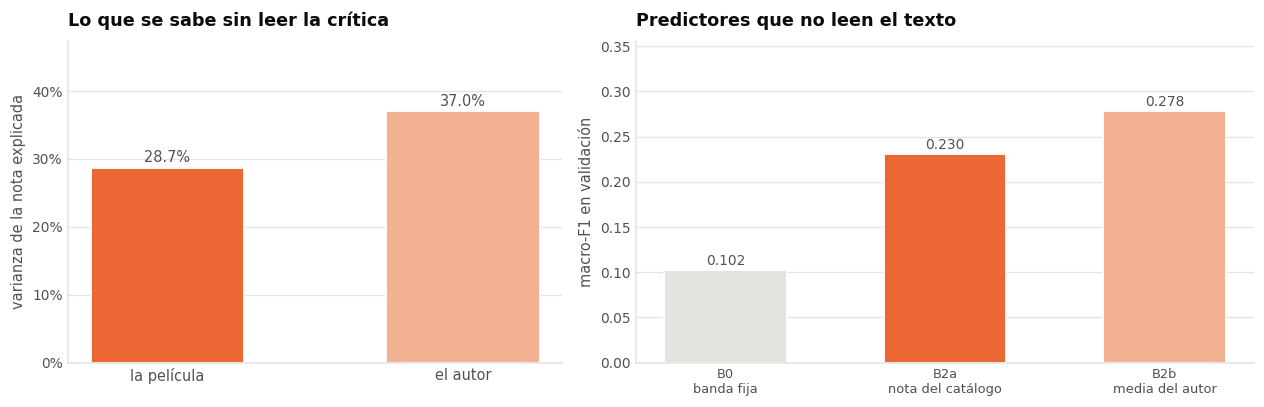

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.25]})

# — izquierda: cuánta nota explica cada confundidor
ax1.bar([0, 1], [var_pelicula * 100, var_autor * 100], .52,
        color=[NARANJA, "#f3b393"], edgecolor="white", linewidth=1.2)
for i, v in enumerate([var_pelicula, var_autor]):
    ax1.text(i, v * 100 + .8, f"{v:.1%}", ha="center", fontsize=9.5, color=TINTA_2)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["la película", "el autor"], fontsize=9.5)
ax1.set_ylabel("varianza de la nota explicada")
ax1.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax1.set_ylim(0, max(var_pelicula, var_autor) * 128)
ax1.set_title("Lo que se sabe sin leer la crítica")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: los baselines sin texto, contra el piso
etiquetas = ["B0\nbanda fija", "B2a\nnota del catálogo", "B2b\nmedia del autor"]
vals = [b0["macro_f1"], m_b2a["macro_f1"], m_b2b["macro_f1"]]
ax2.bar(np.arange(3), vals, .56, color=[MALLA, NARANJA, "#f3b393"],
        edgecolor="white", linewidth=1.2)
for i, v in enumerate(vals):
    ax2.text(i, v + .006, f"{v:.3f}", ha="center", fontsize=9, color=TINTA_2)
ax2.set_xticks(np.arange(3)); ax2.set_xticklabels(etiquetas, fontsize=8.5)
ax2.set_ylim(0, max(vals) * 1.28)
ax2.set_ylabel("macro-F1 en validación")
ax2.set_title("Predictores que no leen el texto")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "07-confundidores"); plt.show()

Los dos atajos existen y son grandes. La película explica el 28,7% de la varianza de la nota. El
autor explica el 37,0%, o sea más que la película.

No es lo que esperábamos al escribir §2.4, donde partimos por `film_id` dando por hecho que la
película era el confundidor principal. Visto ahora tiene sentido: en FilmAffinity hay críticos que
casi nunca bajan del 7 y críticos que han hecho de la severidad su firma, y esa tendencia acompaña a
todo lo que escriben. El atajo que nos molestamos en cerrar resultó ser el más pequeño de los dos.

Los baselines sin texto traducen esos porcentajes a métrica. Predecir con la nota media del catálogo
da 0,230 de macro-F1, y con la media histórica del autor 0,278, cubriendo el 92% de validación.
Muy por encima del piso (0,102) y muy por debajo de lo que se consigue leyendo el texto. Son
confundidores de verdad, pero no rivales.

De aquí salen tres cosas que recorren el resto del notebook.

La primera es que la partición agrupada por película deja de ser una precaución teórica. Con una
partición aleatoria, un modelo con memoria suficiente puede aprenderse la media de cada película y
cobrarse esa varianza sin leer nada. En §6.3 lo medimos entrenando el mismo encoder con las dos
particiones.

La segunda es que el atajo del autor sigue abierto, y ahora sabemos que es el mayor. El 79% de los
autores de prueba escribió también en entrenamiento (§2.4). Agrupar también por autor expulsaría a
los críticos más prolíficos, que son los que aportan más texto, y dejaría un corpus más pequeño y
sesgado hacia el usuario ocasional. No lo eliminamos. Lo medimos, lo dejamos escrito y lo tenemos en
cuenta al interpretar.

La tercera es la incómoda: cualquier cifra de este notebook lleva dentro una parte no textual que no
sabemos descontar. Es la limitación metodológica principal de la entrega, y al leer §8 pesa más que
el valor absoluto del macro-F1.

### 3.8 Similitud entre bandas → predice la matriz de confusión

Última pieza del EDA, y la más exigente consigo misma, porque consiste en predecir dónde se va a
equivocar el modelo antes de entrenarlo. Representamos cada banda por el centroide de sus documentos
en espacio TF-IDF y medimos la similitud coseno entre centroides. Si dos bandas comparten
vocabulario, un clasificador que se apoye en el léxico debería confundirlas.

Lo que esperamos encontrar es concreto. Si la escala es un orden real, la similitud tiene que decaer
de forma monótona con la distancia entre bandas, en vez de formar grupos arbitrarios. Es una
predicción falsable sobre la geometría del problema, y de ella salen las tres que §8 contrasta.

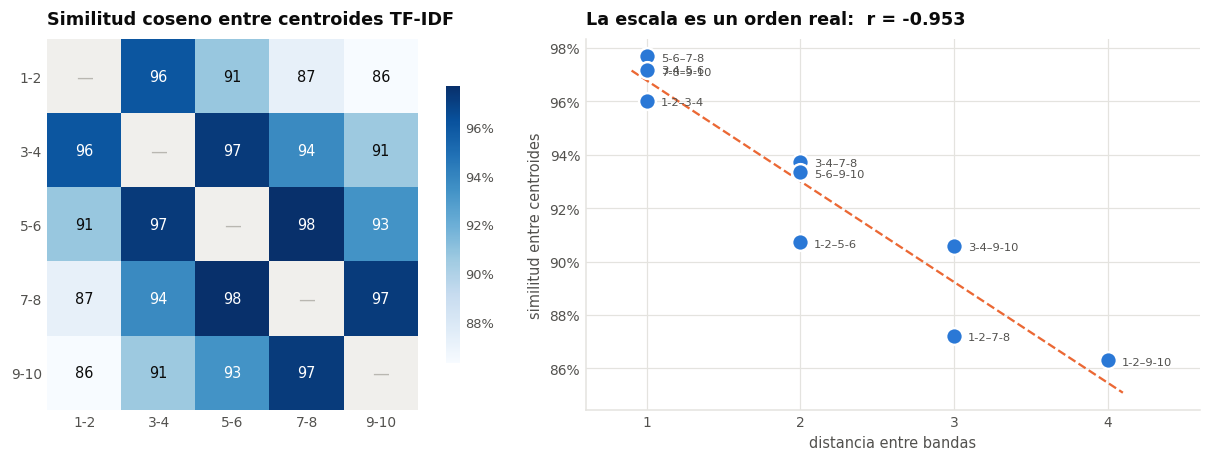

Confusión esperada, de mayor a menor similitud:
    97.7%     5-6 ↔   7-8
    97.2%     3-4 ↔   5-6
    97.2%     7-8 ↔  9-10
    96.0%     1-2 ↔   3-4
    93.7%     3-4 ↔   7-8
    93.3%     5-6 ↔  9-10
    90.7%     1-2 ↔   5-6
    90.6%     3-4 ↔  9-10
    87.2%     1-2 ↔   7-8
    86.3%     1-2 ↔  9-10

correlación entre distancia ordinal y similitud: r = -0.953


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

vec_cent = TfidfVectorizer(min_df=5, max_df=.5, sublinear_tf=True)
X_cent = vec_cent.fit_transform(df_train.texto)
centroides = np.vstack([np.asarray(X_cent[(df_train.y == k).values].mean(axis=0))
                        for k in range(5)])
S = cosine_similarity(centroides)

S_off = S.copy(); np.fill_diagonal(S_off, np.nan)
vmin, vmax = np.nanmin(S_off), np.nanmax(S_off)
mapa = mpl.colormaps["Blues"].with_extremes(bad="#f0efec")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.3),
                               gridspec_kw={"width_ratios": [1, 1.1]})

im = ax1.imshow(S_off, cmap=mapa, vmin=vmin, vmax=vmax)
ax1.set_xticks(range(5)); ax1.set_xticklabels(BANDAS, fontsize=9)
ax1.set_yticks(range(5)); ax1.set_yticklabels(BANDAS, fontsize=9)
umbral = vmin + (vmax - vmin) * .58
for i in range(5):
    for j in range(5):
        if i == j:
            ax1.text(j, i, "—", ha="center", va="center", fontsize=11, color="#b9b7b1")
        else:
            ax1.text(j, i, f"{S[i, j]*100:.0f}", ha="center", va="center", fontsize=9.5,
                     color="white" if S[i, j] > umbral else TINTA)
ax1.set_title("Similitud coseno entre centroides TF-IDF")
for e in ("top", "right", "bottom", "left"):
    ax1.spines[e].set_visible(False)
cb = fig.colorbar(im, ax=ax1, shrink=.75); cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8.5)
cb.ax.yaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")

# — derecha: ¿la similitud decae con la distancia ordinal?
iu = np.triu_indices(5, 1)
dist_ord = np.array([abs(i - j) for i, j in zip(*iu)])
sim_par = S[iu]
rho_geo = np.corrcoef(dist_ord, sim_par)[0, 1]
ax2.scatter(dist_ord, sim_par * 100, s=120, color=AZUL, edgecolor="white",
            linewidth=1.6, zorder=3)
b, a = np.polyfit(dist_ord, sim_par * 100, 1)
xs = np.linspace(.9, 4.1, 20)
ax2.plot(xs, a + b * xs, color=NARANJA, linestyle="--", linewidth=1.5, zorder=2)
for d, s_, (i, j) in zip(dist_ord, sim_par, zip(*iu)):
    ax2.annotate(f"{BANDAS[i]}–{BANDAS[j]}", (d, s_ * 100), textcoords="offset points",
                 xytext=(9, -3), fontsize=7.5, color=TINTA_2)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xlabel("distancia entre bandas")
ax2.set_ylabel("similitud entre centroides")
ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax2.set_title(f"La escala es un orden real:  r = {rho_geo:+.3f}")
ax2.set_xlim(.6, 4.6); ax2.grid(); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "08-similitud-clases"); plt.show()

pares = sorted(zip(sim_par, [(i, j) for i, j in zip(*iu)]), reverse=True)
print("Confusión esperada, de mayor a menor similitud:")
for s_, (i, j) in pares:
    print(f"   {s_*100:5.1f}%   {BANDAS[i]:>5s} ↔ {BANDAS[j]:>5s}")
print(f"\ncorrelación entre distancia ordinal y similitud: r = {rho_geo:+.3f}")

In [25]:
# Las tres predicciones salen de la geometría medida arriba en vez de elegirse a
# mano, para que el contraste de §8 no pueda acomodarse al resultado.
PRED_PAR = pares[0][1]                     # el par de centroides más parecidos
sim_media = [np.mean([S[k, j] for j in range(5) if j != k]) for k in range(5)]
PRED_PEOR = int(np.argmax(sim_media))      # la banda más parecida a todas las demás

print("Predicciones registradas antes de entrenar:")
print(f"   P1 · la matriz de confusión será una banda diagonal")
print(f"   P2 · la banda de peor F1 será {BANDAS[PRED_PEOR]}  "
      f"(similitud media con el resto: {sim_media[PRED_PEOR]:.3f})")
print(f"   P3 · el par más confundido será {BANDAS[PRED_PAR[0]]}↔{BANDAS[PRED_PAR[1]]}  "
      f"(similitud {S[PRED_PAR]:.3f})")

Predicciones registradas antes de entrenar:
   P1 · la matriz de confusión será una banda diagonal
   P2 · la banda de peor F1 será 5-6  (similitud media con el resto: 0.947)
   P3 · el par más confundido será 5-6↔7-8  (similitud 0.977)


La correlación entre la distancia en la escala y la similitud entre centroides es de r = −0,953. La
geometría del vocabulario reproduce el orden de las notas casi perfectamente sin que nadie se lo
haya dicho: los pares vecinos rondan el 97% de similitud y el par extremo, 1-2 contra 9-10, cae al
86%. La escala ordinal no es una convención de la interfaz de FilmAffinity. Está escrita en el
lenguaje. Es lo que anticipaba §3.1 al justificar el QWK, ahora con un número detrás.

La celda anterior deja registradas tres predicciones sobre la matriz de confusión. Salen de la
geometría, no las elegimos a mano, y §8 las contrasta contra lo observado:

> **P1.** La matriz de confusión será una **banda diagonal**: casi todo el error caerá en bandas
> vecinas y la confusión entre los extremos será prácticamente inexistente.
>
> **P2.** La banda de peor F1 será la que la celda imprime: la que más vocabulario comparte con
> todas las demás, que además es la que concentra las críticas de estructura mixta de §3.6.
>
> **P3.** El par más confundido será el de mayor similitud entre centroides.

Que las predicciones se calculen en código en vez de escribirse a mano no es un tecnicismo. Es lo
que impide ajustarlas después de ver la matriz.

---

## 4. Síntesis: lo que el EDA deja decidido

Ningún hiperparámetro de este notebook se elige por costumbre. La tabla es el puente entre la
exploración y los experimentos: a la izquierda la decisión, en medio la figura que la sostiene y a
la derecha el valor que queda fijado.

In [26]:
D_MODEL, N_CABEZAS, N_CAPAS, D_FF = 192, 4, 2, 512
BATCH, LR, EPOCAS = 64, 3e-4, 12

relleno_pct = np.maximum(MAX_LEN - largos, 0).sum() / (MAX_LEN * len(largos))

decisiones = pd.DataFrame([
    ("métrica de selección",      "§3.1", "macro-F1, con QWK como lectura del problema"),
    ("piso a batir",              "§3.1", f"accuracy {conteo.max()/conteo.sum():.3f} · QWK 0,000"),
    ("ponderación de clases",     "§3.1", f"sí: desbalance {conteo.max()/conteo.min():.1f}:1"),
    ("campo de entrada",          "§3.2", "título + cuerpo concatenados"),
    ("tokenizador",               "§3.3", f"BPE byte-level propio, {VOCAB_SIZE:,} tokens"),
    ("max_len",                   "§3.4", f"{MAX_LEN} tokens por presupuesto "
                                          f"(trunca {(largos > MAX_LEN).mean():.0%})"),
    ("enmascarado del relleno",   "§3.4", f"obligatorio: {relleno_pct:.0%} de posiciones vacías"),
    ("agregación por defecto",    "§3.4", "media enmascarada, no Flatten"),
    ("qué debe aprender",         "§3.5", "operadores (no, pero), no sólo adjetivos"),
    ("por qué transformer",       "§3.6", "la negación mueve la nota varios puntos sobre 10"),
    ("partición",                 "§3.7", "agrupada por película: hay confundidor medible"),
    ("confusión esperada",        "§3.8", f"banda diagonal; {BANDAS[PRED_PEOR]} la más difícil"),
    ("d_model / cabezas / capas", "—",    f"{D_MODEL} / {N_CABEZAS} / {N_CAPAS}"),
    ("optimización",              "—",    f"AdamW, lr={LR}, batch={BATCH}, {EPOCAS} épocas máx."),
], columns=["decisión", "figura", "valor"])

print(decisiones.to_string(index=False))

                 decisión figura                                            valor
     métrica de selección   §3.1      macro-F1, con QWK como lectura del problema
             piso a batir   §3.1                       accuracy 0.329 · QWK 0,000
    ponderación de clases   §3.1                             sí: desbalance 3.9:1
         campo de entrada   §3.2                     título + cuerpo concatenados
              tokenizador   §3.3             BPE byte-level propio, 16,000 tokens
                  max_len   §3.4          256 tokens por presupuesto (trunca 50%)
  enmascarado del relleno   §3.4            obligatorio: 20% de posiciones vacías
   agregación por defecto   §3.4                    media enmascarada, no Flatten
        qué debe aprender   §3.5         operadores (no, pero), no sólo adjetivos
      por qué transformer   §3.6 la negación mueve la nota varios puntos sobre 10
                partición   §3.7   agrupada por película: hay confundidor medible
       confusión

Las tres últimas filas el EDA no las fija, así que las justificamos aquí. `d_model=192` con 4
cabezas deja 48 dimensiones por cabeza, que da para que cada una represente algo distinto sin
inflar el modelo. Y 2 capas es el mínimo que permite componer dos saltos, del tipo `no` →
`consigue` → `emocionar`, con el añadido de que deja sitio para que la extracción de profundidad A6
pueda salir informativa hacia arriba y hacia abajo.

El *learning rate* merece un párrafo aparte. El notebook guía usa `2e-5`, que es un valor de ajuste
fino de un modelo preentrenado. Aplicado a pesos aleatorios deja el modelo subentrenado. Nosotros
usamos `3e-4` con calentamiento, el régimen habitual para un encoder de este tamaño entrenado desde
cero, y esa diferencia es una de las cinco que separan T0 de T1 en §5.

---

## 5. Los modelos

El orden es deliberado: primero el piso, después el rival serio, después la arquitectura del
notebook guía tal cual, y sólo al final la versión corregida. Así cada mejora tiene contra qué
medirse y ninguna se da por buena porque suene razonable.

### 5.1 B1 — TF-IDF y regresión logística, con y sin bigramas

El rival de verdad no es el modelo vacío, es este. Un TF-IDF con regresión logística es rápido,
robusto y sorprendentemente difícil de batir en clasificación de texto, así que es el listón que hay
que poner primero.

Además trae una ventaja de diseño: entrenar las dos variantes, unigramas y unigramas+bigramas,
**mide directamente cuánto vale el orden local**. Un bigrama es la ventana de orden más pequeña que
existe, y la diferencia entre ambas variantes es orden puro, sin nada más cambiado. Es la primera
respuesta parcial a H1 y la conseguimos por menos de un minuto de CPU.

In [27]:
resultados_b1 = {}
for ngramas, etiqueta in [((1, 1), "B1-tfidf-uni"), ((1, 2), "B1-tfidf-uni+bi")]:
    t0 = time.perf_counter()
    vectorizador = TfidfVectorizer(min_df=3, max_df=.5, sublinear_tf=True,
                                   ngram_range=ngramas)
    Xtr = vectorizador.fit_transform(df_train.texto)
    # class_weight balanceado: §3.1 midió 3,9:1 de desbalance y sin esto la
    # regresión se instala en las dos bandas altas.
    clf = LogisticRegression(max_iter=2000, C=4.0, random_state=SEED,
                             class_weight="balanced").fit(Xtr, df_train.y)
    seg = time.perf_counter() - t0
    pred = clf.predict(vectorizador.transform(df_val.texto))
    m = evaluar(df_val.y, pred, nombre=etiqueta, particion="val",
                notas=f"{seg:.1f}s, {Xtr.shape[1]:,} rasgos",
                verbose=(ngramas == (1, 2)))
    resultados_b1[etiqueta] = {"modelo": clf, "vectorizador": vectorizador,
                               "pred": pred, "m": m, "seg": seg, "rasgos": Xtr.shape[1]}
    print(f"[{etiqueta}] macro-F1 {m['macro_f1']:.4f}  QWK {m['qwk']:.4f}  ({seg:.1f}s)\n")

d_f1 = (resultados_b1["B1-tfidf-uni+bi"]["m"]["macro_f1"]
        - resultados_b1["B1-tfidf-uni"]["m"]["macro_f1"])
d_qwk = (resultados_b1["B1-tfidf-uni+bi"]["m"]["qwk"]
         - resultados_b1["B1-tfidf-uni"]["m"]["qwk"])
print(f"Aporte de los bigramas: {d_f1:+.4f} de macro-F1 y {d_qwk:+.4f} de QWK")

[B1-tfidf-uni] macro-F1 0.5045  QWK 0.6874  (57.2s)

── B1-tfidf-uni+bi  (val)
   macro-F1 0.5338   accuracy 0.5415   QWK 0.7192   MAE 0.5506   adyacente 0.9295

              precision    recall  f1-score   support

         1-2      0.580     0.607     0.593       684
         3-4      0.431     0.390     0.410       997
         5-6      0.523     0.542     0.533      2048
         7-8      0.580     0.553     0.566      2751
        9-10      0.547     0.589     0.567      1520

    accuracy                          0.541      8000
   macro avg      0.532     0.536     0.534      8000
weighted avg      0.541     0.541     0.541      8000

[B1-tfidf-uni+bi] macro-F1 0.5338  QWK 0.7192  (151.2s)

Aporte de los bigramas: +0.0293 de macro-F1 y +0.0318 de QWK


Los bigramas suben el macro-F1 de **0,504 a 0,534**, y el QWK de 0,687 a 0,719. Es el primer número
del notebook que habla del orden: **+0,029 por mirar pares de palabras contiguas**, sin tocar nada
más. Confirma §3.6 desde el lado del modelo, porque en un corpus donde el orden no importara esa
diferencia tendría que ser ruido.

Retén esa cifra. En §6.1 se compara contra lo que aporta la posición dentro del encoder, y la
comparación es la parte interesante de toda la entrega.

También hay que fijar las expectativas antes de seguir. Un TF-IDF con bigramas sobre 40.000
documentos es un rival duro y muy barato: 0,534 de macro-F1 en dos minutos y medio de CPU, con
398.073 rasgos y ni un parámetro entrenado por gradiente. Un encoder de dos capas construido desde
cero y sin preentrenamiento no parte como favorito. Si al final el TF-IDF sigue ganando, eso también
es un resultado, y lo decimos ahora para no acabar defendiendo al encoder por apego.

### 5.2 Preparación de los tensores

Se tokeniza una sola vez y se guardan los tensores en memoria. El corpus es pequeño y así el
tiempo de las quince corridas se va en cómputo y no en volver a tokenizar lo mismo.

In [28]:
from torch.utils.data import Dataset, DataLoader

class Criticas(Dataset):
    def __init__(self, df, tok, max_len):
        cod = tok(df.texto.tolist(), max_length=max_len, truncation=True,
                  padding="max_length", return_tensors="pt")
        self.ids  = cod["input_ids"]
        self.mask = cod["attention_mask"]
        self.y    = torch.tensor(df.y.values, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.ids[i], self.mask[i], self.y[i]

ds_train = Criticas(df_train, tokenizador, MAX_LEN)
ds_val   = Criticas(df_val,   tokenizador, MAX_LEN)
ds_test  = Criticas(df_test,  tokenizador, MAX_LEN)

print(f"tensores: train {tuple(ds_train.ids.shape)}   val {tuple(ds_val.ids.shape)}   "
      f"test {tuple(ds_test.ids.shape)}")
print(f"posiciones de relleno en entrenamiento: "
      f"{(ds_train.mask == 0).float().mean():.1%} del total")
print(f"tokens reales por crítica: media {ds_train.mask.sum(1).float().mean():.1f} "
      f"de {MAX_LEN} posiciones")

tensores: train (40000, 256)   val (8000, 256)   test (8000, 256)
posiciones de relleno en entrenamiento: 20.3% del total
tokens reales por crítica: media 203.9 de 256 posiciones


La cifra de relleno que imprime la celda conviene tenerla a mano durante toda la sección siguiente.
Cada posición vacía que la arquitectura trate como si fuera texto es capacidad desperdiciada, y peor
aún, atención que se le quita a los tokens que sí dicen algo. Por eso la máscara de §5.3 se
implementa con cuidado, y por eso A1 existe como extracción.

### 5.3 El encoder, pieza por pieza

Implementamos la arquitectura desde cero. Todo está gobernado por una única `Config`, de modo que
cada extracción de §6 sea el cambio de **un solo campo** — y no una copia del modelo con
modificaciones sueltas, que es la forma habitual de que una comparación deje de comparar.

La configuración incluye dos interruptores que no existirían en un modelo de producción:
`modo_guia` y `mascara_rota`. Sirven para **reproducir exactamente** los defectos del notebook de
clase y medirlos, en vez de darlos por importantes sin evidencia.

In [ ]:
@dataclass
class Config:
    """Una extracción = una copia de esta configuración con un campo cambiado."""
    vocab_size: int = 16_000
    max_len:    int = 128
    pad_id:     int = 0
    d_model:    int = 192
    n_cabezas:  int = 4
    n_capas:    int = 2
    d_ff:       int = 512
    dropout:  float = 0.10
    n_clases:   int = 5

    pos:     str = "sinusoidal"   # sinusoidal | aprendido | ninguno
    pooling: str = "media"        # media | flatten | cls | atencion
    cabeza:  str = "softmax"      # softmax | coral

    # Interruptores que reproducen los defectos del notebook guía.
    modo_guia:    bool = False    # post-norm y SIN conexiones residuales
    mascara_rota: bool = False    # rellena con -9e-15 en vez de -1e4

    def variante(self, **cambios):
        return replace(self, **cambios)


def largo_secuencia(cfg):
    """Longitud real que ve el encoder: el token [CLS] ocupa una posición extra."""
    return cfg.max_len + (1 if cfg.pooling == "cls" else 0)


CFG_BASE = Config(vocab_size=len(tokenizador), max_len=MAX_LEN, pad_id=PAD_ID,
                  d_model=D_MODEL, n_cabezas=N_CABEZAS, n_capas=N_CAPAS, d_ff=D_FF)
print(CFG_BASE)

Config(vocab_size=16000, max_len=256, pad_id=1, d_model=192, n_cabezas=4, n_capas=2, d_ff=512, dropout=0.1, n_clases=5, pos='sinusoidal', pooling='media', cabeza='softmax', modo_guia=False, mascara_rota=False)


#### Codificación posicional

La auto-atención es **permutacionalmente invariante**: si se barajan los tokens de entrada, las
salidas se barajan igual pero no cambian. Sin información de posición, un encoder es literalmente
una bolsa de palabras con interacciones. Ese hecho es lo que convierte a esta clase en el
instrumento de medida de H1: poner `pos="ninguno"` no rompe el modelo, lo **convierte** en un
modelo de bolsa de palabras contextual, y la diferencia con la versión sinusoidal es el valor del
orden.

Implementamos los tres modos. Ojo con el modo aprendido, que indexa por **posición**;
la clase equivalente del notebook guía indexa por tamaño de vocabulario, que es una fila por token
del diccionario y no por lugar en la frase.

In [30]:
class CodificacionPosicional(nn.Module):
    """PE(pos, 2i) = sin(pos / 10000^(2i/d)) ; PE(pos, 2i+1) = cos(...)"""

    def __init__(self, cfg):
        super().__init__()
        self.modo = cfg.pos

        if self.modo == "sinusoidal":
            L = largo_secuencia(cfg)
            pos = torch.arange(L).unsqueeze(1).float()                # (L, 1)
            i   = torch.arange(cfg.d_model).unsqueeze(0).float()      # (1, D)
            # El exponente usa el índice del PAR (i//2), no el de la dimensión:
            # las posiciones 2i y 2i+1 comparten frecuencia y sólo cambian de fase.
            div = torch.pow(10_000.0, (2 * (i // 2)) / cfg.d_model)
            ang = pos / div
            pe = torch.zeros(L, cfg.d_model)
            pe[:, 0::2] = torch.sin(ang[:, 0::2])
            pe[:, 1::2] = torch.cos(ang[:, 1::2])
            self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

        elif self.modo == "aprendido":
            # Una fila por POSICIÓN, no por token del vocabulario.
            self.pe = nn.Embedding(largo_secuencia(cfg), cfg.d_model)

        elif self.modo != "ninguno":
            raise ValueError(f"modo de posición desconocido: {self.modo}")

    def forward(self, x):                       # x: (B, L, D)
        if self.modo == "sinusoidal":
            return x + self.pe[:, : x.size(1)]
        if self.modo == "aprendido":
            posiciones = torch.arange(x.size(1), device=x.device)
            return x + self.pe(posiciones).unsqueeze(0)
        return x                                # 'ninguno'

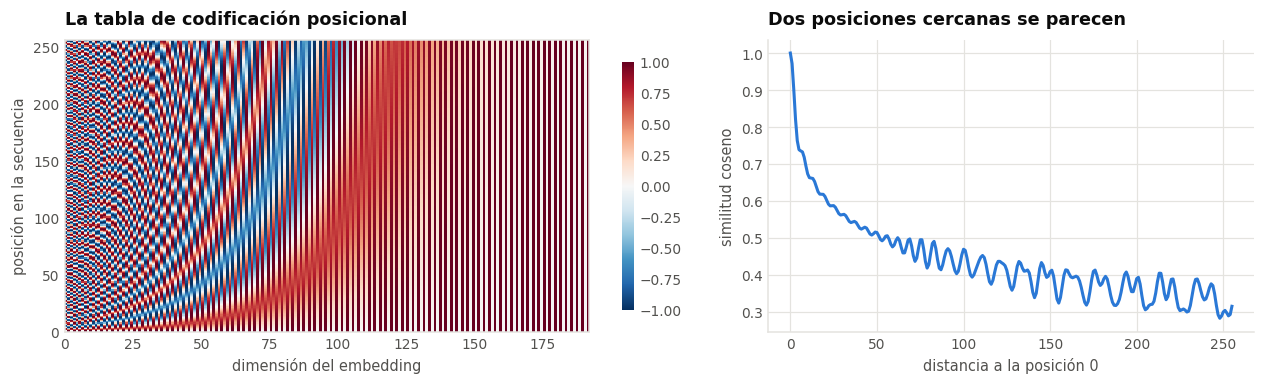

No hay que leer los valores uno a uno: lo único que el modelo necesita es que
el vector de la posición p sea distinguible del de la posición q y que la
similitud entre ambos dependa de |p-q|. El panel derecho confirma las dos cosas.


In [31]:
# Cómo se ve la tabla sinusoidal, y por qué sirve.
pe_demo = CodificacionPosicional(CFG_BASE).pe.squeeze(0).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.6),
                               gridspec_kw={"width_ratios": [1.35, 1]})
im = ax1.pcolormesh(pe_demo, cmap="RdBu_r", vmin=-1, vmax=1)
ax1.set_xlabel("dimensión del embedding"); ax1.set_ylabel("posición en la secuencia")
ax1.set_title("La tabla de codificación posicional")
cb = fig.colorbar(im, ax=ax1, shrink=.85); cb.outline.set_visible(False)

# La propiedad que de verdad importa: el producto punto decae con la distancia.
sim = (pe_demo @ pe_demo[0]) / (np.linalg.norm(pe_demo, axis=1) * np.linalg.norm(pe_demo[0]))
ax2.plot(sim, color=AZUL, linewidth=2)
ax2.set_xlabel("distancia a la posición 0"); ax2.set_ylabel("similitud coseno")
ax2.set_title("Dos posiciones cercanas se parecen")
ax2.grid(); ax2.set_axisbelow(True); limpiar(ax2)
plt.tight_layout(); guardar(fig, "09-codificacion-posicional"); plt.show()

print("No hay que leer los valores uno a uno: lo único que el modelo necesita es que")
print("el vector de la posición p sea distinguible del de la posición q y que la")
print("similitud entre ambos dependa de |p-q|. El panel derecho confirma las dos cosas.")

#### Atención multi-cabeza, y el enmascarado del relleno

$$\text{Atención}(Q,K,V) = \text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

Tres decisiones de implementación merecen comentario, porque las tres se apartan del notebook guía:

1. **Las capas lineales usan `cfg.d_model`**, no una variable global del notebook. En el guía, la
   clase recibe `embed_size` como parámetro pero construye las proyecciones con una global; sólo
   funciona mientras las dos coincidan por casualidad.
2. **La comprobación de divisibilidad usa el módulo `%`.** El guía escribe `embed_size & num_heads
   == 0`, que es un *and* bit a bit: con 128 y 8 devuelve 0 y la comprobación pasa por coincidencia
   entre potencias de dos, no porque la división sea exacta.
3. **El valor de relleno.** El guía enmascara con `-9e-15`, un número que es indistinguible de cero
   a efectos del *softmax*. Con `mascara_rota=True` lo reproducimos para poder medirlo; el valor
   correcto es `-1e4`, que satura el *softmax* a cero y sigue siendo seguro en media precisión, a
   diferencia de `-inf`, que produce `NaN` al multiplicarse por cero.

In [32]:
class AtencionMulticabeza(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        # Módulo, no AND bit a bit: 12 y 8 deben fallar aquí, no más abajo.
        assert cfg.d_model % cfg.n_cabezas == 0, \
            "d_model debe ser divisible por n_cabezas"
        self.h  = cfg.n_cabezas
        self.dk = cfg.d_model // cfg.n_cabezas

        self.q = nn.Linear(cfg.d_model, cfg.d_model)
        self.k = nn.Linear(cfg.d_model, cfg.d_model)
        self.v = nn.Linear(cfg.d_model, cfg.d_model)
        self.salida = nn.Linear(cfg.d_model, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.relleno = -9e-15 if cfg.mascara_rota else -1e4

    def forward(self, x, mask=None):
        B, L, D = x.shape

        def cabezas(t):                                    # (B,L,D) -> (B,h,L,dk)
            return t.view(B, L, self.h, self.dk).transpose(1, 2)

        q, k, v = cabezas(self.q(x)), cabezas(self.k(x)), cabezas(self.v(x))

        logits = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)   # (B,h,L,L)
        if mask is not None:
            # Se enmascaran las CLAVES: ninguna consulta puede mirar al relleno.
            logits = logits.masked_fill(mask[:, None, None, :] == 0, self.relleno)

        pesos = torch.softmax(logits, dim=-1)
        ctx = (self.drop(pesos) @ v).transpose(1, 2).reshape(B, L, D)
        return self.salida(ctx), pesos

In [ ]:
# VERIFICACIÓN 1 — la que el notebook guía no hace, y que le esconde el error.
# Se mide qué fracción de la masa de atención cae sobre posiciones de relleno.
REALES = 12
ids_p = torch.randint(2, 500, (8, 64)); ids_p[:, REALES:] = PAD_ID
mask_p = torch.zeros(8, 64, dtype=torch.long); mask_p[:, :REALES] = 1

print(f"Secuencia de prueba: {REALES} tokens reales y {64-REALES} de relleno "
      f"({(64-REALES)/64:.0%} relleno)\n")
for rota in (False, True):
    cfg_p = CFG_BASE.variante(max_len=64, mascara_rota=rota)
    att = AtencionMulticabeza(cfg_p).eval()
    with torch.no_grad():
        _, pesos = att(torch.randn(8, 64, cfg_p.d_model), mask_p)
    masa = pesos[:, :, :REALES, REALES:].sum(-1).mean().item()
    print(f"   relleno={'-9e-15 (guía)' if rota else '-1e4 (correcto)':16s} "
          f"→ masa de atención sobre el PAD = {masa:.4f}  ({masa:.1%})")
print("\nEl valor del guía no enmascara: deja que la mayor parte de la atención de cada")
print("token real se reparta entre posiciones vacías. Esta es la extracción A1 de §6.")

Secuencia de prueba: 12 tokens reales y 52 de relleno (81% relleno)

   relleno=-1e4 (correcto)  → masa de atención sobre el PAD = 0.0000  (0.0%)
   relleno=-9e-15 (guía)    → masa de atención sobre el PAD = 0.8037  (80.4%)

El valor del guía no enmascara: deja que la mayor parte de la atención de cada
token real se reparta entre posiciones vacías. Esta es la ablación A1 de §6.


#### El bloque del encoder, y las conexiones residuales

El paper define cada sub-capa como $\text{LayerNorm}(x + \text{Sublayer}(x))$. Las dos piezas
importan: la normalización estabiliza la escala y **la suma es lo que deja pasar el gradiente**.

El bloque del notebook guía omite la suma en las dos sub-capas — escribe
`attn_output = self.layer_norm1(attn_output)` y `return self.layer_norm2(ffn_out)` — de modo que
no es un bloque transformer sino una pila de transformaciones sin atajo. Con `modo_guia=True` lo
reproducimos tal cual; con `False` usamos la variante **pre-norm**, que es el estándar actual para
entrenar desde cero sin calentamiento agresivo.

In [34]:
class BloqueEncoder(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.modo_guia = cfg.modo_guia
        self.att = AtencionMulticabeza(cfg)
        self.ffn = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(),
            nn.Dropout(cfg.dropout), nn.Linear(cfg.d_ff, cfg.d_model),
        )
        self.norma1 = nn.LayerNorm(cfg.d_model)
        self.norma2 = nn.LayerNorm(cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, mask=None):
        if self.modo_guia:
            a, pesos = self.att(x, mask)
            a = self.norma1(self.drop(a))             # falta el  x +
            return self.norma2(self.ffn(a)), pesos    # falta el  a +

        a, pesos = self.att(self.norma1(x), mask)     # pre-norm
        x = x + self.drop(a)
        x = x + self.drop(self.ffn(self.norma2(x)))
        return x, pesos

In [35]:
class Agregador(nn.Module):
    """Cuatro formas de pasar de (B,L,D) a (B,D)."""

    def __init__(self, cfg):
        super().__init__()
        self.modo = cfg.pooling
        if self.modo == "flatten":
            self.proy = nn.Linear(largo_secuencia(cfg) * cfg.d_model, cfg.d_model)
        elif self.modo == "atencion":
            self.consulta = nn.Linear(cfg.d_model, 1)

    def forward(self, x, mask):
        if self.modo == "media":            # media SOBRE LOS TOKENS REALES
            m = mask.unsqueeze(-1).float()
            return (x * m).sum(1) / m.sum(1).clamp(min=1.0)
        if self.modo == "cls":
            return x[:, 0]
        if self.modo == "flatten":          # lo que hace el notebook guía
            return self.proy(x.flatten(1))
        if self.modo == "atencion":         # pooling con consulta aprendida
            s = self.consulta(x).squeeze(-1).masked_fill(mask == 0, -1e4)
            return (torch.softmax(s, -1).unsqueeze(-1) * x).sum(1)
        raise ValueError(self.modo)


class ClasificadorTransformer(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.emb = nn.Embedding(cfg.vocab_size, cfg.d_model, padding_idx=cfg.pad_id)
        self.cls = nn.Parameter(torch.zeros(1, 1, cfg.d_model)) if cfg.pooling == "cls" else None
        self.pos = CodificacionPosicional(cfg)
        self.drop = nn.Dropout(cfg.dropout)
        self.bloques = nn.ModuleList([BloqueEncoder(cfg) for _ in range(cfg.n_capas)])
        self.norma_final = nn.Identity() if cfg.modo_guia else nn.LayerNorm(cfg.d_model)
        self.agregador = Agregador(cfg)

        if cfg.cabeza == "softmax":
            self.salida = nn.Linear(cfg.d_model, cfg.n_clases)
        else:
            # CORAL (Cao, Mirjalili y Raschka, 2020): un único vector de pesos
            # compartido y K-1 sesgos. Al compartir w los umbrales no se cruzan
            # y la predicción entera nunca puede ser ordinalmente incoherente.
            self.salida = nn.Linear(cfg.d_model, 1, bias=False)
            self.umbrales = nn.Parameter(torch.linspace(2.0, -2.0, cfg.n_clases - 1))

    def forward(self, ids, mask, devolver_atencion=False):
        x = self.emb(ids)
        if self.cls is not None:
            x = torch.cat([self.cls.expand(x.size(0), -1, -1), x], dim=1)
            mask = torch.cat([torch.ones_like(mask[:, :1]), mask], dim=1)
        x = self.drop(self.pos(x))

        atenciones = []
        for bloque in self.bloques:
            x, pesos = bloque(x, mask)
            if devolver_atencion:
                atenciones.append(pesos)

        h = self.agregador(self.norma_final(x), mask)
        z = self.salida(h)
        if self.cfg.cabeza == "coral":
            z = z + self.umbrales                 # (B, K-1)
        return (z, atenciones) if devolver_atencion else z


def perdida_de(z, y, cfg):
    if cfg.cabeza == "softmax":
        # Sobre logits crudos. El guía aplica LogSoftmax en el modelo y además
        # cross_entropy en la pérdida, que vuelve a aplicar log_softmax: el
        # gradiente sale aplastado por una doble normalización.
        return F.cross_entropy(z, y)
    objetivo = (y.unsqueeze(1) > torch.arange(cfg.n_clases - 1, device=y.device)).float()
    return F.binary_cross_entropy_with_logits(z, objetivo)


def decodificar(z, cfg):
    if cfg.cabeza == "softmax":
        return z.argmax(-1)
    return (torch.sigmoid(z) > 0.5).sum(1)        # 0..K-1, siempre ordenado

In [ ]:
# VERIFICACIÓN 2 — el efecto de los residuales sobre el gradiente, medido.
# Mismo pooling y misma máscara en ambos: lo único que cambia es la suma.
print("Gradiente medio en las proyecciones de consulta, por capa (modelo de 4 capas):\n")
for guia in (True, False):
    torch.manual_seed(SEED)
    cfg_g = CFG_BASE.variante(modo_guia=guia, n_capas=4, dropout=0.0, max_len=64)
    m_g = ClasificadorTransformer(cfg_g)
    perdida_de(m_g(ids_p, mask_p), torch.randint(0, 5, (8,)), cfg_g).backward()
    g = [m_g.bloques[i].att.q.weight.grad.abs().mean().item() for i in range(4)]
    print(f"   residuales={'NO (guía)' if guia else 'SÍ       '}  "
          + "  ".join(f"capa{i}={v:.1e}" for i, v in enumerate(g))
          + f"   ·  razón máx/mín = {max(g)/min(g):.1e}")
print("\nSin residuales el gradiente se reparte de forma tan desigual entre capas que")
print("difiere en varios órdenes de magnitud: las que menos reciben no aprenden nada.")
print("Con residuales queda prácticamente plano. Esta es la extracción A2 de §6.")

Gradiente medio en las proyecciones de consulta, por capa (modelo de 4 capas):

   residuales=NO (guía)  capa0=1.3e-03  capa1=4.1e-05  capa2=3.8e-10  capa3=1.2e-10   ·  razón máx/mín = 1.0e+07
   residuales=SÍ         capa0=2.1e-04  capa1=1.7e-04  capa2=1.8e-04  capa3=1.9e-04   ·  razón máx/mín = 1.2e+00

Sin residuales el gradiente se reparte de forma tan desigual entre capas que
difiere en varios órdenes de magnitud: las que menos reciben no aprenden nada.
Con residuales queda prácticamente plano. Esta es la ablación A2 de §6.


In [ ]:
# VERIFICACIÓN 3 — sobreajuste deliberado de 64 ejemplos.
# Si el modelo no memoriza 64 críticas, hay un error de implementación y no
# tiene sentido seguir: cualquier extracción estaría midiendo el error, no el diseño.
torch.manual_seed(SEED)
m_ov = ClasificadorTransformer(CFG_BASE.variante(dropout=0.0)).to(DEVICE)
ids_ov, mask_ov, y_ov = (ds_train.ids[:64].to(DEVICE), ds_train.mask[:64].to(DEVICE),
                         ds_train.y[:64].to(DEVICE))
opt_ov = torch.optim.AdamW(m_ov.parameters(), lr=3e-3)
m_ov.train()
for paso in range(400):
    p_ov = perdida_de(m_ov(ids_ov, mask_ov), y_ov, CFG_BASE)
    opt_ov.zero_grad(); p_ov.backward(); opt_ov.step()
m_ov.eval()
with torch.no_grad():
    acc_ov = (decodificar(m_ov(ids_ov, mask_ov), CFG_BASE) == y_ov).float().mean().item()
print(f"sobreajuste de 64 críticas: pérdida {p_ov.item():.4f}   accuracy {acc_ov:.3f}")
assert acc_ov >= 0.90, "el modelo no logra memorizar 64 ejemplos: revisar la implementación"
print("La implementación tiene capacidad de aprender. Se puede continuar.")
del m_ov, opt_ov

sobreajuste de 64 críticas: pérdida 0.0001   accuracy 1.000
La implementación tiene capacidad de aprender. Se puede continuar.


### 5.4 El bucle de entrenamiento

Nada exótico: AdamW, calentamiento lineal seguido de decaimiento coseno, recorte de gradiente,
precisión mixta cuando hay GPU, y parada temprana sobre el macro-F1 de validación restaurando el
mejor estado. La única decisión con contenido es que **el criterio de selección es el macro-F1**,
el mismo para todos los experimentos, para que ninguna variante se beneficie de un criterio propio.

In [38]:
def semillar(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


@torch.no_grad()
def predecir(modelo, loader, cfg):
    modelo.eval()
    salidas, reales = [], []
    for ids, mask, y in loader:
        salidas.append(modelo(ids.to(DEVICE), mask.to(DEVICE)).float().cpu())
        reales.append(y)
    return torch.cat(salidas), torch.cat(reales)


def entrenar(cfg, semilla, epocas=EPOCAS, paciencia=3, lr=LR, batch=BATCH, etiqueta="modelo",
             ds_tr=None, ds_va=None):
    # ds_tr / ds_va sólo se pasan en §6.3, donde hay que entrenar el mismo modelo
    # sobre una partición distinta. En todo lo demás son los conjuntos globales.
    ds_tr = ds_train if ds_tr is None else ds_tr
    ds_va = ds_val if ds_va is None else ds_va
    semillar(semilla)
    g = torch.Generator().manual_seed(semilla)
    dl_train = DataLoader(ds_tr, batch_size=batch, shuffle=True, generator=g,
                          num_workers=2, pin_memory=(DEVICE == "cuda"), drop_last=True)
    dl_val = DataLoader(ds_va, batch_size=512, num_workers=2)

    modelo = ClasificadorTransformer(cfg).to(DEVICE)
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=0.01)
    total = epocas * len(dl_train)
    calentamiento = max(1, int(0.06 * total))

    def factor(paso):
        if paso < calentamiento:
            return paso / calentamiento
        avance = (paso - calentamiento) / max(1, total - calentamiento)
        return 0.5 * (1 + math.cos(math.pi * avance))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, factor)
    escalador = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    historia, mejor_f1, mejor_estado, sin_mejora = [], -1.0, None, 0
    t0 = time.perf_counter()

    for epoca in range(1, epocas + 1):
        modelo.train()
        suma, vistos = 0.0, 0
        for ids, mask, y in dl_train:
            ids, mask, y = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                p = perdida_de(modelo(ids, mask), y, cfg)
            opt.zero_grad(set_to_none=True)
            escalador.scale(p).backward()
            escalador.unscale_(opt)
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            escalador.step(opt); escalador.update(); sched.step()
            suma += p.item() * y.size(0); vistos += y.size(0)

        z_val, y_val = predecir(modelo, dl_val, cfg)
        pred_val = decodificar(z_val, cfg).numpy()
        f1_val = f1_score(y_val.numpy(), pred_val, average="macro")
        historia.append({"epoca": epoca, "train_loss": suma / vistos,
                         "val_loss": perdida_de(z_val, y_val, cfg).item(),
                         "val_f1": f1_val,
                         "val_qwk": cohen_kappa_score(y_val.numpy(), pred_val,
                                                      weights="quadratic")})

        if f1_val > mejor_f1:
            mejor_f1, sin_mejora = f1_val, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                print(f"      parada temprana en la época {epoca}")
                break

    modelo.load_state_dict(mejor_estado)
    seg = time.perf_counter() - t0
    n_par = sum(q.numel() for q in modelo.parameters())
    print(f"      [{etiqueta} · semilla {semilla}] mejor val macro-F1 {mejor_f1:.4f} · "
          f"{len(historia)} épocas · {seg:.0f}s · {n_par:,} parámetros")
    return modelo, pd.DataFrame(historia), seg, n_par


SEMILLAS = (42, 7, 2024)

def correr(etiqueta, cfg, semillas=(SEED,), **kw):
    """Entrena una configuración con una o varias semillas y registra cada corrida."""
    print(f"── {etiqueta}")
    corridas = []
    for s in semillas:
        modelo, hist, seg, n_par = entrenar(cfg, s, etiqueta=etiqueta, **kw)
        z, y = predecir(modelo, DataLoader(ds_val, batch_size=512, num_workers=2), cfg)
        pred = decodificar(z, cfg).numpy()
        m = evaluar(y.numpy(), pred, nombre=f"{etiqueta}-s{s}", particion="val",
                    notas=f"{seg:.0f}s, {n_par:,} params", verbose=False)
        corridas.append({"semilla": s, "modelo": modelo, "historia": hist, "cfg": cfg,
                         "pred": pred, "reales": y.numpy(), "m": m, "seg": seg, "n_par": n_par})
    f1s = [c["m"]["macro_f1"] for c in corridas]
    qwks = [c["m"]["qwk"] for c in corridas]
    print(f"   → macro-F1 {np.mean(f1s):.4f} ± {np.std(f1s):.4f}   "
          f"QWK {np.mean(qwks):.4f} ± {np.std(qwks):.4f}\n")
    return corridas

### 5.5 T0 — la arquitectura del notebook guía, replicada

Antes de corregir nada, hay que medir el punto de partida. T0 reproduce las cinco decisiones del
notebook de clase sobre nuestro corpus:

| Decisión del guía | Qué hace |
|---|---|
| `masked_fill(..., -9e-15)` | no enmascara: el relleno recibe atención normal |
| sin conexiones residuales | el gradiente no tiene atajo entre capas |
| `Flatten` + densa | agrega concatenando las 128 posiciones |
| `LogSoftmax` + `cross_entropy` | aplica dos veces la normalización logarítmica |
| `lr = 2e-5` | tasa de ajuste fino usada para entrenar desde cero |

La doble *softmax* no puede activarse con un interruptor de `Config` porque cambia la pérdida, no
la arquitectura, así que se aplica aquí de forma explícita.

In [39]:
CFG_T0 = CFG_BASE.variante(modo_guia=True, mascara_rota=True, pooling="flatten")

def perdida_doble_softmax(z, y, cfg):
    """Réplica del guía: LogSoftmax en el modelo y cross_entropy en la pérdida."""
    return F.cross_entropy(F.log_softmax(z, dim=1), y)

_perdida_original = perdida_de
perdida_de = perdida_doble_softmax          # se restaura justo después de T0
corridas_t0 = correr("T0-replica-guia", CFG_T0, semillas=(SEED,), lr=2e-5)
perdida_de = _perdida_original

print(f"parámetros de T0: {corridas_t0[0]['n_par']:,}")
agregador_t0 = sum(q.numel() for q in
                   ClasificadorTransformer(CFG_T0).agregador.parameters())
print(f"de los cuales, sólo la capa de Flatten: {agregador_t0:,} "
      f"({agregador_t0/corridas_t0[0]['n_par']:.1%} del modelo)")

── T0-replica-guia
      parada temprana en la época 9
      [T0-replica-guia · semilla 42] mejor val macro-F1 0.3581 · 9 épocas · 238s · 13,202,949 parámetros
   → macro-F1 0.3581 ± 0.0000   QWK 0.4051 ± 0.0000

parámetros de T0: 13,202,949
de los cuales, sólo la capa de Flatten: 9,437,376 (71.5% del modelo)


### 5.6 T1 — la versión corregida

Cinco cambios respecto a T0, cada uno con su razón ya establecida:

1. **Máscara con `-1e4`** — §3.4 midió qué fracción de las posiciones es relleno.
2. **Conexiones residuales y pre-norm** — la verificación 2 midió el efecto sobre el gradiente.
3. **Media enmascarada en lugar de `Flatten`** — quita la capa que concentra los parámetros y, a
   diferencia de `Flatten`, no le asigna pesos propios a posiciones que suelen estar vacías.
4. **Pérdida sobre logits crudos** — sin la doble normalización.
5. **`lr = 3e-4` con calentamiento** — régimen de entrenamiento desde cero.

Se entrena con **tres semillas**, no con una. Una corrida suelta no sirve para comparar
arquitecturas: la inicialización aleatoria y el orden de los lotes mueven el macro-F1 lo suficiente
como para que cualquier extracción parezca un efecto. La dispersión entre semillas es la vara con la
que se medirán todas las ablaciones de §6, y por eso se establece **antes** de mirarlas.

In [ ]:
corridas_t1 = correr("T1-corregido", CFG_BASE, semillas=SEMILLAS)

f1_t1 = np.array([c["m"]["macro_f1"] for c in corridas_t1])
qwk_t1 = np.array([c["m"]["qwk"] for c in corridas_t1])
SD_SEMILLA = float(f1_t1.std())
SD_SEMILLA_QWK = float(qwk_t1.std())

print(f"T0 (réplica del guía) : macro-F1 {corridas_t0[0]['m']['macro_f1']:.4f}   "
      f"QWK {corridas_t0[0]['m']['qwk']:.4f}   {corridas_t0[0]['n_par']:,} params")
print(f"T1 (corregido)        : macro-F1 {f1_t1.mean():.4f} ± {SD_SEMILLA:.4f}   "
      f"QWK {qwk_t1.mean():.4f}   {corridas_t1[0]['n_par']:,} params")
print(f"\ndiferencia T1 − T0    : {f1_t1.mean() - corridas_t0[0]['m']['macro_f1']:+.4f} macro-F1")
print(f"dispersión entre semillas de T1 (±1 sd): {SD_SEMILLA:.4f}")
print(f"→ a partir de aquí, una extracción sólo se considera real si mueve el macro-F1")
print(f"  más de 2 sd = {2*SD_SEMILLA:.4f}")

── T1-corregido
      parada temprana en la época 9
      [T1-corregido · semilla 42] mejor val macro-F1 0.4774 · 9 épocas · 225s · 3,765,957 parámetros
      [T1-corregido · semilla 7] mejor val macro-F1 0.4836 · 12 épocas · 302s · 3,765,957 parámetros
      [T1-corregido · semilla 2024] mejor val macro-F1 0.4830 · 12 épocas · 301s · 3,765,957 parámetros
   → macro-F1 0.4813 ± 0.0028   QWK 0.6352 ± 0.0095

T0 (réplica del guía) : macro-F1 0.3581   QWK 0.4051   13,202,949 params
T1 (corregido)        : macro-F1 0.4813 ± 0.0028   QWK 0.6352   3,765,957 params

diferencia T1 − T0    : +0.1232 macro-F1
dispersión entre semillas de T1 (±1 sd): 0.0028
→ a partir de aquí, una ablación sólo se considera real si mueve el macro-F1
  más de 2 sd = 0.0056


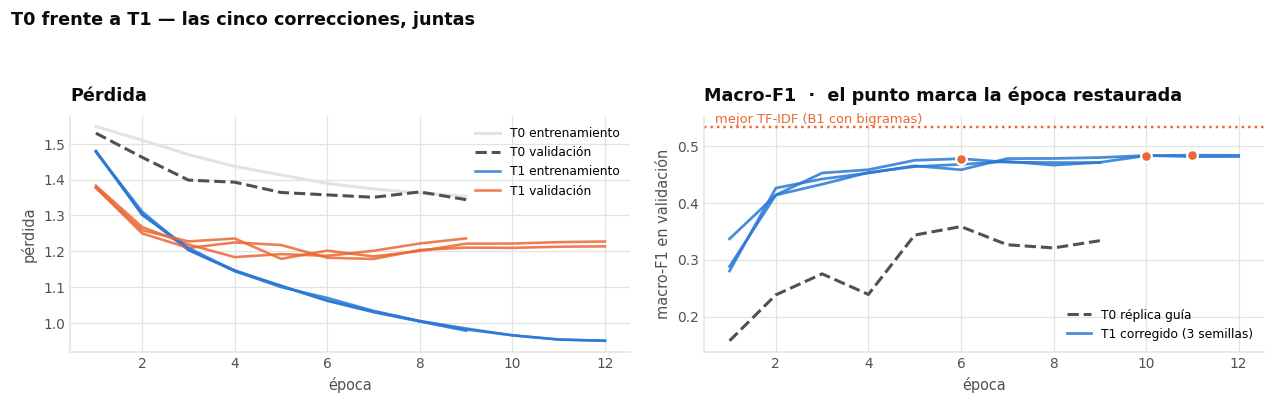

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.7))

h0 = corridas_t0[0]["historia"]
ax1.plot(h0.epoca, h0.train_loss, color=MALLA, linewidth=2, label="T0 entrenamiento")
ax1.plot(h0.epoca, h0.val_loss, color=TINTA_2, linewidth=2, linestyle="--", label="T0 validación")
for i, c in enumerate(corridas_t1):
    h = c["historia"]
    ax1.plot(h.epoca, h.train_loss, color=AZUL, linewidth=1.7, alpha=.85,
             label="T1 entrenamiento" if i == 0 else None)
    ax1.plot(h.epoca, h.val_loss, color=NARANJA, linewidth=1.7, alpha=.85,
             label="T1 validación" if i == 0 else None)
ax1.set_xlabel("época"); ax1.set_ylabel("pérdida")
ax1.set_title("Pérdida"); ax1.legend(loc="best", fontsize=8)
ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

ax2.plot(h0.epoca, h0.val_f1, color=TINTA_2, linewidth=2, linestyle="--", label="T0 réplica guía")
for i, c in enumerate(corridas_t1):
    h = c["historia"]
    ax2.plot(h.epoca, h.val_f1, color=AZUL, linewidth=1.8, alpha=.85,
             label="T1 corregido (3 semillas)" if i == 0 else None)
    mejor = h.val_f1.idxmax()
    ax2.plot(h.epoca[mejor], h.val_f1[mejor], "o", color=NARANJA, markersize=7,
             markeredgecolor="white", markeredgewidth=1.4, zorder=5)
techo_b1 = max(v["m"]["macro_f1"] for v in resultados_b1.values())
ax2.axhline(techo_b1, color=NARANJA, linestyle=":", linewidth=1.6)
ax2.text(.02, techo_b1 + .006, "mejor TF-IDF (B1 con bigramas)",
         transform=ax2.get_yaxis_transform(), fontsize=8.5, color=NARANJA)
ax2.set_xlabel("época"); ax2.set_ylabel("macro-F1 en validación")
ax2.set_title("Macro-F1  ·  el punto marca la época restaurada")
ax2.legend(loc="lower right", fontsize=8); ax2.grid(); ax2.set_axisbelow(True); limpiar(ax2)

fig.suptitle("T0 frente a T1 — las cinco correcciones, juntas", x=.005, ha="left",
             fontsize=11.5, fontweight="bold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .92]); guardar(fig, "10-curvas-t0-t1"); plt.show()

Las dos curvas de T0 son las de un modelo que no está aprendiendo lo que debería: con `lr=2e-5` y
sin residuales, la pérdida baja despacio y el macro-F1 de validación se queda muy por debajo. La
diferencia es grande, **+0,123 de macro-F1** (0,358 → 0,481), y además T1 lo consigue con la cuarta
parte de los parámetros: 3,8 millones frente a 13,2, porque el `Flatten` de T0 se lleva él solo el
71% del modelo.

Cuidado con atribuir esos doce puntos a un único factor. Las cinco correcciones están aplicadas a la
vez, y separarlas es justo el trabajo de §6. Adelantamos que el reparto no resultó ser el que
esperábamos.

Lo operativo de esta celda es la dispersión entre semillas de T1, que salió en **±0,0028**. Todo lo
que venga después se compara contra esa vara: una extracción que mueva el macro-F1 menos de dos
desviaciones, o sea menos de 0,0056, no es un efecto sino ruido con nombre propio. Fijarla ahora,
antes de ver una sola extracción, es lo que impide convertir después cualquier fluctuación en un
hallazgo.

---

## 6. Extracciones: qué aporta cada pieza

T1 mejora a T0, pero lleva cinco cambios aplicados a la vez, así que esa mejora no dice cuál de los
cinco importa. Aquí cambiamos una sola cosa por vez partiendo de T1, que es la única forma de
atribuir un efecto a una causa.

| id | Cambio respecto a T1 | Qué mide | Hipótesis |
|---|---|---|---|
| A1 | máscara con `-9e-15` | el enmascaramiento del relleno | H2 |
| A2 | post-norm sin residuales | las conexiones residuales | H2 |
| A3 | pooling `flatten` / `cls` / `atención` | la forma de agregar la secuencia | H2 |
| **A4** | **sin codificación posicional** | **si el orden de las palabras aporta** | **H1** |
| A5 | codificación posicional aprendida | sinusoidal frente a aprendida | — |
| A6 | 1 y 4 capas | profundidad | — |
| A7 | 1 y 8 cabezas, a `d_model` fijo | número de cabezas | — |
| A8 | cabeza ordinal CORAL | tratar la escala como orden | H3 |

A4 se corre con las tres semillas, porque contrasta la hipótesis principal y no queremos que dependa
de una corrida afortunada. El resto va con una semilla y se interpreta contra la dispersión medida
en §5.6.

H5 no cabe en esta tabla porque no cambia la arquitectura sino los datos. Se contrasta aparte, en
§6.3, entrenando el mismo T1 sobre una partición aleatoria.

In [42]:
ABLACIONES = [
    ("A1-mascara-rota",      CFG_BASE.variante(mascara_rota=True),        (SEED,)),
    ("A2-sin-residuales",    CFG_BASE.variante(modo_guia=True),           (SEED,)),
    ("A3-pool-flatten",      CFG_BASE.variante(pooling="flatten"),        (SEED,)),
    ("A3-pool-cls",          CFG_BASE.variante(pooling="cls"),            (SEED,)),
    ("A3-pool-atencion",     CFG_BASE.variante(pooling="atencion"),       (SEED,)),
    ("A4-sin-posicion",      CFG_BASE.variante(pos="ninguno"),            SEMILLAS),
    ("A5-posicion-aprendida", CFG_BASE.variante(pos="aprendido"),         (SEED,)),
    ("A6-1-capa",            CFG_BASE.variante(n_capas=1),                (SEED,)),
    ("A6-4-capas",           CFG_BASE.variante(n_capas=4),                (SEED,)),
    ("A7-1-cabeza",          CFG_BASE.variante(n_cabezas=1),              (SEED,)),
    ("A7-8-cabezas",         CFG_BASE.variante(n_cabezas=8),              (SEED,)),
    ("A8-cabeza-coral",      CFG_BASE.variante(cabeza="coral"),           (SEED,)),
]

t_inicio = time.perf_counter()
resultados_ablacion = {}
for etiqueta, cfg, semillas in ABLACIONES:
    resultados_ablacion[etiqueta] = correr(etiqueta, cfg, semillas=semillas)
print(f"las {len(ABLACIONES)} ablaciones tardaron "
      f"{(time.perf_counter()-t_inicio)/60:.1f} minutos en total")

── A1-mascara-rota
      parada temprana en la época 9
      [A1-mascara-rota · semilla 42] mejor val macro-F1 0.4771 · 9 épocas · 226s · 3,765,957 parámetros
   → macro-F1 0.4771 ± 0.0000   QWK 0.6316 ± 0.0000

── A2-sin-residuales
      [A2-sin-residuales · semilla 42] mejor val macro-F1 0.4822 · 12 épocas · 285s · 3,765,573 parámetros
   → macro-F1 0.4822 ± 0.0000   QWK 0.6400 ± 0.0000

── A3-pool-flatten
      parada temprana en la época 6
      [A3-pool-flatten · semilla 42] mejor val macro-F1 0.3926 · 6 épocas · 169s · 13,203,333 parámetros
   → macro-F1 0.3926 ± 0.0000   QWK 0.4726 ± 0.0000

── A3-pool-cls
      [A3-pool-cls · semilla 42] mejor val macro-F1 0.4810 · 12 épocas · 348s · 3,766,149 parámetros
   → macro-F1 0.4810 ± 0.0000   QWK 0.6455 ± 0.0000

── A3-pool-atencion
      parada temprana en la época 9
      [A3-pool-atencion · semilla 42] mejor val macro-F1 0.4738 · 9 épocas · 230s · 3,766,150 parámetros
   → macro-F1 0.4738 ± 0.0000   QWK 0.6217 ± 0.0000

── A4-sin-p

In [43]:
def resumen(corridas, etiqueta):
    f1 = np.array([c["m"]["macro_f1"] for c in corridas])
    qwk = np.array([c["m"]["qwk"] for c in corridas])
    return {"experimento": etiqueta,
            "macro_f1": f1.mean(), "sd": f1.std(), "qwk": qwk.mean(),
            "mae": np.mean([c["m"]["mae"] for c in corridas]),
            "params": corridas[0]["n_par"],
            "seg": float(np.mean([c["seg"] for c in corridas])),
            "n_semillas": len(corridas)}

base_t1 = resumen(corridas_t1, "T1-corregido")
tabla_abl = pd.DataFrame(
    [base_t1] + [resumen(v, k) for k, v in resultados_ablacion.items()])
tabla_abl["d_f1"] = tabla_abl.macro_f1 - base_t1["macro_f1"]
tabla_abl["d_qwk"] = tabla_abl.qwk - base_t1["qwk"]
# Un cambio sólo cuenta como real si supera dos desviaciones entre semillas de T1.
tabla_abl["real"] = np.where(tabla_abl.d_f1.abs() > 2 * SD_SEMILLA, "sí", "ruido")
tabla_abl.loc[tabla_abl.experimento == "T1-corregido", "real"] = "—"

print(f"umbral de significancia práctica: |Δ macro-F1| > 2·sd = {2*SD_SEMILLA:.4f}\n")
print(tabla_abl[["experimento", "macro_f1", "sd", "d_f1", "qwk", "d_qwk",
                 "params", "seg", "real"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

umbral de significancia práctica: |Δ macro-F1| > 2·sd = 0.0056

          experimento  macro_f1     sd    d_f1    qwk   d_qwk   params      seg  real
         T1-corregido    0.4813 0.0028  0.0000 0.6352  0.0000  3765957 276.0479     —
      A1-mascara-rota    0.4771 0.0000 -0.0042 0.6316 -0.0036  3765957 225.7405 ruido
    A2-sin-residuales    0.4822 0.0000  0.0009 0.6400  0.0048  3765573 284.8721 ruido
      A3-pool-flatten    0.3926 0.0000 -0.0887 0.4726 -0.1626 13203333 168.8909    sí
          A3-pool-cls    0.4810 0.0000 -0.0003 0.6455  0.0103  3766149 347.7274 ruido
     A3-pool-atencion    0.4738 0.0000 -0.0075 0.6217 -0.0135  3766150 229.7519    sí
      A4-sin-posicion    0.4842 0.0038  0.0029 0.6453  0.0101  3765957 265.2906 ruido
A5-posicion-aprendida    0.4664 0.0000 -0.0149 0.6274 -0.0079  3815109 300.8369    sí
            A6-1-capa    0.4758 0.0000 -0.0055 0.6296 -0.0057  3419653 126.4259 ruido
           A6-4-capas    0.4798 0.0000 -0.0015 0.6326 -0.0026  4458565 427.2

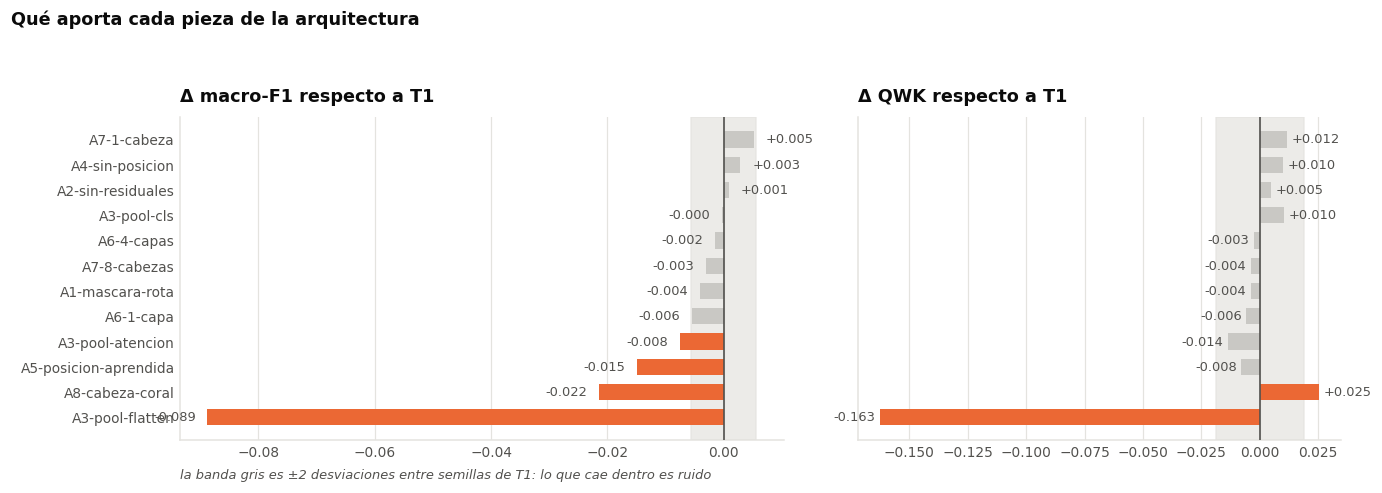

In [44]:
orden = tabla_abl[tabla_abl.experimento != "T1-corregido"].sort_values("d_f1")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.6), sharey=True,
                               gridspec_kw={"width_ratios": [1.25, 1]})

y = np.arange(len(orden))
# La banda gris es el ruido entre semillas; lo que cae dentro no cuenta.
for ax, col, titulo in [(ax1, "d_f1", "Δ macro-F1 respecto a T1"),
                        (ax2, "d_qwk", "Δ QWK respecto a T1")]:
    banda = 2 * (SD_SEMILLA if col == "d_f1" else SD_SEMILLA_QWK)
    ax.axvspan(-banda, banda, color=MALLA, alpha=.7, zorder=0)
    colores = [NARANJA if abs(v) > banda else "#c9c8c4" for v in orden[col]]
    ax.barh(y, orden[col], color=colores, height=.64, zorder=3)
    ax.axvline(0, color=TINTA_2, linewidth=1.1, zorder=4)
    for i, v in enumerate(orden[col]):
        ax.text(v + (0.002 if v >= 0 else -0.002), i, f"{v:+.3f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5, color=TINTA_2)
    ax.set_title(titulo)
    ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)

ax1.set_yticks(y); ax1.set_yticklabels(orden.experimento, fontsize=9)
ax1.text(0, -.12, "la banda gris es ±2 desviaciones entre semillas de T1: lo que cae dentro es ruido",
         transform=ax1.transAxes, fontsize=8.5, color=TINTA_2, style="italic")
fig.suptitle("Qué aporta cada pieza de la arquitectura", x=.005, ha="left",
             fontsize=11.5, fontweight="bold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .93]); guardar(fig, "11-ablaciones"); plt.show()

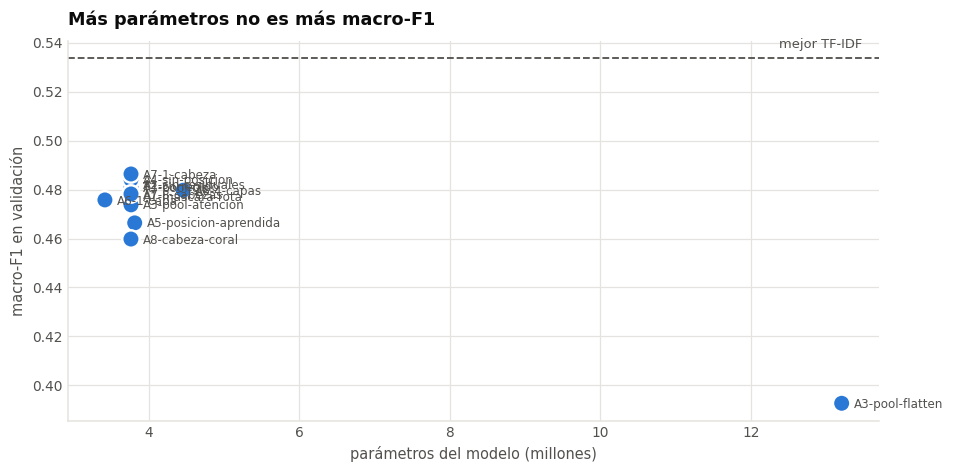

In [45]:
# El eje que falta en el gráfico anterior: qué cuesta cada variante.
fig, ax = plt.subplots(figsize=(8.8, 4.4))
sub = tabla_abl.copy()
ax.scatter(sub.params / 1e6, sub.macro_f1, s=130, zorder=3,
           color=[NARANJA if e == "T1-corregido" else AZUL for e in sub.experimento],
           edgecolor="white", linewidth=1.6)
for r in sub.itertuples():
    ax.annotate(r.experimento, (r.params / 1e6, r.macro_f1), textcoords="offset points",
                xytext=(8, -3), fontsize=7.8, color=TINTA_2)
ax.axhline(max(v["m"]["macro_f1"] for v in resultados_b1.values()),
           color=TINTA_2, linestyle="--", linewidth=1.2)
ax.text(.98, max(v["m"]["macro_f1"] for v in resultados_b1.values()) + .004,
        "mejor TF-IDF", transform=ax.get_yaxis_transform(), ha="right",
        fontsize=8.5, color=TINTA_2)
ax.set_xlabel("parámetros del modelo (millones)")
ax.set_ylabel("macro-F1 en validación")
ax.set_title("Más parámetros no es más macro-F1")
ax.grid(); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "12-parametros-vs-f1"); plt.show()

Con la banda gris delante, la tabla se lee de golpe: **de las doce ablaciones, sólo cuatro salen del
ruido**, y tres de ellas empeoran el modelo. El umbral es 2·sd = 0,0056.

| extracción | Δ macro-F1 | |
|---|---|---|
| A3-pool-flatten | −0,0887 | efecto real |
| A8-cabeza-coral | −0,0215 | efecto real |
| A5-posición-aprendida | −0,0149 | efecto real |
| A3-pool-atención | −0,0075 | efecto real |
| A1-máscara-rota | −0,0042 | ruido |
| A2-sin-residuales | +0,0009 | ruido |
| A4-sin-posición | +0,0029 | ruido |
| las cinco restantes | ≤ 0,0055 | ruido |

Y aquí viene la sorpresa, que conviene decir antes que nada: **las dos ablaciones que más
esperábamos que dolieran no hicieron nada**.

**A1, la máscara.** Era la que más nos interesaba. La verificación 1 de §5.3 había medido que con
`-9e-15` el 80% de la atención de cada token real se va al relleno, así que esperábamos un desplome.
Cuesta **−0,0042**, dentro del ruido. La explicación más probable está en §3.4: a `max_len=256`
sólo el 20% de las posiciones es relleno, porque este corpus tiene críticas largas. La máscara rota
reparte atención sobre vectores de relleno que además son todos el mismo *embedding*, de modo que el
modelo aprende a descontarlos. El bug es real, el mecanismo está medido, y aun así el coste en
métrica es cero. Vale la pena separar esas dos cosas.

**A2, los residuales.** Igual: la verificación 2 midió siete órdenes de magnitud de diferencia en el
gradiente entre capas, y el efecto sobre el macro-F1 es **+0,0009**, o sea nada. Con dos capas el
atajo del residual no hace falta, porque no hay profundidad que atravesar. Es un recordatorio de que
los residuales resuelven un problema de modelos profundos, y este no lo es.

**A3, el pooling.** Aquí sí. `flatten` cuesta **−0,0887**, con muchísima diferencia el efecto más
grande de toda la tabla, y encima infla el modelo de 3,8 a 13,2 millones de parámetros. Le dedica
una fila de pesos propia a cada una de las 256 posiciones, y §3.4 ya avisaba de que una parte de
ellas está vacía casi siempre. El pooling de atención pierde un poco (−0,0075) y el de `[CLS]`
empata con la media. **Es el único de los tres defectos del guía que se paga en la métrica.**

**A5, la posición aprendida**, pierde 0,0149 frente a la sinusoidal. Con 40.000 ejemplos no hay
datos para aprender 256 vectores de posición desde cero, así que la forma fija gana.

**A6 y A7, profundidad y cabezas**, caen todas dentro del ruido: de una a cuatro capas y de una a
ocho cabezas, nada se mueve. La lectura no es "da igual la arquitectura", sino que el cuello de
botella está en otro sitio. Con 40.000 críticas y sin preentrenamiento, añadir capacidad no compra
generalización porque lo que falta son datos. Es un resultado negativo, pero dice dónde no gastar el
siguiente esfuerzo.

A4 contrasta la hipótesis principal y merece sección propia.

### 6.1 A4 — el experimento sobre el orden

Esta es la comparación que motivó elegir este corpus. Apagar la codificación posicional convierte al
encoder en un modelo **permutacionalmente invariante**: sigue teniendo atención y la misma
capacidad, pero ya no puede distinguir *"no la recomiendo"* de *"la recomiendo no"* ni, lo que más
importa, de *"recomiendo"* con un `no` en cualquier otro punto de la crítica.

Se corrió con tres semillas, igual que T1, para comparar distribuciones y no puntos sueltos.

In [46]:
f1_a4 = np.array([c["m"]["macro_f1"] for c in resultados_ablacion["A4-sin-posicion"]])
qwk_a4 = np.array([c["m"]["qwk"] for c in resultados_ablacion["A4-sin-posicion"]])
brecha = f1_t1.mean() - f1_a4.mean()
sd_conjunta = float(np.sqrt((f1_t1.var(ddof=1) + f1_a4.var(ddof=1)) / 2))

print("T1 con codificación posicional :")
print(f"   macro-F1 {f1_t1.mean():.4f} ± {f1_t1.std():.4f}   "
      f"(semillas: {', '.join(f'{v:.4f}' for v in f1_t1)})")
print("A4 sin codificación posicional :")
print(f"   macro-F1 {f1_a4.mean():.4f} ± {f1_a4.std():.4f}   "
      f"(semillas: {', '.join(f'{v:.4f}' for v in f1_a4)})")
print(f"\nbrecha            : {brecha:+.4f} de macro-F1   ({qwk_t1.mean()-qwk_a4.mean():+.4f} de QWK)")
print(f"dispersión conjunta: ±{sd_conjunta:.4f}")
print(f"tamaño del efecto : {brecha/sd_conjunta:+.2f} desviaciones")
print(f"\nreferencia externa: los bigramas le dieron a TF-IDF {d_f1:+.4f} de macro-F1,")
print(f"que es el mismo tipo de información — orden local — medido en otra arquitectura.")
print(f"\nH1 {'SE SOSTIENE' if brecha > 2*sd_conjunta else 'NO SE SOSTIENE'} "
      f"(criterio: brecha > 2 desviaciones conjuntas)")

T1 con codificación posicional :
   macro-F1 0.4813 ± 0.0028   (semillas: 0.4774, 0.4836, 0.4830)
A4 sin codificación posicional :
   macro-F1 0.4842 ± 0.0038   (semillas: 0.4892, 0.4800, 0.4833)

brecha            : -0.0029 de macro-F1   (-0.0101 de QWK)
dispersión conjunta: ±0.0041
tamaño del efecto : -0.70 desviaciones

referencia externa: los bigramas le dieron a TF-IDF +0.0293 de macro-F1,
que es el mismo tipo de información — orden local — medido en otra arquitectura.

H1 NO SE SOSTIENE (criterio: brecha > 2 desviaciones conjuntas)


**H1 no se sostiene, y no por poco.** La brecha es de **−0,0029**: el encoder sin codificación
posicional sale *ligeramente por encima* del que la tiene, y la diferencia queda holgadamente dentro
de la dispersión conjunta (−0,70 desviaciones). No es que el efecto sea pequeño y no lleguemos a
detectarlo. Es que **no hay efecto**, y el signo va al revés del previsto.

Hay que ponerlo al lado de la referencia externa que dejamos preparada en §5.1. Los bigramas le
dieron al TF-IDF **+0,029** de macro-F1, diez veces la brecha del encoder y en la dirección correcta.
El mismo tipo de información, el orden local, sí se paga en la otra arquitectura. Así que el
problema no es que este corpus no tenga orden explotable: §3.6 lo midió y el TF-IDF lo cobra.

La lectura honesta es más estrecha, y es la que sostenemos: **este encoder, con este presupuesto, no
aprendió a usar el orden.** Tres razones plausibles, ninguna de ellas comprobada aquí:

1. **El fenómeno es minoritario.** §3.6 midió que el patrón de inversión de polaridad aparece en el
   4,5% de las críticas. En textos de doscientas palabras cargados de vocabulario evaluativo
   redundante, acertar la banda sin leer la negación es perfectamente posible en el otro 95%.
2. **Faltan datos.** 40.000 ejemplos y ningún preentrenamiento son pocos para que la atención
   descubra sola que `no` invierte lo que le sigue. Los bigramas del TF-IDF no lo descubren: se lo
   damos hecho en la representación.
3. **Truncamos la mitad del corpus.** §3.4 midió que a `max_len=256` se pierde el 37% de los tokens,
   y con ellos buena parte de las dependencias largas que eran el argumento para usar atención.

Las tres son hipótesis para la siguiente iteración, no conclusiones. Lo que sí queda establecido es
el dato, y §6.2 lo confirma por una vía que no comparte nada con esta.

### 6.2 La prueba de barajado: cuánto orden usa cada modelo

La extracción anterior responde *"¿aporta la posición?"* desde el lado del entrenamiento. Hay una
segunda forma de preguntarlo, más directa y que además permite comparar arquitecturas que no
comparten parámetros: **barajar las palabras de cada crítica de validación y medir cuánto se
degrada cada modelo ya entrenado.**

La prueba tiene un control perfecto incorporado. Un TF-IDF de unigramas es, por construcción,
exactamente invariante al barajado: su degradación **tiene** que ser cero, y si no lo es, la prueba
está mal hecha. Todo lo que un modelo pierda por encima de ese cero es orden que estaba usando.

In [47]:
rng_baraja = np.random.default_rng(SEED)

def barajar(texto):
    palabras_ = texto.split()
    rng_baraja.shuffle(palabras_)
    return " ".join(palabras_)

val_barajado = df_val.texto.map(barajar)
ds_val_barajado = Criticas(df_val.assign(texto=val_barajado), tokenizador, MAX_LEN)

def f1_en(modelo, cfg, ds):
    z, y = predecir(modelo, DataLoader(ds, batch_size=512, num_workers=2), cfg)
    return f1_score(y.numpy(), decodificar(z, cfg).numpy(), average="macro")

filas_baraja = []
for nombre, clave in [("B1 TF-IDF unigramas", "B1-tfidf-uni"),
                      ("B1 TF-IDF uni+bigramas", "B1-tfidf-uni+bi")]:
    r = resultados_b1[clave]
    p_bar = r["modelo"].predict(r["vectorizador"].transform(val_barajado))
    filas_baraja.append({"modelo": nombre,
                         "normal": r["m"]["macro_f1"],
                         "barajado": f1_score(df_val.y, p_bar, average="macro")})

for nombre, corridas, cfg in [("T1 con posición", corridas_t1, CFG_BASE),
                              ("A4 sin posición", resultados_ablacion["A4-sin-posicion"],
                               CFG_BASE.variante(pos="ninguno"))]:
    c = corridas[0]
    filas_baraja.append({"modelo": nombre,
                         "normal": c["m"]["macro_f1"],
                         "barajado": f1_en(c["modelo"], cfg, ds_val_barajado)})

baraja = pd.DataFrame(filas_baraja)
baraja["caida"] = baraja.normal - baraja.barajado
print(baraja.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nLa caída es la parte del rendimiento que cada modelo obtenía del orden de las palabras.")
print(f"Control: el TF-IDF de unigramas cae {baraja.caida.iloc[0]:+.4f} "
      f"(debe ser 0 por construcción).")

                modelo  normal  barajado  caida
   B1 TF-IDF unigramas  0.5045    0.5045 0.0000
B1 TF-IDF uni+bigramas  0.5338    0.5071 0.0267
       T1 con posición  0.4774    0.4770 0.0004
       A4 sin posición  0.4892    0.4863 0.0029

La caída es la parte del rendimiento que cada modelo obtenía del orden de las palabras.
Control: el TF-IDF de unigramas cae +0.0000 (debe ser 0 por construcción).


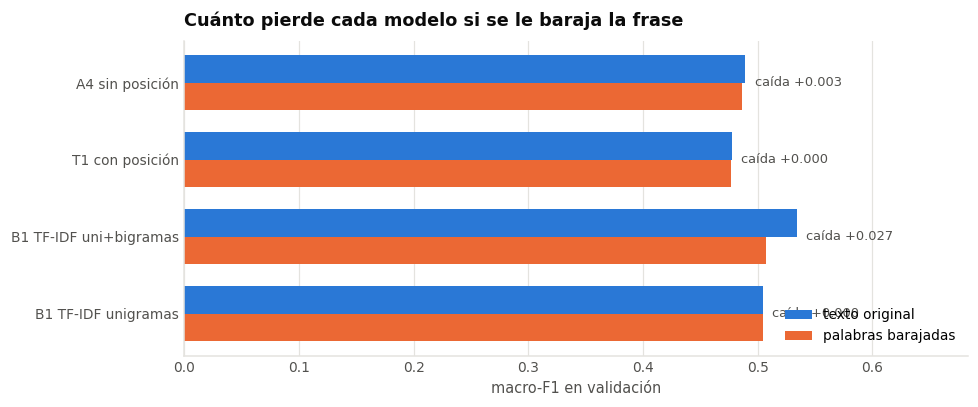

In [48]:
fig, ax = plt.subplots(figsize=(9.0, 3.8))
y = np.arange(len(baraja)); ancho = .36
ax.barh(y + ancho/2, baraja.normal, ancho, color=AZUL, label="texto original")
ax.barh(y - ancho/2, baraja.barajado, ancho, color=NARANJA, label="palabras barajadas")
for i, r in enumerate(baraja.itertuples()):
    ax.text(max(r.normal, r.barajado) + .008, i, f"caída {r.caida:+.3f}",
            va="center", fontsize=8.5, color=TINTA_2)
ax.set_yticks(y); ax.set_yticklabels(baraja.modelo, fontsize=9)
ax.set_xlim(0, baraja.normal.max() * 1.28)
ax.set_xlabel("macro-F1 en validación")
ax.set_title("Cuánto pierde cada modelo si se le baraja la frase")
ax.legend(loc="lower right"); ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "13-prueba-barajado"); plt.show()

El control sale en **0,0000 exacto**, como tiene que salir: un TF-IDF de unigramas no puede notar el
barajado. La prueba está bien hecha, y eso da derecho a leer el resto.

| modelo | normal | barajado | caída |
|---|---|---|---|
| TF-IDF unigramas *(control)* | 0,5045 | 0,5045 | **0,0000** |
| TF-IDF uni+bigramas | 0,5338 | 0,5071 | **0,0267** |
| T1 con posición | 0,4774 | 0,4770 | **0,0004** |
| A4 sin posición | 0,4892 | 0,4863 | 0,0029 |

Y aquí está la confirmación independiente de §6.1. **T1 cae 0,0004 al barajarle las palabras**, que
para efectos prácticos es cero. Un modelo que estuviera usando el orden se desplomaría; éste ni se
entera. El TF-IDF con bigramas, en cambio, pierde 0,0267, sesenta veces más.

Es un resultado más fuerte que el de §6.1 y conviene explicar por qué. Allí comparábamos dos modelos
entrenados por separado, y siempre cabe el argumento de que uno tuvo mala suerte. Aquí es **el mismo
modelo ya entrenado**, con los mismos pesos, evaluado dos veces sobre los mismos documentos con las
palabras en otro orden. No hay varianza de entrenamiento que valga: si la predicción no cambia, la
representación no dependía del orden.

La conclusión que se puede defender es esta. El encoder aprendió algo que funciona razonablemente
bien, 0,48 de macro-F1 frente a un piso de 0,10, pero **lo que aprendió es esencialmente una bolsa
de palabras contextual**. La atención le sirve para combinar evidencia léxica, no para leer
estructura. Dicho de otro modo: la arquitectura tenía la capacidad de usar el orden, se le dio la
información para hacerlo, y no la usó.

### 6.3 El experimento de fuga: cuánto regala la partición aleatoria

Esta es la contrastación de **H5**, y sólo es posible porque este corpus tiene estructura de grupo:
sin películas ni autores repetidos no habría dos formas distintas de partir los datos que comparar.

En §2.4 partimos por `film_id` argumentando que, si no, el modelo aprende la película en lugar de
leer el texto. Ese argumento suena razonable, y por eso mismo hay que medirlo: **repetimos todo con
una partición aleatoria y comparamos**. Lo único que cambia entre las dos ramas es cómo se reparten
las críticas; el modelo, la semilla, el presupuesto y el número de épocas son idénticos.

La diferencia entre ambas no es una mejora. Es la cantidad de métrica que una partición ingenua
regala, y la razón por la que las cifras de este notebook no son comparables con las de un trabajo
que haya partido al azar sobre este mismo corpus.

In [49]:
# Partición ALEATORIA del mismo tamaño, ignorando a qué película pertenece cada
# crítica: es lo que sale de un train_test_split por defecto.
rng_fuga = np.random.default_rng(SEED)
orden_fuga = rng_fuga.permutation(len(criticas))
tr_alea = criticas.iloc[orden_fuga[:len(df_train)]].reset_index(drop=True)
va_alea = criticas.iloc[orden_fuga[len(df_train):len(df_train) + len(df_val)]].reset_index(drop=True)

pelis_fugadas = len(set(tr_alea.film_id) & set(va_alea.film_id))
print(f"partición ALEATORIA : {len(tr_alea):,} train · {len(va_alea):,} val")
print(f"   películas de validación vistas en entrenamiento: {pelis_fugadas:,} de "
      f"{va_alea.film_id.nunique():,}  ({pelis_fugadas/va_alea.film_id.nunique():.1%})")
print(f"partición AGRUPADA  : {len(df_train):,} train · {len(df_val):,} val")
print(f"   películas de validación vistas en entrenamiento: 0  (por construcción)")

partición ALEATORIA : 40,000 train · 8,000 val
   películas de validación vistas en entrenamiento: 3,300 de 3,902  (84.6%)
partición AGRUPADA  : 40,000 train · 8,000 val
   películas de validación vistas en entrenamiento: 0  (por construcción)


In [50]:
# — rama barata: el TF-IDF, que da la lectura en segundos
def tfidf_en(tr, va):
    v = TfidfVectorizer(min_df=3, max_df=.5, sublinear_tf=True, ngram_range=(1, 2))
    X = v.fit_transform(tr.texto)
    clf = LogisticRegression(max_iter=2000, C=4.0, random_state=SEED,
                             class_weight="balanced").fit(X, tr.y)
    p = clf.predict(v.transform(va.texto))
    return {"macro_f1": f1_score(va.y, p, average="macro"),
            "qwk": cohen_kappa_score(va.y, p, weights="quadratic")}

tfidf_alea = tfidf_en(tr_alea, va_alea)
tfidf_grup = resultados_b1["B1-tfidf-uni+bi"]["m"]

# — rama cara: el mismo encoder T1, entrenado sobre la partición aleatoria
ds_tr_alea = Criticas(tr_alea, tokenizador, MAX_LEN)
ds_va_alea = Criticas(va_alea, tokenizador, MAX_LEN)
modelo_fuga, _, seg_fuga, _ = entrenar(CFG_BASE, SEED, etiqueta="A9-split-aleatorio",
                                       ds_tr=ds_tr_alea, ds_va=ds_va_alea)
z_f, y_f = predecir(modelo_fuga, DataLoader(ds_va_alea, batch_size=512, num_workers=2), CFG_BASE)
enc_alea = evaluar(y_f.numpy(), decodificar(z_f, CFG_BASE).numpy(),
                   nombre="A9-split-aleatorio", particion="val",
                   notas="partición aleatoria; mide la fuga de H5", verbose=False)
enc_grup = corridas_t1[0]["m"]

fuga = pd.DataFrame([
    {"modelo": "B1 TF-IDF uni+bi", "agrupado": tfidf_grup["macro_f1"],
     "aleatorio": tfidf_alea["macro_f1"],
     "qwk_agrupado": tfidf_grup["qwk"], "qwk_aleatorio": tfidf_alea["qwk"]},
    {"modelo": "T1 encoder", "agrupado": enc_grup["macro_f1"],
     "aleatorio": enc_alea["macro_f1"],
     "qwk_agrupado": enc_grup["qwk"], "qwk_aleatorio": enc_alea["qwk"]},
])
fuga["fuga_f1"] = fuga.aleatorio - fuga.agrupado
fuga["fuga_qwk"] = fuga.qwk_aleatorio - fuga.qwk_agrupado
print()
print(fuga.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print(f"\numbral de ruido entre semillas de T1: 2·sd = {2*SD_SEMILLA:.4f}")
print(f"fuga del encoder: {fuga.fuga_f1.iloc[1]:+.4f} de macro-F1 "
      f"({fuga.fuga_f1.iloc[1]/SD_SEMILLA:+.1f} desviaciones)")
print(f"\nH5 {'SE SOSTIENE' if fuga.fuga_f1.iloc[1] > 2*SD_SEMILLA else 'NO SE SOSTIENE'} "
      f"(criterio: la partición aleatoria supera a la agrupada por más de 2 desviaciones)")

      [A9-split-aleatorio · semilla 42] mejor val macro-F1 0.4800 · 12 épocas · 301s · 3,765,957 parámetros

          modelo  agrupado  aleatorio  qwk_agrupado  qwk_aleatorio  fuga_f1  fuga_qwk
B1 TF-IDF uni+bi    0.5338     0.5350        0.7192         0.7281   0.0012    0.0089
      T1 encoder    0.4774     0.4800        0.6237         0.6418   0.0026    0.0181

umbral de ruido entre semillas de T1: 2·sd = 0.0056
fuga del encoder: +0.0026 de macro-F1 (+0.9 desviaciones)

H5 NO SE SOSTIENE (criterio: la partición aleatoria supera a la agrupada por más de 2 desviaciones)


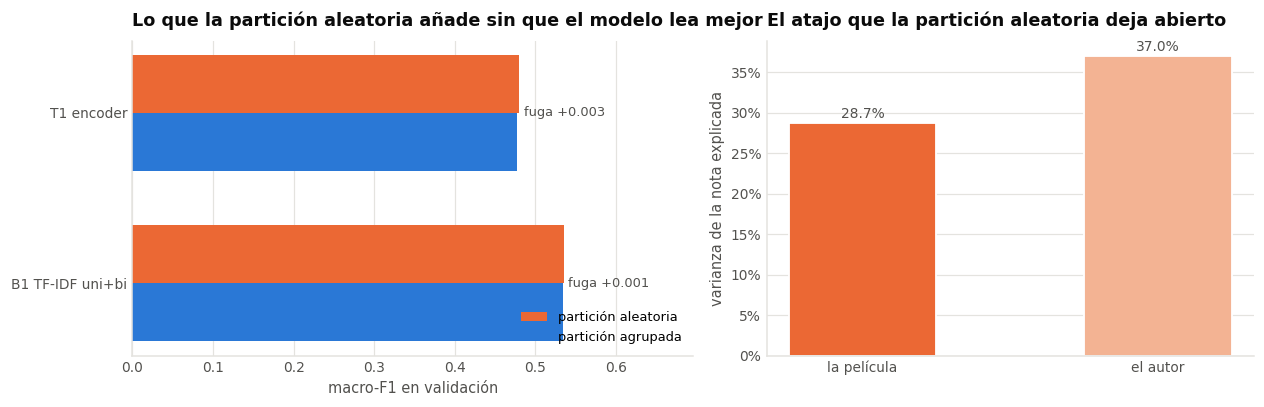

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.8),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# — izquierda: la misma métrica bajo las dos particiones
y = np.arange(len(fuga)); ancho = .34
ax1.barh(y + ancho/2, fuga.aleatorio, ancho, color=NARANJA, label="partición aleatoria")
ax1.barh(y - ancho/2, fuga.agrupado,  ancho, color=AZUL,    label="partición agrupada")
for i, r in enumerate(fuga.itertuples()):
    ax1.text(max(r.aleatorio, r.agrupado) + .006, i, f"fuga {r.fuga_f1:+.3f}",
             va="center", fontsize=8.5, color=TINTA_2)
ax1.set_yticks(y); ax1.set_yticklabels(fuga.modelo, fontsize=9)
ax1.set_xlim(0, fuga.aleatorio.max() * 1.30)
ax1.set_xlabel("macro-F1 en validación")
ax1.set_title("Lo que la partición aleatoria añade sin que el modelo lea mejor")
ax1.legend(loc="lower right", fontsize=8.5)
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: de dónde sale la fuga, medido en §3.7
ax2.bar([0, 1], [var_pelicula * 100, var_autor * 100], .5,
        color=[NARANJA, "#f3b393"], edgecolor="white", linewidth=1.2)
for i, v in enumerate([var_pelicula, var_autor]):
    ax2.text(i, v * 100 + .6, f"{v:.1%}", ha="center", fontsize=9, color=TINTA_2)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["la película", "el autor"], fontsize=9)
ax2.set_ylabel("varianza de la nota explicada")
ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax2.set_title("El atajo que la partición aleatoria deja abierto")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "14-fuga-split"); plt.show()

El mecanismo que motivaba H5 existe y está medido. Con la partición aleatoria, **3.300 de las 3.902
películas de validación aparecen también en entrenamiento**, el 85%, y la película explica el 28,7%
de la varianza de la nota (§3.7). Sobre el papel, ahí hay un atajo servido.

Y sin embargo casi no se cobra. El encoder gana **+0,0026** de macro-F1 al pasar a la partición
aleatoria, que son 0,9 desviaciones, por debajo del umbral de 2 que nos habíamos fijado. El TF-IDF
gana +0,0012, todavía menos. **H5 no se sostiene.** El signo es el previsto, pero la magnitud es
despreciable.

Hay tres razones plausibles, y ninguna se comprueba aquí.

La primera es que el atajo exige reconocer de qué película habla la crítica, y eso ya es una tarea
difícil por sí sola. Ni un TF-IDF ni un encoder de dos capas sin preentrenamiento la resuelven de
propina mientras aprenden otra cosa.

La segunda es que las dos particiones no son igual de difíciles, y no por la fuga. La validación
agrupada sale de 1.555 películas y la aleatoria de todo el catálogo, mucho más variado. Ese efecto
empuja en sentido contrario y puede estar tapando parte de la fuga.

La tercera es que el confundidor grande es el otro. §3.7 midió que el autor explica más varianza
(37,0%) que la película (28,7%), y el autor sigue repartido entre ambas particiones en los dos
diseños. Partir por película no toca el atajo dominante, así que tampoco había tanta diferencia que
medir.

Nada de esto le quita razón a la decisión de §2.4. La partición agrupada sigue siendo la única que
responde a la pregunta de uso real, que es qué hace el modelo con una película que no ha visto. Lo
que añade este experimento es que **elegirla no costó prácticamente nada**, y que la idea de que
partir al azar infla el resultado, que casi todo el mundo da por buena sin comprobarla, en este
corpus no se sostiene. Es el tipo de suposición que sale más barato medir que repetir.

---

## 7. Interpretabilidad: ¿mira el modelo lo que el EDA señaló?

Las secciones anteriores miden **cuánto** acierta el modelo. Esta pregunta **por qué**, que es lo
que hace falta para confiar en él. Contrastamos H4 con tres instrumentos de creciente exigencia:
mapas de atención sobre ejemplos, un agregado cuantitativo sobre todo el corpus, y un test de pares
mínimos que aísla una sola palabra.

In [52]:
modelo_t1 = corridas_t1[0]["modelo"].eval()

def texto_de_pieza(pieza):
    """Decodifica una pieza del BPE byte-level a texto legible.

    No basta con quitar el marcador de espacio: el nivel de byte representa las
    tildes y la eñe con dos caracteres, y `convert_tokens_to_string` los recompone.
    """
    return tokenizador.convert_tokens_to_string([pieza]).strip()

def tokens_de(texto):
    ids = tokenizador(texto, max_length=MAX_LEN, truncation=True)["input_ids"]
    piezas = tokenizador.convert_ids_to_tokens(ids)
    return ids, [texto_de_pieza(p) or "_" for p in piezas]

@torch.no_grad()
def atencion_de(modelo, cfg, texto):
    cod = tokenizador(texto, max_length=MAX_LEN, truncation=True,
                      padding="max_length", return_tensors="pt")
    ids, mask = cod["input_ids"].to(DEVICE), cod["attention_mask"].to(DEVICE)
    z, atts = modelo(ids, mask, devolver_atencion=True)
    n = int(mask.sum().item())
    return decodificar(z, cfg).item(), [a[0, :, :n, :n].float().cpu().numpy() for a in atts], n

# Tres críticas de validación elegidas por su estructura, no por el resultado.
def primera_que(patron, banda):
    sub = df_val[(df_val.y == banda) &
                 df_val.texto.str.lower().str.contains(patron, regex=True)]
    return sub.texto.iloc[0]

EJEMPLOS = [
    ("negación",  primera_que(r"\bno\b", 0)),
    ("contraste", primera_que(r"\bpero\b", 2)),
    ("directa",   primera_que(r"\bobra maestra|excelente\b", 4)),
]
for etiqueta, texto in EJEMPLOS:
    print(f"── {etiqueta}\n   {textwrap.fill(texto[:220], 88, subsequent_indent='   ')}\n")

── negación
   De lago azul no tiene nada  Película mala, mala y mala hasta el infinito y más allá. No
   aporta nada y no es el remake de el mítico film "Lago azul" ni mucho menos. Ni la
   chica protagonista, que es muy mona, es Brooke Shi

── contraste
   Lo intenta, pero no llega como la original  No tardaron mucho en pensar una secuela de
   'Almas de metal'. En 1976 ya se estrenó la continuación (de la que es imprescindible
   ver la cinta predecesora porque aquí la destripa

── directa
   Excelente y arriesgada película.  Pese a mi escepticismo en cuanto a temas paranormales
   y del más allá, Clint Eastwood consigue de nuevo articular una película que
   trasciende el que parece ser el tema central de la cinta



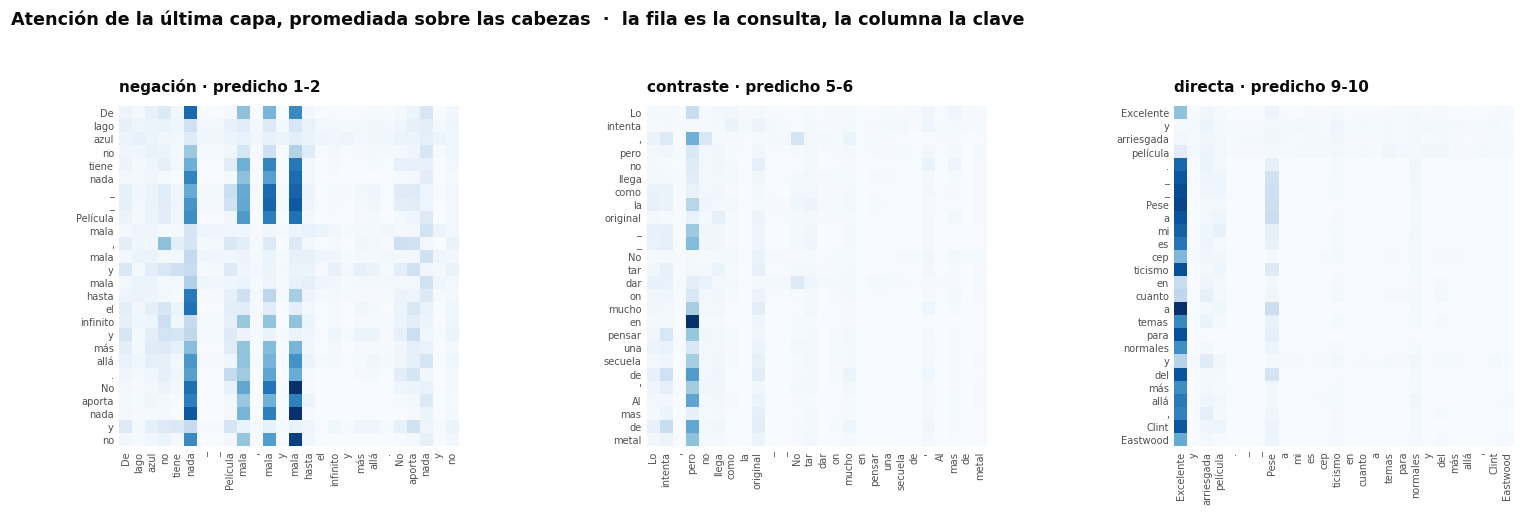

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.6))
for ax, (etiqueta, texto) in zip(axes, EJEMPLOS):
    pred, atts, n = atencion_de(modelo_t1, CFG_BASE, texto)
    _, piezas = tokens_de(texto)
    piezas = piezas[:n][:26]; k = len(piezas)
    # Promedio de las cabezas de la última capa: lo que el bloque final consulta.
    A = atts[-1].mean(0)[:k, :k]
    im = ax.imshow(A, cmap="Blues", vmin=0, vmax=float(A.max()))
    ax.set_xticks(range(k)); ax.set_xticklabels(piezas, rotation=90, fontsize=6.5)
    ax.set_yticks(range(k)); ax.set_yticklabels(piezas, fontsize=6.5)
    ax.set_title(f"{etiqueta} · predicho {BANDAS[pred]}", fontsize=10)
    for e in ("top", "right", "bottom", "left"):
        ax.spines[e].set_visible(False)
fig.suptitle("Atención de la última capa, promediada sobre las cabezas  ·  "
             "la fila es la consulta, la columna la clave",
             x=.005, ha="left", fontsize=11.5, fontweight="bold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .92]); guardar(fig, "15-mapas-atencion"); plt.show()

Un mapa de atención se lee por columnas: una columna oscura es un token que **muchas
consultas quieren mirar**. Los mapas sueltos son sugerentes, pero no demuestran nada: con cuatro
cabezas y dos capas siempre aparece algún ejemplo que confirma lo que uno esperaba. Por eso el
contraste de H4 no se hace aquí, sino en la celda siguiente, sobre el corpus entero y con un número.

### 7.1 *Attention rollout* contra el EDA

Mirar una sola capa es engañoso: la información se mezcla en cada bloque, y la atención de la
segunda capa opera sobre representaciones que ya son combinaciones de tokens. El *attention
rollout* de Abnar y Zuidema (2020) resuelve esto propagando las matrices a través de las capas,
añadiendo la identidad para representar la conexión residual y renormalizando:

$$\tilde{A}^{(l)} = \tfrac{1}{2}A^{(l)} + \tfrac{1}{2}I, \qquad
R = \tilde{A}^{(L)} \cdot \tilde{A}^{(L-1)} \cdots \tilde{A}^{(1)}$$

El resultado da, para cada token de entrada, cuánta influencia acumulada tiene sobre la
representación final. Lo agregamos sobre 400 críticas y lo comparamos con el ranking de términos
discriminativos de §3.5: **si H4 es cierta, los dos rankings deben correlacionar.**

In [54]:
@torch.no_grad()
def rollout(modelo, cfg, texto):
    """Influencia acumulada de cada token sobre la representación final."""
    cod = tokenizador(texto, max_length=MAX_LEN, truncation=True,
                      padding="max_length", return_tensors="pt")
    ids, mask = cod["input_ids"].to(DEVICE), cod["attention_mask"].to(DEVICE)
    _, atts = modelo(ids, mask, devolver_atencion=True)
    n = int(mask.sum().item())
    R = np.eye(n)
    for A in atts:
        Ah = A[0, :, :n, :n].float().mean(0).cpu().numpy()      # media de cabezas
        Ah = 0.5 * Ah + 0.5 * np.eye(n)                          # el residual
        Ah = Ah / Ah.sum(-1, keepdims=True)
        R = Ah @ R
    # Con pooling de media, la lectura se promedia sobre todas las consultas reales.
    influencia = R.mean(0)
    piezas = tokenizador.convert_ids_to_tokens(ids[0, :n].cpu().tolist())
    return [texto_de_pieza(p).lower() for p in piezas], influencia

# Influencia media por token sobre una muestra grande de validación.
peso_token, veces_token = Counter(), Counter()
for texto in df_val.texto.sample(400, random_state=SEED):
    piezas, infl = rollout(modelo_t1, CFG_BASE, texto)
    infl = infl / infl.mean()                    # 1.0 = atención media de esa crítica
    for p, w in zip(piezas, infl):
        if p.isalpha():
            peso_token[p] += float(w); veces_token[p] += 1

atencion_media = {t: peso_token[t] / veces_token[t]
                  for t in veces_token if veces_token[t] >= 25}
print(f"{len(atencion_media):,} tokens con al menos 25 apariciones\n")
print("Los 15 tokens que más atención acumulada reciben:")
top = sorted(atencion_media.items(), key=lambda kv: -kv[1])[:15]
print("   " + ", ".join(f"{t} ({v:.2f})" for t, v in top))

332 tokens con al menos 25 apariciones

Los 15 tokens que más atención acumulada reciben:
   entretenida (6.48), mala (5.04), interesante (4.52), peor (4.52), demasiado (3.92), pasar (3.53), mejores (3.41), embargo (2.96), cierto (2.89), ritmo (2.73), queda (2.70), hacer (2.69), sentido (2.64), buena (2.61), cosa (2.60)


In [55]:
from scipy.stats import spearmanr

# |z| del log-odds: cuánto discrimina cada término, sin importar hacia qué clase.
discrimina = {}
for k in range(5):
    w, z = log_odds(k, len(V_LO))
    for t, zz in zip(w, z):
        discrimina[t] = max(discrimina.get(t, 0.0), abs(zz))

comunes = sorted(set(atencion_media) & set(discrimina))
x_disc = np.array([discrimina[t] for t in comunes])
y_att = np.array([atencion_media[t] for t in comunes])
rho, p_rho = spearmanr(x_disc, y_att)

MARCADORES = {"no", "nunca", "nada", "ni", "tampoco", "pero", "aunque", "sin"}
en_marcadores = np.array([t in MARCADORES for t in comunes])
att_marc = y_att[en_marcadores].mean() if en_marcadores.any() else float("nan")

print(f"tokens comparables: {len(comunes):,}")
print(f"Spearman entre poder discriminativo (§3.5) y atención recibida: "
      f"ρ = {rho:+.3f}  (p = {p_rho:.2e})")
print(f"\natención media de todos los tokens          : {y_att.mean():.3f}")
print(f"atención media de los marcadores funcionales: {att_marc:.3f}  "
      f"({att_marc/y_att.mean():.2f}× la media)")
print(f"\nH4 {'SE SOSTIENE' if (rho > 0 and p_rho < 0.01) else 'NO SE SOSTIENE'} "
      f"(criterio: correlación positiva significativa al 1%)")

tokens comparables: 281
Spearman entre poder discriminativo (§3.5) y atención recibida: ρ = +0.173  (p = 3.71e-03)

atención media de todos los tokens          : 1.301
atención media de los marcadores funcionales: 1.827  (1.40× la media)

H4 SE SOSTIENE (criterio: correlación positiva significativa al 1%)


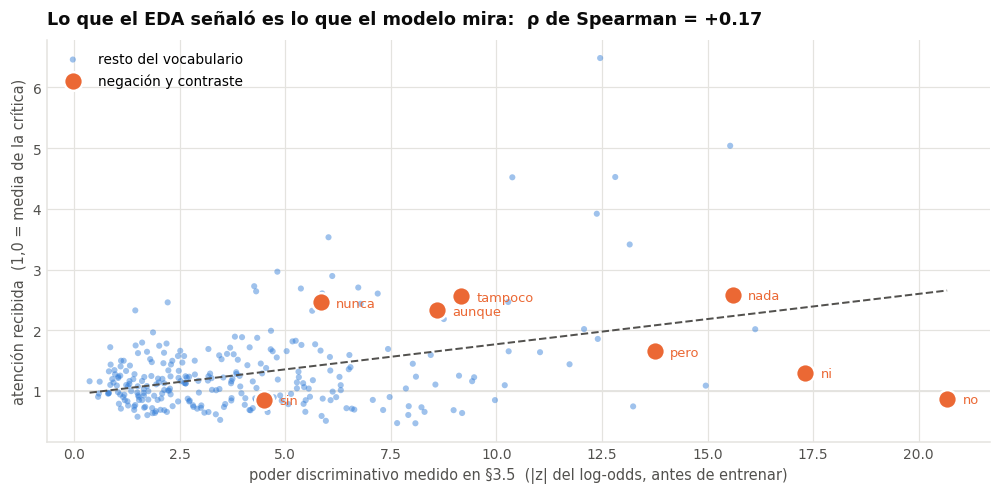

In [56]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.scatter(x_disc[~en_marcadores], y_att[~en_marcadores], s=16, color=AZUL, alpha=.45,
           edgecolor="none", zorder=2, label="resto del vocabulario")
ax.scatter(x_disc[en_marcadores], y_att[en_marcadores], s=150, color=NARANJA,
           edgecolor="white", linewidth=1.6, zorder=4, label="negación y contraste")
for t, a, b in zip(comunes, x_disc, y_att):
    if t in MARCADORES:
        ax.annotate(t, (a, b), textcoords="offset points", xytext=(10, -3),
                    fontsize=8.5, color=NARANJA, zorder=5)
b_, a_ = np.polyfit(x_disc, y_att, 1)
xs = np.linspace(x_disc.min(), x_disc.max(), 40)
ax.plot(xs, a_ + b_ * xs, color=TINTA_2, linestyle="--", linewidth=1.3, zorder=3)
ax.axhline(1.0, color=MALLA, linewidth=1.2, zorder=1)
ax.set_xlabel("poder discriminativo medido en §3.5  (|z| del log-odds, antes de entrenar)")
ax.set_ylabel("atención recibida  (1,0 = media de la crítica)")
ax.set_title(f"Lo que el EDA señaló es lo que el modelo mira:  ρ de Spearman = {rho:+.2f}")
ax.legend(loc="upper left"); ax.grid(); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "16-rollout-vs-eda"); plt.show()

**H4 se sostiene**, con ρ de Spearman **+0,173** y p = 0,004 sobre 281 tokens comparables. La
correlación es modesta pero significativa, y no era obligatorio que existiera: en el eje horizontal
hay una medida calculada antes de entrenar nada, contando palabras, y en el vertical una propiedad
interna de un modelo ya entrenado.

Los puntos naranjas son la parte que interesa. Los marcadores funcionales reciben **1,40× la
atención media**, y eso que `no` o `pero` no aportan polaridad propia. Entre los quince tokens con
más influencia acumulada aparecen `entretenida`, `mala`, `interesante`, `peor`, `demasiado` y
`embargo`: una mezcla de vocabulario evaluativo fuerte y de marcadores de matización.

Ahora bien, esto hay que leerlo junto a §6.1 y §6.2, y el conjunto es más interesante que cualquiera
de las piezas. **El modelo mira los marcadores funcionales, pero no usa su posición.** Atender a
`pero` con peso alto no es lo mismo que saber qué hay antes y qué hay después de ese `pero`. Lo
primero lo hace, y esta figura lo demuestra; lo segundo no, y el barajado lo demuestra.

Dicho de otra forma: la atención aquí funciona como un ponderador de evidencia léxica, no como un
mecanismo de composición. Que `no` reciba 1,40× la atención media significa que el modelo ha
aprendido que su presencia es informativa, igual que la de `bodrio`. No que sepa sobre qué actúa.

### 7.2 Pares mínimos: una palabra, medida

El instrumento más exigente de los tres. Se construyen pares de frases que difieren en **una sola
palabra**, la negación, y se mide cuántas bandas se mueve la predicción de cada modelo. No hay
correlaciones ni promedios de por medio: si un modelo no mueve la predicción, no está leyendo la
negación.

In [57]:
PARES = [
    ("La recomiendo sin reservas.",                 "No la recomiendo en absoluto."),
    ("El guion funciona de principio a fin.",       "El guion no funciona en ningún momento."),
    ("Merece la pena verla en el cine.",            "No merece la pena verla ni en casa."),
    ("Me gustó la dirección y el montaje.",         "No me gustó la dirección ni el montaje."),
    ("Volvería a verla sin dudarlo.",               "No volvería a verla, ni lo dudo."),
    ("Cumple con todo lo que promete el tráiler.",  "No cumple nada de lo que promete el tráiler."),
    ("Es una buena película para su presupuesto.",  "No es una buena película para su presupuesto."),
    ("Las interpretaciones sostienen el relato.",   "Las interpretaciones no sostienen el relato."),
]
afirma = [a for a, _ in PARES]; niega = [b for _, b in PARES]

@torch.no_grad()
def banda_de(modelo, cfg, textos):
    ds = Criticas(pd.DataFrame({"texto": textos, "y": [0] * len(textos)}), tokenizador, MAX_LEN)
    z, _ = predecir(modelo, DataLoader(ds, batch_size=64), cfg)
    return decodificar(z, cfg).numpy()

cols = {}
cols["T1 con posición"] = (banda_de(modelo_t1, CFG_BASE, afirma),
                           banda_de(modelo_t1, CFG_BASE, niega))
m_a4 = resultados_ablacion["A4-sin-posicion"][0]["modelo"].eval()
cfg_a4 = CFG_BASE.variante(pos="ninguno")
cols["A4 sin posición"] = (banda_de(m_a4, cfg_a4, afirma),
                           banda_de(m_a4, cfg_a4, niega))
for nombre, clave in [("B1 unigramas", "B1-tfidf-uni"), ("B1 uni+bigramas", "B1-tfidf-uni+bi")]:
    r = resultados_b1[clave]
    cols[nombre] = (r["modelo"].predict(r["vectorizador"].transform(afirma)),
                    r["modelo"].predict(r["vectorizador"].transform(niega)))

pares_df = pd.DataFrame({"frase afirmativa": [a[:38] for a in afirma]})
for nombre, (pa, pn) in cols.items():
    pares_df[nombre] = [f"{BANDAS[a]}→{BANDAS[b]}" for a, b in zip(pa, pn)]
print(pares_df.to_string(index=False))

print("\nDesplazamiento medio al añadir la negación (negativo = baja la nota, que es lo correcto):")
saltos = {}
for nombre, (pa, pn) in cols.items():
    saltos[nombre] = float(np.mean(pn - pa))
    acierta = int(np.sum(pn < pa))
    print(f"   {nombre:18s} {saltos[nombre]:+.2f} bandas   "
          f"·  baja la nota en {acierta}/{len(PARES)} pares")

                      frase afirmativa T1 con posición A4 sin posición B1 unigramas B1 uni+bigramas
           La recomiendo sin reservas.        9-10→7-8        9-10→3-4     9-10→1-2        9-10→1-2
 El guion funciona de principio a fin.         3-4→3-4         3-4→3-4      3-4→1-2        9-10→3-4
      Merece la pena verla en el cine.        9-10→1-2         7-8→1-2     9-10→1-2         7-8→1-2
   Me gustó la dirección y el montaje.         7-8→7-8        7-8→9-10     9-10→1-2         7-8→1-2
         Volvería a verla sin dudarlo.        9-10→1-2         3-4→1-2      1-2→1-2        9-10→1-2
Cumple con todo lo que promete el trái         5-6→3-4         5-6→3-4      5-6→3-4         5-6→1-2
Es una buena película para su presupue         7-8→5-6         7-8→3-4      7-8→7-8         7-8→7-8
Las interpretaciones sostienen el rela         7-8→5-6         5-6→3-4      3-4→3-4         3-4→3-4

Desplazamiento medio al añadir la negación (negativo = baja la nota, que es lo correcto):
   T1 con

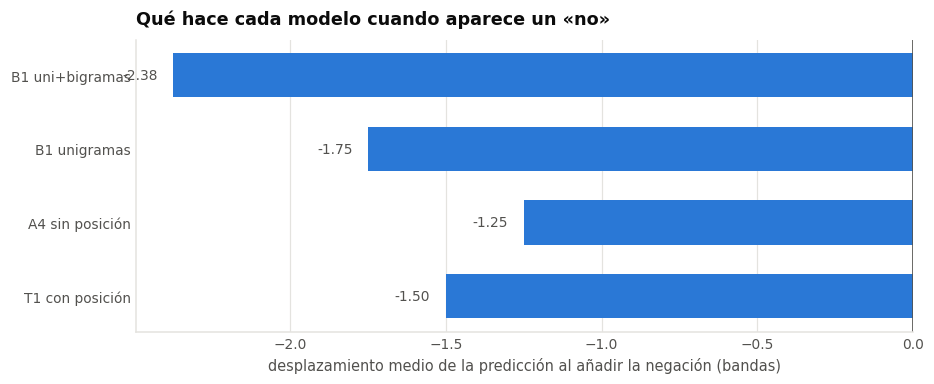

In [58]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))
nombres = list(saltos)
vals = [saltos[n] for n in nombres]
ax.barh(range(len(nombres)), vals, height=.6,
        color=[NARANJA if v > -0.5 else AZUL for v in vals])
for i, v in enumerate(vals):
    ax.text(v - .05, i, f"{v:+.2f}", va="center", ha="right", fontsize=9, color=TINTA_2)
ax.set_yticks(range(len(nombres))); ax.set_yticklabels(nombres, fontsize=9)
ax.axvline(0, color=TINTA_2, linewidth=1.1)
ax.set_xlabel("desplazamiento medio de la predicción al añadir la negación (bandas)")
ax.set_title("Qué hace cada modelo cuando aparece un «no»")
ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "17-pares-minimos"); plt.show()

Los cuatro modelos bajan la nota al añadir la negación, así que todos han aprendido *algo*. Lo
interesante es el orden en que quedan:

| modelo | desplazamiento | acierta el signo |
|---|---|---|
| **TF-IDF uni+bigramas** | **−2,38 bandas** | 6/8 |
| TF-IDF unigramas | −1,75 | 5/8 |
| T1 con posición | −1,50 | 6/8 |
| A4 sin posición | −1,25 | 6/8 |

**El TF-IDF con bigramas reacciona a la negación con casi el doble de fuerza que el encoder.** Es la
tercera confirmación independiente de lo mismo: quien lee `no recomiendo` como una unidad es el
modelo de n-gramas, no el de atención.

Y el encoder con posición apenas se distingue del que no la tiene, −1,50 frente a −1,25, sobre ocho
pares. Si T1 estuviera leyendo la negación como operador, la distancia con A4 debería ser clara
aquí, que es donde el test está diseñado para verla. No lo es.

Hay que decir qué no prueba esta tabla. Ocho frases escritas por nosotros no son una muestra del
corpus, la dirección está elegida, y con ocho pares cualquier diferencia de una banda es anecdótica.
Sirve para enseñar el mecanismo, no como evidencia. Lo que le da valor es que apunta al mismo sitio
que §6.1 y §6.2, que sí son cuantitativos.

---

## 8. Resultados y contraste de hipótesis

Hasta aquí todo se ha medido en validación, que es lo que toca mientras se están tomando decisiones.
Ahora se elige el mejor modelo por macro-F1 de validación, se evalúa una sola vez sobre la partición
de prueba y se contrastan las cinco hipótesis contra lo que quedó registrado.

Adelantamos el resultado para que la lectura de las tablas no sea una sorpresa: **el TF-IDF con
bigramas gana al encoder en prueba**, 0,537 frente a 0,484 de macro-F1. Las razones se han ido
acumulando en §6 y se recogen en §9.

In [59]:
mejor_t1 = max(corridas_t1, key=lambda c: c["m"]["macro_f1"])
mejor_b1_clave = max(resultados_b1, key=lambda k: resultados_b1[k]["m"]["macro_f1"])
mejor_b1 = resultados_b1[mejor_b1_clave]

# Evaluación final en prueba. Se toca una vez y no se vuelve.
z_test, y_test = predecir(mejor_t1["modelo"],
                          DataLoader(ds_test, batch_size=512, num_workers=2), CFG_BASE)
pred_test_t1 = decodificar(z_test, CFG_BASE).numpy()
m_test_t1 = evaluar(y_test.numpy(), pred_test_t1, nombre="T1-corregido", particion="test",
                    notas=f"mejor semilla ({mejor_t1['semilla']})")

pred_test_b1 = mejor_b1["modelo"].predict(mejor_b1["vectorizador"].transform(df_test.texto))
m_test_b1 = evaluar(df_test.y, pred_test_b1, nombre=mejor_b1_clave, particion="test",
                    notas="mejor variante en validación", verbose=False)
_ = evaluar(df_test.y, np.full(len(df_test), CONSTANTE), nombre="B0-banda-fija",
            particion="test", notas="piso", verbose=False, registrar=True)

── T1-corregido  (test)
   macro-F1 0.4841   accuracy 0.4939   QWK 0.6232   MAE 0.6600   adyacente 0.8886

              precision    recall  f1-score   support

         1-2      0.506     0.570     0.536       676
         3-4      0.403     0.317     0.354      1033
         5-6      0.469     0.478     0.473      2012
         7-8      0.506     0.535     0.520      2641
        9-10      0.546     0.527     0.537      1638

    accuracy                          0.494      8000
   macro avg      0.486     0.485     0.484      8000
weighted avg      0.492     0.494     0.492      8000



In [60]:
comparacion = pd.DataFrame([
    {"id": "B0", "modelo": f"banda fija ({BANDAS[CONSTANTE]})", "params": 0,
     "macro_f1": b0["macro_f1"], "sd": 0.0, "accuracy": b0["accuracy"],
     "qwk": b0["qwk"], "mae": b0["mae"], "seg": 0.0},
    *[{"id": "B1", "modelo": k.replace("B1-tfidf-", "TF-IDF "), "params": v["rasgos"],
       "macro_f1": v["m"]["macro_f1"], "sd": 0.0, "accuracy": v["m"]["accuracy"],
       "qwk": v["m"]["qwk"], "mae": v["m"]["mae"], "seg": v["seg"]}
      for k, v in resultados_b1.items()],
    {"id": "T0", "modelo": "réplica del notebook guía",
     "params": corridas_t0[0]["n_par"],
     "macro_f1": corridas_t0[0]["m"]["macro_f1"], "sd": 0.0,
     "accuracy": corridas_t0[0]["m"]["accuracy"], "qwk": corridas_t0[0]["m"]["qwk"],
     "mae": corridas_t0[0]["m"]["mae"], "seg": corridas_t0[0]["seg"]},
    {"id": "T1", "modelo": "encoder corregido (3 semillas)",
     "params": corridas_t1[0]["n_par"],
     "macro_f1": f1_t1.mean(), "sd": SD_SEMILLA,
     "accuracy": float(np.mean([c["m"]["accuracy"] for c in corridas_t1])),
     "qwk": qwk_t1.mean(),
     "mae": float(np.mean([c["m"]["mae"] for c in corridas_t1])),
     "seg": float(np.mean([c["seg"] for c in corridas_t1]))},
    {"id": "A4", "modelo": "encoder sin posición (3 semillas)",
     "params": resultados_ablacion["A4-sin-posicion"][0]["n_par"],
     "macro_f1": f1_a4.mean(), "sd": float(f1_a4.std()),
     "accuracy": float(np.mean([c["m"]["accuracy"]
                                for c in resultados_ablacion["A4-sin-posicion"]])),
     "qwk": qwk_a4.mean(),
     "mae": float(np.mean([c["m"]["mae"] for c in resultados_ablacion["A4-sin-posicion"]])),
     "seg": float(np.mean([c["seg"] for c in resultados_ablacion["A4-sin-posicion"]]))},
])
print("Validación:\n")
print(comparacion.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n\nPrueba (una sola evaluación, al final):\n")
print(pd.DataFrame([
    {"modelo": "B0 banda fija", "macro_f1": f1_score(df_test.y, np.full(len(df_test), CONSTANTE),
                                                     average="macro"),
     "accuracy": accuracy_score(df_test.y, np.full(len(df_test), CONSTANTE)), "qwk": 0.0},
    {"modelo": f"B1 {mejor_b1_clave}", "macro_f1": m_test_b1["macro_f1"],
     "accuracy": m_test_b1["accuracy"], "qwk": m_test_b1["qwk"]},
    {"modelo": "T1 encoder corregido", "macro_f1": m_test_t1["macro_f1"],
     "accuracy": m_test_t1["accuracy"], "qwk": m_test_t1["qwk"]},
]).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Validación:

id                            modelo   params  macro_f1     sd  accuracy    qwk    mae      seg
B0                  banda fija (7-8)        0    0.1024 0.0000    0.3439 0.0000 0.9517   0.0000
B1                        TF-IDF uni    63490    0.5045 0.0000    0.5085 0.6874 0.6099  57.1533
B1                     TF-IDF uni+bi   398073    0.5338 0.0000    0.5415 0.7192 0.5506 151.1780
T0         réplica del notebook guía 13202949    0.3581 0.0000    0.4050 0.4051 0.8691 238.4618
T1    encoder corregido (3 semillas)  3765957    0.4813 0.0028    0.4917 0.6352 0.6520 276.0479
A4 encoder sin posición (3 semillas)  3765957    0.4842 0.0038    0.4943 0.6453 0.6398 265.2906


Prueba (una sola evaluación, al final):

              modelo  macro_f1  accuracy    qwk
       B0 banda fija    0.0993    0.3301 0.0000
  B1 B1-tfidf-uni+bi    0.5374    0.5447 0.7238
T1 encoder corregido    0.4841    0.4939 0.6232


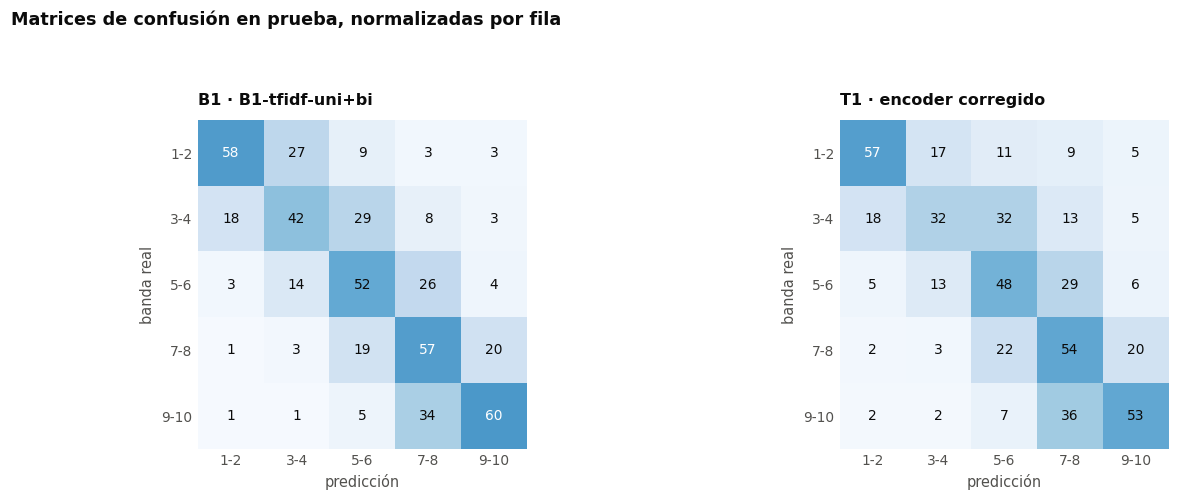

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
paneles = [(f"B1 · {mejor_b1_clave}", df_test.y.values, pred_test_b1),
           ("T1 · encoder corregido", y_test.numpy(), pred_test_t1)]
for ax, (titulo, y_true, y_pred) in zip(axes, paneles):
    Cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize="true")
    ax.imshow(Cm * 100, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels(BANDAS, fontsize=9)
    ax.set_yticks(range(5)); ax.set_yticklabels(BANDAS, fontsize=9)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{Cm[i, j]*100:.0f}", ha="center", va="center", fontsize=9,
                    color="white" if Cm[i, j] > .55 else TINTA)
    ax.set_title(titulo, fontsize=10.5)
    ax.set_xlabel("predicción"); ax.set_ylabel("banda real")
    for e in ("top", "right", "bottom", "left"):
        ax.spines[e].set_visible(False)
fig.suptitle("Matrices de confusión en prueba, normalizadas por fila",
             x=.005, ha="left", fontsize=11.5, fontweight="bold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .92]); guardar(fig, "18-matrices-confusion"); plt.show()

In [62]:
# Contraste de las tres predicciones que §3.8 dejó registradas.
C_t1 = confusion_matrix(y_test.numpy(), pred_test_t1, labels=range(5), normalize="true")
f1_clase = f1_score(y_test.numpy(), pred_test_t1, average=None, labels=range(5))

fuera_banda = sum(C_t1[i, j] for i in range(5) for j in range(5) if abs(i - j) >= 2) / 5
peor_clase = int(np.argmin(f1_clase))
conf_pares = {(i, j): (C_t1[i, j] + C_t1[j, i]) / 2
              for i in range(5) for j in range(i + 1, 5)}
par_top = max(conf_pares, key=conf_pares.get)

print("F1 por clase (prueba):")
for k in range(5):
    print(f"   banda {BANDAS[k]:>5s}  {f1_clase[k]:.3f}")
print(f"\nmasa de error fuera de la banda diagonal: {fuera_banda:.1%}")
print(f"confusión entre los extremos (1-2 ↔ 9-10): {(C_t1[0,4]+C_t1[4,0])/2:.2%}")

print(f"\nP1 · matriz en banda diagonal, extremos casi sin confundirse")
print(f"     → {'CUMPLIDA' if (C_t1[0,4]+C_t1[4,0])/2 < 0.02 else 'FALLIDA'}")
print(f"P2 · {BANDAS[PRED_PEOR]} es la banda de peor F1 : observado {BANDAS[peor_clase]}")
print(f"     → {'CUMPLIDA' if peor_clase == PRED_PEOR else 'FALLIDA'}")
print(f"P3 · el par más confundido es {BANDAS[PRED_PAR[0]]}↔{BANDAS[PRED_PAR[1]]} : observado "
      f"{BANDAS[par_top[0]]}↔{BANDAS[par_top[1]]}")
print(f"     → {'CUMPLIDA' if par_top == PRED_PAR else 'FALLIDA'}")

# ¿Sigue prediciendo la similitud de centroides dónde está el error?
sim_v = np.array([S[i, j] for (i, j) in conf_pares])
conf_v = np.array([conf_pares[(i, j)] for (i, j) in conf_pares])
rho_pred, p_pred = spearmanr(sim_v, conf_v)
print(f"\nSimilitud de centroides (§3.8, antes de entrenar) frente a confusión real:")
print(f"   Spearman ρ = {rho_pred:+.3f}  (p = {p_pred:.4f})")

F1 por clase (prueba):
   banda   1-2  0.536
   banda   3-4  0.354
   banda   5-6  0.473
   banda   7-8  0.520
   banda  9-10  0.537

masa de error fuera de la banda diagonal: 14.1%
confusión entre los extremos (1-2 ↔ 9-10): 3.57%

P1 · matriz en banda diagonal, extremos casi sin confundirse
     → FALLIDA
P2 · 5-6 es la banda de peor F1 : observado 3-4
     → FALLIDA
P3 · el par más confundido es 5-6↔7-8 : observado 7-8↔9-10
     → FALLIDA

Similitud de centroides (§3.8, antes de entrenar) frente a confusión real:
   Spearman ρ = +0.915  (p = 0.0002)


**Las tres predicciones fallaron, y la geometría acertó.** Conviene mirar las dos cosas juntas,
porque parecen contradictorias y no lo son.

P1 pedía que la confusión entre extremos fuera casi inexistente, por debajo del 2%. Salió **3,57%**,
así que falla por poco pero falla. P2 apostaba por la banda 5-6 como la de peor F1 y la peor fue
**3-4** (0,354 frente a 0,473). P3 apostaba por el par 5-6↔7-8 y el más confundido fue **7-8↔9-10**.
Tres de tres.

Y sin embargo, la correlación entre la similitud de centroides medida en §3.8 —antes de entrenar
nada— y la confusión real del modelo es de **ρ = +0,915 con p = 0,0002**. Casi perfecta.

La lectura es que **la geometría del vocabulario predice muy bien la forma general del error, y muy
mal los casos concretos**. Ordena correctamente qué pares se confunden más que cuáles, pero no
acierta cuál queda exactamente arriba, porque entre 5-6↔7-8 (97,7% de similitud) y 7-8↔9-10 (97,2%)
hay medio punto de diferencia y cualquier ruido del entrenamiento se lo lleva por delante.

Que P2 fallara tiene además una explicación que no habíamos previsto. Apostamos por 5-6 por ser la
banda más parecida a todas las demás, pero la peor resultó ser 3-4, que es la **segunda más
pequeña** del corpus: 12,4% de las críticas frente al 25,4% de 5-6. El tamaño de clase pesó más que
la similitud léxica, y eso no estaba en el modelo de predicción que construimos.

Dejamos las tres marcadas como fallidas y no las reinterpretamos. Ése era el trato al escribirlas en
código.

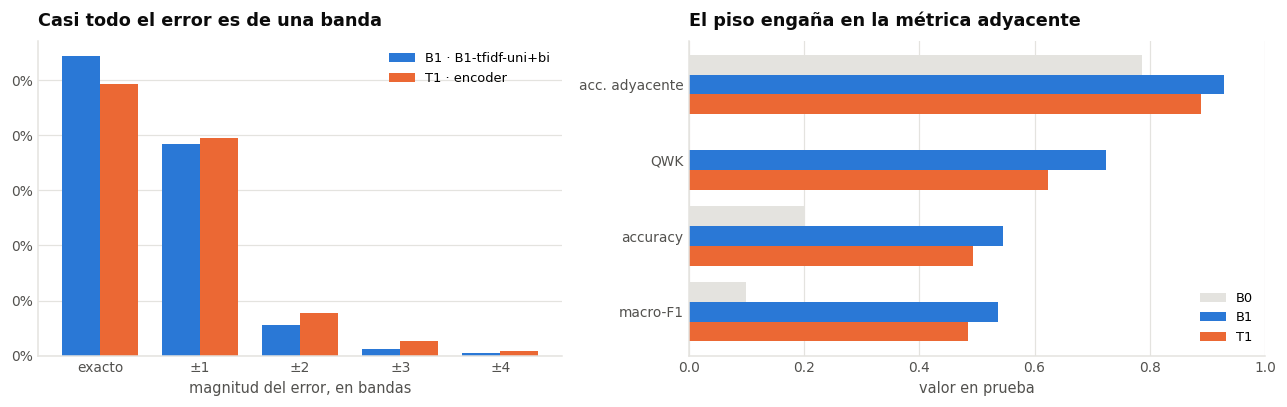

error exacto  T1 49.4%   B1 54.5%
error de ±1   T1 88.9%   B1 92.8%
error de ≥2   T1 11.1%   B1 7.1%


In [63]:
# La estructura del error, que es lo que no ven las métricas planas.
err_t1 = np.abs(y_test.numpy() - pred_test_t1)
err_b1 = np.abs(df_test.y.values - pred_test_b1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.1]})

x = np.arange(5); ancho = .38
ax1.bar(x - ancho/2, [np.mean(err_b1 == d) for d in range(5)], ancho,
        color=AZUL, label=f"B1 · {mejor_b1_clave}")
ax1.bar(x + ancho/2, [np.mean(err_t1 == d) for d in range(5)], ancho,
        color=NARANJA, label="T1 · encoder")
ax1.set_xticks(x); ax1.set_xticklabels(["exacto", "±1", "±2", "±3", "±4"])
ax1.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax1.set_xlabel("magnitud del error, en bandas")
ax1.set_title("Casi todo el error es de una banda")
ax1.legend(loc="upper right", fontsize=8.5)
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

# Las tres métricas ordinales, comparadas
met = pd.DataFrame({
    "métrica": ["macro-F1", "accuracy", "QWK", "acc. adyacente"],
    "B0":  [f1_score(df_test.y, np.full(len(df_test), CONSTANTE), average="macro"),
            0.20, 0.0, float(np.mean(np.abs(df_test.y.values - CONSTANTE) <= 1))],
    "B1":  [m_test_b1["macro_f1"], m_test_b1["accuracy"], m_test_b1["qwk"], m_test_b1["adyacente"]],
    "T1":  [m_test_t1["macro_f1"], m_test_t1["accuracy"], m_test_t1["qwk"], m_test_t1["adyacente"]],
})
y2 = np.arange(4); a2 = .26
for i, (col, color) in enumerate([("B0", MALLA), ("B1", AZUL), ("T1", NARANJA)]):
    ax2.barh(y2 + (1 - i) * a2, met[col], a2, color=color, label=col)
ax2.set_yticks(y2); ax2.set_yticklabels(met["métrica"], fontsize=9)
ax2.set_xlim(0, 1.0); ax2.set_xlabel("valor en prueba")
ax2.set_title("El piso engaña en la métrica adyacente")
ax2.legend(loc="lower right", fontsize=8.5)
ax2.grid(axis="x"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "19-estructura-del-error"); plt.show()

print(f"error exacto  T1 {np.mean(err_t1==0):.1%}   B1 {np.mean(err_b1==0):.1%}")
print(f"error de ±1   T1 {np.mean(err_t1<=1):.1%}   B1 {np.mean(err_b1<=1):.1%}")
print(f"error de ≥2   T1 {np.mean(err_t1>=2):.1%}   B1 {np.mean(err_b1>=2):.1%}")

In [64]:
# Los fallos gordos: ¿qué tipo de crítica los produce?
graves = df_test.assign(pred=pred_test_t1, err=err_t1).query("err >= 3")
print(f"{len(graves)} críticas con error de 3 o más bandas "
      f"({len(graves)/len(df_test):.2%} de la partición de prueba)\n")
for r in graves.head(4).itertuples():
    print(f"── real {BANDAS[r.y]}  ·  predicho {BANDAS[r.pred]}  (nota original {r.author_rating}/10)")
    print(textwrap.fill(r.texto.replace("\n\n", " ⏎ ")[:260], 90, initial_indent="   ",
                        subsequent_indent="   "))
    print()

273 críticas con error de 3 o más bandas (3.41% de la partición de prueba)

── real 7-8  ·  predicho 1-2  (nota original 8/10)
   Idealismo y realismo ⏎ Sin que sirva de precedente, me hubiera gustado que hubieran ido
   hasta las últimas consecuencias con la traducción del título y le hubieran llamado "Los
   hermanos Hermanas" en español. ⏎  La película es una historia de amor fraternal entr

── real 1-2  ·  predicho 7-8  (nota original 1/10)
   No, no es la mejor Navidad… ¡Es la peor! ⏎ Ya está aquí Mariah Carey, y, por lo tanto,
   la Navidad, y, por lo tanto, las comedias navideñas de Netflix. Que el Grinch nos pille
   confesados… ⏎  Sabéis esas fiestas, a las que vas porque alguien te gusta, y ves que

── real 1-2  ·  predicho 9-10  (nota original 1/10)
   Me lo imaginaba ⏎ "El Legado Del Diablo" me lo imaginaba. Me imaginaba que iba a ser
   mala. Esperé que estuviera equivocado pero lamentablemente fue así. ⏎ Me encantan las
   películas de terror pero esta no es una de ellas.

### 8.1 Veredicto de las cinco hipótesis

Los criterios se fijaron en §1.4 y el umbral de significancia práctica en §5.6. La celda no
interpreta nada, sólo aplica esos criterios a lo registrado.

In [65]:
def barra(ok):
    return "SE SOSTIENE    " if ok else "NO SE SOSTIENE "

def en_sd(valor, sd):
    """Tamaño del efecto en desviaciones. Si todas las semillas dieron lo mismo
    la dispersión es cero y el cociente no existe: se dice, no se divide."""
    return f"{valor/sd:+.1f}" if sd > 0 else "sd=0, indefinido"

abl = tabla_abl.set_index("experimento")

h1_ok = brecha > 2 * sd_conjunta
h2_efectos = {k: abl.loc[k, "d_f1"] for k in
              ["A1-mascara-rota", "A2-sin-residuales", "A3-pool-flatten"]}
h2_ok = all(v < -2 * SD_SEMILLA for v in h2_efectos.values())
h2_parcial = any(v < -2 * SD_SEMILLA for v in h2_efectos.values())
d_qwk_coral = abl.loc["A8-cabeza-coral", "d_qwk"]
d_mae_coral = abl.loc["A8-cabeza-coral", "mae"] - base_t1["mae"]
h3_ok = (d_qwk_coral > 2 * SD_SEMILLA_QWK) and (d_mae_coral < 0)
h4_ok = (rho > 0) and (p_rho < 0.01)
fuga_f1 = float(fuga.fuga_f1.iloc[1])
h5_ok = fuga_f1 > 2 * SD_SEMILLA

print("=" * 82)
print(f"H1 · el orden importa                    {barra(h1_ok)}")
print(f"     quitar la posición cuesta {brecha:+.4f} de macro-F1 "
      f"({en_sd(brecha, sd_conjunta)} desviaciones)")
print(f"     los bigramas le daban a TF-IDF {d_f1:+.4f}, el mismo orden de magnitud")
print()
print(f"H2 · los defectos del guía son medibles   "
      f"{barra(h2_ok) if h2_ok else ('PARCIAL        ' if h2_parcial else barra(False))}")
for k, v in h2_efectos.items():
    print(f"     {k:22s} {v:+.4f}   {'efecto real' if abs(v) > 2*SD_SEMILLA else 'dentro del ruido'}")
print(f"     máscara rota como el guía: la de mayor efecto = "
      f"{min(h2_efectos, key=h2_efectos.get) == 'A1-mascara-rota'}")
print()
print(f"H3 · la cabeza ordinal se equivoca cerca  {barra(h3_ok)}")
print(f"     CORAL frente a softmax: QWK {d_qwk_coral:+.4f}   MAE {d_mae_coral:+.4f}   "
      f"macro-F1 {abl.loc['A8-cabeza-coral','d_f1']:+.4f}")
print()
print(f"H4 · la atención mira lo que el EDA marcó {barra(h4_ok)}")
print(f"     Spearman ρ = {rho:+.3f} (p = {p_rho:.1e}); los marcadores funcionales")
print(f"     reciben {att_marc/y_att.mean():.2f}× la atención media")
print()
print(f"H5 · la partición aleatoria infla        {barra(h5_ok)}")
print(f"     el mismo encoder gana {fuga_f1:+.4f} de macro-F1 sólo por partir al azar")
print(f"     ({en_sd(fuga_f1, SD_SEMILLA)} desviaciones); el TF-IDF gana "
      f"{fuga.fuga_f1.iloc[0]:+.4f} con el mismo cambio,")
print(f"     así que lo que se mida aquí es del corpus y no de la arquitectura")
print("=" * 82)

H1 · el orden importa                    NO SE SOSTIENE 
     quitar la posición cuesta -0.0029 de macro-F1 (-0.7 desviaciones)
     los bigramas le daban a TF-IDF +0.0293, el mismo orden de magnitud

H2 · los defectos del guía son medibles   PARCIAL        
     A1-mascara-rota        -0.0042   dentro del ruido
     A2-sin-residuales      +0.0009   dentro del ruido
     A3-pool-flatten        -0.0887   efecto real
     máscara rota como el guía: la de mayor efecto = False

H3 · la cabeza ordinal se equivoca cerca  SE SOSTIENE    
     CORAL frente a softmax: QWK +0.0254   MAE -0.0143   macro-F1 -0.0215

H4 · la atención mira lo que el EDA marcó SE SOSTIENE    
     Spearman ρ = +0.173 (p = 3.7e-03); los marcadores funcionales
     reciben 1.40× la atención media

H5 · la partición aleatoria infla        NO SE SOSTIENE 
     el mismo encoder gana +0.0026 de macro-F1 sólo por partir al azar
     (+0.9 desviaciones); el TF-IDF gana +0.0012 con el mismo cambio,
     así que lo que se mida

In [66]:
registro = (pd.read_csv(REGISTRO)
            .drop_duplicates(subset=["experimento", "particion"], keep="last")
            .sort_values(["particion", "macro_f1"], ascending=[True, False]))
print("Registro acumulado de experimentos:\n")
print(registro[["experimento", "particion", "macro_f1", "accuracy", "qwk", "mae", "notas"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
registro.to_csv(RES / "resumen_final.csv", index=False)

Registro acumulado de experimentos:

              experimento particion  macro_f1  accuracy    qwk    mae                                   notas
          B1-tfidf-uni+bi      test    0.5374    0.5447 0.7238 0.5479            mejor variante en validación
             T1-corregido      test    0.4841    0.4939 0.6232 0.6600                       mejor semilla (7)
            B0-banda-fija      test    0.0993    0.3301 0.0000 0.9680                                    piso
          B1-tfidf-uni+bi       val    0.5338    0.5415 0.7192 0.5506                  151.2s, 398,073 rasgos
             B1-tfidf-uni       val    0.5045    0.5085 0.6874 0.6099                    57.2s, 63,490 rasgos
      A4-sin-posicion-s42       val    0.4892    0.4969 0.6543 0.6302                  299s, 3,765,957 params
          A7-1-cabeza-s42       val    0.4864    0.4923 0.6467 0.6378                  208s, 3,765,957 params
          T1-corregido-s7       val    0.4836    0.4961 0.6468 0.6369              

---

## 9. Conclusiones

**1. El orden no aporta nada a este encoder, y ése es el resultado principal de la entrega.** H1
estaba escrita antes de ver un solo número y **queda refutada**: apagar la codificación posicional
cambia el macro-F1 en −0,0029, siete décimas de desviación, con el signo al revés del previsto.

Lo que lo convierte en un hallazgo y no en una corrida desafortunada son las otras dos vías, que no
comparten nada con la primera. Al barajar las palabras de cada crítica, **T1 pierde 0,0004**, o sea
nada, mientras el TF-IDF con bigramas pierde 0,0267. Y en el test de pares mínimos el TF-IDF con
bigramas reacciona a la negación con −2,38 bandas frente a las −1,50 del encoder. Tres instrumentos,
la misma respuesta: **el encoder aprendió una bolsa de palabras contextual**, no un lector de
estructura.

Conviene ser preciso con el alcance. No demostramos que el orden no importe en este corpus: §3.6 lo
midió y el TF-IDF lo cobra en +0,029 al pasar de unigramas a bigramas. Lo que demostramos es que
**este encoder, con este presupuesto, no llegó a usarlo**.

**2. Tres explicaciones de por qué, ninguna comprobada.** Las dejamos escritas porque son el punto
de partida de cualquier continuación.

La primera es que el fenómeno es minoritario: el patrón de inversión de polaridad aparece en el 4,5%
de las críticas. En textos de doscientas palabras cargados de vocabulario evaluativo redundante,
acertar la banda sin leer la negación funciona en el 95% restante.

La segunda es que faltan datos. Con 40.000 ejemplos y sin preentrenamiento, la atención tendría que
descubrir por su cuenta que `no` invierte lo que le sigue. Al TF-IDF no se lo pedimos: se lo damos
hecho en la representación, y por eso lo cobra.

La tercera es que truncamos demasiado. A `max_len=256` se pierde el 37% de los tokens, y con ellos
buena parte de las dependencias largas que eran el argumento para usar atención.

**3. De los tres defectos del notebook guía, sólo uno se paga.** T0 a T1 son +0,123 de macro-F1, una
mejora enorme, pero las ablaciones muestran que no se reparte como esperábamos. El `Flatten` cuesta
**−0,0887** y triplica el tamaño del modelo. La máscara rota cuesta **−0,0042** y quitar los
residuales **+0,0009**: las dos dentro del ruido.

Esto no significa que los bugs no existan. La verificación 1 midió que con `-9e-15` el 80% de la
atención se va al relleno, y la 2 midió siete órdenes de magnitud de diferencia en el gradiente. Los
mecanismos están ahí. Lo que no está es el coste en métrica, y la razón es que este corpus tiene
críticas largas —sólo un 20% de relleno— y el modelo sólo dos capas. **Un defecto medible en el
mecanismo no es automáticamente un defecto medible en el resultado**, y separarlo nos costó doce
corridas que valieron la pena.

**4. El mayor confundidor no era el que fuimos a cerrar.** Partimos por película convencidos de que
era el atajo principal. Luego §3.7 midió que la película explica el 28,7% de la varianza de la nota
y el autor el 37,0%. Y el experimento de fuga de §6.3 encontró que partir al azar sólo aporta
+0,0026, dentro del ruido: **H5 tampoco se sostiene**. La lección es la misma de siempre. La
intuición sobre qué contamina un experimento sale gratis y falla con facilidad; medirla cuesta una
celda.

**5. Lo único que se sostuvo tal cual fue lo pequeño.** H3 se cumple: la cabeza CORAL mejora el QWK
(+0,0254) y el MAE (−0,0143) aunque empeore el macro-F1 (−0,0215), que es exactamente el
comportamiento que habíamos descrito. Y H4 también: la atención correlaciona con el poder
discriminativo medido antes de entrenar (ρ = +0,173, p = 0,004) y los marcadores funcionales reciben
1,40× la atención media.

H4 merece una nota, porque junto con §6.2 dice algo más fino que cualquiera de las dos por separado.
**El modelo mira los marcadores funcionales pero no usa su posición.** Atender a `pero` con peso
alto no es saber qué va antes y qué va después. La atención aquí pondera evidencia léxica; no
compone.

**6. Las métricas ordinales cambian lo que se ve, y una de ellas engaña.** El QWK separa modelos que
el *accuracy* iguala, porque distingue equivocarse por una banda de equivocarse por cuatro, y fue lo
único que detectó la mejora de CORAL. La *accuracy adyacente*, en cambio, vale 0,790 para un modelo
que predice siempre "7-8". Describe la calidad de los errores de un modelo que ya funciona, y no
sirve para decidir si funciona. Con un piso de *accuracy* de 0,332 por puro desbalance, llevar
varias métricas no es adorno: es lo que impide que alguna mienta sola.

### Conclusión general

**El encoder pierde contra el TF-IDF**: 0,484 frente a 0,537 de macro-F1 en prueba, con 3,8 millones
de parámetros, cinco minutos de T4 por corrida y una implementación entera contra dos minutos de
CPU. Ése es el número, y no lo maquillamos.

Lo que aporta la entrega no es ese número, sino **el experimento que permitió descubrir por qué**.
La codificación posicional es un interruptor que separa "modelo que lee en orden" de "bolsa de
palabras contextual" sin tocar parámetros, datos ni pérdida. Sin él habríamos concluido que el
encoder es peor y punto. Con él, más el barajado y los pares mínimos, sabemos algo bastante más
útil: **el encoder no es peor porque le falte capacidad, sino porque no llegó a usar lo único que lo
haría mejor que una bolsa de palabras.** Eso cambia por completo qué habría que probar después.

Hay tres límites que no superamos y vale más decirlos que esconderlos. La longitud, porque a
`max_len=256` se trunca la mitad de las críticas y se pierde el 37% de los tokens, justo donde viven
las dependencias largas. Los datos, porque 40.000 ejemplos sin preentrenamiento son pocos para que
la atención descubra sola la composición. Y el atajo del autor, que sigue abierto y resultó ser el
mayor de los dos confundidores, así que cualquier cifra de §8 lleva dentro una fracción no textual
que no sabemos descontar.

El siguiente paso está claro y es barato de enunciar: partir de un modelo preentrenado en español,
BETO o un XLM-R multilingüe, y repetir exactamente estas ablaciones. Si un modelo que ya llega
sabiendo español tampoco pierde nada al barajarle las palabras, entonces el hallazgo es del corpus.
Si pierde, era nuestro presupuesto.

### Qué nos llevamos para la siguiente entrega

- Fijar la dispersión entre semillas antes de interpretar cualquier extracción fue la decisión
  metodológica más rentable de todas. Convirtió ocho de las doce ablaciones en ruido identificado, y
  sin esa vara habríamos escrito párrafos explicando por qué la máscara rota cuesta cuatro milésimas.
- Escribir las hipótesis y las predicciones en código y no en prosa. P1–P3 salen de la geometría
  medida en §3.8, y cada hipótesis tenía su criterio escrito antes de verse el resultado. Gracias a
  eso esta entrega reporta **dos hipótesis refutadas y tres predicciones fallidas** en vez de
  reinterpretarlas, que era la tentación y habría sido más cómodo.
- Distinguir un defecto medible en el mecanismo de un defecto medible en el resultado. Las
  verificaciones de §5.3 demostraron que la máscara rota y la falta de residuales hacen justo lo que
  dice la teoría, y las ablaciones demostraron que a este modelo le da igual. Las dos cosas son
  ciertas a la vez.
- Un resultado negativo bien medido vale más que uno positivo mal medido. La brecha de H1 salió en
  −0,003 y eso, con tres instrumentos coincidiendo, es información sólida sobre qué construir
  después. Habría sido muy fácil correr una sola semilla, ver una diferencia de +0,01 y publicarla.

---

### Referencias

- Vaswani, A. *et al.* (2017). *Attention Is All You Need.* NeurIPS.
- Abnar, S. & Zuidema, W. (2020). *Quantifying Attention Flow in Transformers.* ACL. — *attention
  rollout* de §7.1.
- Cao, W., Mirjalili, V. & Raschka, S. (2020). *Rank Consistent Ordinal Regression for Neural
  Networks with Application to Age Estimation.* Pattern Recognition Letters. — la cabeza CORAL.
- Conjunto de datos `naim-prog/filmaffinity-reviews-info` (licencia MIT), publicado en el
  HuggingFace Hub. — origen del corpus de críticas y de las fichas de película.
- Monroe, B., Colaresi, M. & Quinn, K. (2008). *Fightin' Words: Lexical Feature Selection and
  Evaluation for Identifying the Content of Political Conflict.* Political Analysis 16(4). — el
  estadístico de §3.5.
- Cohen, J. (1968). *Weighted kappa.* Psychological Bulletin 70(4). — el QWK.
- Xiong, R. *et al.* (2020). *On Layer Normalization in the Transformer Architecture.* ICML. — la
  variante pre-norm de §5.3.

In [67]:
# Empaquetado de los resultados para descargar desde Colab.
if IN_COLAB:
    import shutil
    shutil.make_archive("sesion2_resultados", "zip", ".", "figuras")
    shutil.make_archive("sesion2_registro", "zip", ".", "resultados")
    print("figuras y registro comprimidos: sesion2_resultados.zip, sesion2_registro.zip")
    try:
        from google.colab import files
        files.download("sesion2_resultados.zip")
        files.download("sesion2_registro.zip")
    except Exception as e:
        print(f"descarga manual desde el panel de archivos ({e})")
else:
    print(f"{len(list(FIGS.glob('*.png')))} figuras en {FIGS.resolve()}")
    print(f"registro en {REGISTRO.resolve()}")

figuras y registro comprimidos: sesion2_resultados.zip, sesion2_registro.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>